# NLP Assignment 2 

## Imports

In [8]:
import pandas as pd
import json
import os
import csv
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
import math, random
import time
from typing import Dict, List, Tuple
from torch.utils.data import Dataset, DataLoader

In [9]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')

[nltk_data] Error loading punkt: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


False

## Loading the dataset

### ATIS

In [10]:

splits = {
    'train': 'atis_train.csv',
    'test': 'atis_test.csv'
}

In [ ]:
atis_train = pd.read_csv("hf://datasets/tuetschek/atis/" + splits["train"])
atis_test = pd.read_csv("hf://datasets/tuetschek/atis/" + splits["test"])

print("ATIS Train shape:", atis_train.shape)
print("ATIS Test shape:", atis_test.shape)

ATIS Train shape: (4978, 4)
ATIS Test shape: (893, 4)
   id       intent                                               text  \
0   0       flight  i want to fly from boston at 838 am and arrive...   
1   1       flight  what flights are available from pittsburgh to ...   
2   2  flight_time  what is the arrival time in san francisco for ...   
3   3      airfare            cheapest airfare from tacoma to orlando   
4   4      airfare  round trip fares from pittsburgh to philadelph...   

                                               slots  
0  O O O O O B-fromloc.city_name O B-depart_time....  
1  O O O O O B-fromloc.city_name O B-toloc.city_n...  
2  O O O B-flight_time I-flight_time O B-fromloc....  
3  B-cost_relative O O B-fromloc.city_name O B-to...  
4  B-round_trip I-round_trip O O B-fromloc.city_n...  


### Saving the data locally

In [13]:

os.makedirs("Data/ATIS", exist_ok=True)

# Save ATIS datasets to CSV files
atis_train.to_csv("Data/ATIS/atis_train.csv", index=False)
atis_test.to_csv("Data/ATIS/atis_test.csv", index=False)

print("ATIS datasets saved successfully!")
print("- Train dataset saved to: Data/ATIS/atis_train.csv")
print("- Test dataset saved to: Data/ATIS/atis_test.csv")

ATIS datasets saved successfully!
- Train dataset saved to: Data/ATIS/atis_train.csv
- Test dataset saved to: Data/ATIS/atis_test.csv


### SLURP

In [14]:

def load_jsonl(path):
    data = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line))
    return data


In [15]:

slurp_train = load_jsonl("slurp_1/train.jsonl")
slurp_dev = load_jsonl("slurp_1/devel.jsonl")
slurp_test = load_jsonl("slurp_1/test.jsonl")
slurp_train_synth = load_jsonl("slurp_1/train_synthetic.jsonl")

print("SLURP Train size:", len(slurp_train))
print("Example SLURP entry:", slurp_train[0])

SLURP Train size: 11514
Example SLURP entry: {'slurp_id': 9024, 'sentence': 'event', 'sentence_annotation': 'event', 'intent': 'calendar_set', 'action': 'set', 'tokens': [{'surface': 'event', 'id': 0, 'lemma': 'event', 'pos': 'NN'}], 'scenario': 'calendar', 'recordings': [{'file': 'audio-1501754435.flac', 'wer': 0.0, 'ent_wer': None, 'status': 'correct'}, {'file': 'audio-1501407267-headset.flac', 'wer': 0.0, 'ent_wer': None, 'status': 'correct'}, {'file': 'audio-1501407267.flac', 'wer': 0.0, 'ent_wer': None, 'status': 'correct'}, {'file': 'audio-1501771798-headset.flac', 'wer': 0.0, 'ent_wer': None, 'status': 'correct'}, {'file': 'audio-1501771798.flac', 'wer': 0.0, 'ent_wer': None, 'status': 'correct'}, {'file': 'audio-1490705711-headset.flac', 'wer': 0.0, 'ent_wer': None, 'status': 'correct'}, {'file': 'audio-1490705711.flac', 'wer': 0.0, 'ent_wer': None, 'status': 'correct'}, {'file': 'audio-1494416970-headset.flac', 'wer': 0.0, 'ent_wer': None, 'status': 'correct'}, {'file': 'audio

### removing the excess fields from the data and converting entities to BIO strings for slot prediction

### To convert entities field to BIO String

In [16]:
def entities_to_bio(tokens, entities):
 
    T = len(tokens)
    bio = ["O"] * T
    for ent in entities:
        span = ent["span"]
        stype = ent["type"]
        if not span:
            continue
        # First token in span gets B-
        first = span[0]
        bio[first] = f"B-{stype}"
        # If span has more tokens, label them I-
        for idx in span[1:]:
            bio[idx] = f"I-{stype}"
    return bio

### Preproces raw slurp jsons to csv with BIO strings for slot prediction

In [17]:
def process_slurp_jsonl_to_csv(input_jsonl_paths, output_csv_path):
    """
    input_jsonl_paths: list of paths (train, dev, test, etc.)
    output_csv_path: path to write the combined CSV
    """
    
    os.makedirs(os.path.dirname(output_csv_path), exist_ok=True)

    
    csv_columns = ["slurp_id", "sentence", "intent", "entities", "slot_string"]
    
   
    with open(output_csv_path, 'w', encoding='utf-8', newline='') as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=csv_columns)
        writer.writeheader()
        
        for jp in input_jsonl_paths:
            data = load_jsonl(jp)
            for rec in data:
                slurp_id = rec.get("slurp_id")
                sentence = rec.get("sentence")
                intent = rec.get("intent")
                entities = rec.get("entities", [])
                tokens = rec.get("tokens", [])
                
                # Build BIO slot string
                bio_labels = entities_to_bio(tokens, entities)
                # Join them with space (or some delimiter)
                slot_string = " ".join(bio_labels)
                
                # Prepare minimal record
                out = {
                    "slurp_id": slurp_id,
                    "sentence": sentence,
                    "intent": intent,
                    # We convert entities list to JSON string so we can store in CSV
                    "entities": json.dumps(entities, ensure_ascii=False),
                    "slot_string": slot_string
                }
                writer.writerow(out)

    print("Saved to CSV:", output_csv_path)

In [18]:
mapping = [
        ("slurp_1/train.jsonl",   "Data/SLURP/slurp_train.csv"),
        ("slurp_1/devel.jsonl",   "Data/SLURP/slurp_dev.csv"),
        ("slurp_1/test.jsonl",    "Data/SLURP/slurp_test.csv"),
        ("slurp_1/train_synthetic.jsonl", "Data/SLURP/slurp_train_synth.csv"),
    ]


In [19]:
for in_path, out_csv in mapping:
    process_slurp_jsonl_to_csv([in_path], out_csv)

Saved to CSV: Data/SLURP/slurp_train.csv
Saved to CSV: Data/SLURP/slurp_dev.csv
Saved to CSV: Data/SLURP/slurp_test.csv
Saved to CSV: Data/SLURP/slurp_train_synth.csv


### Exploratory Data Analysis

### SLURP

In [20]:


df = pd.read_csv("Data/SLURP/slurp_train.csv")

# Basic statistics
print("Num utterances:", len(df))
print("Num unique intents:", df["intent"].nunique())
print("Intents counts:\n", df["intent"].value_counts().head(10))



Num utterances: 11514
Num unique intents: 91
Intents counts:
 intent
calendar_set       804
play_music         620
weather_query      559
calendar_query     558
general_quirky     546
qa_factoid         535
news_query         500
email_query        415
email_sendemail    347
datetime_query     342
Name: count, dtype: int64


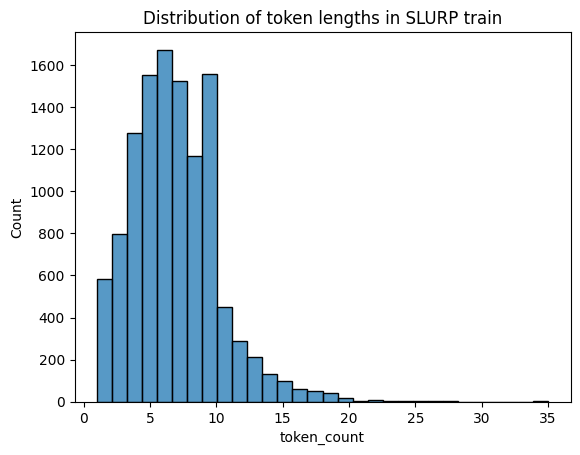

In [21]:
# Sentence length distribution
df["token_count"] = df["sentence"].str.split().map(len)
sns.histplot(df["token_count"], bins=30)
plt.title("Distribution of token lengths in SLURP train")
plt.show()



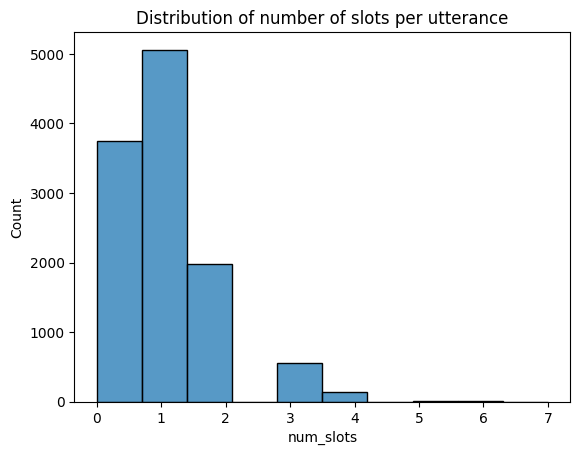

In [22]:
 # Slots per utterance
def count_slots(slot_string):
    if pd.isna(slot_string):
        return 0
    labels = slot_string.split()
    # count B- tags
    return sum(1 for lab in labels if lab.startswith("B-"))
df["num_slots"] = df["slot_string"].apply(count_slots)
sns.histplot(df["num_slots"], bins=10)
plt.title("Distribution of number of slots per utterance")
plt.show()


In [23]:
def plot_top_slot_labels(cnt, top_n=20):
    # Plot the top slot label counts (B/I)
    most = cnt.most_common(top_n)
    labels, freqs = zip(*most)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(freqs), y=list(labels), palette="viridis")  # horizontal bars
    plt.xlabel("Count")
    plt.ylabel("Slot Label (B-/I-)")
    plt.title(f"Top {top_n} Slot Labels (with BIO prefixes)")
    plt.tight_layout()
    plt.show()

def plot_slot_types(cnt2, top_n=20):
    most = cnt2.most_common(top_n)
    types_, freqs = zip(*most)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(freqs), y=list(types_), palette="coolwarm")
    plt.xlabel("Count")
    plt.ylabel("Slot Type")
    plt.title(f"Top {top_n} Slot Types (BIO merged)")
    plt.tight_layout()
    plt.show()

def plot_slot_type_pie(cnt2, top_n=10):
    # Pie chart of top slot types, remainder grouped into “Other”
    most = cnt2.most_common(top_n)
    types_, freqs = zip(*most)
    total = sum(cnt2.values())
    other = total - sum(freqs)
    
    labels = list(types_) + ["Other"]
    sizes = list(freqs) + [other]
    
    plt.figure(figsize=(8, 8))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
    plt.title("Slot Type Proportions (top + Other)")
    plt.axis('equal')  # equal aspect ensures pie is circular
    plt.show()



In [24]:

# Slot type frequencies
all_slot_labels = []
for ss in df["slot_string"].dropna():
    for lab in ss.split():
        if lab != "O":
            all_slot_labels.append(lab)
cnt = Counter(all_slot_labels)
print("Top slot labels:", cnt.most_common(20))
# e.g. distinct slot types by removing the B-/I- prefix
slot_types = [lab.split("-", 1)[1] for lab in all_slot_labels if "-" in lab]
cnt2 = Counter(slot_types)
print("Slot types frequency:", cnt2.most_common())


Top slot labels: [('B-date', 1823), ('B-place_name', 1088), ('B-event_name', 1000), ('I-time', 943), ('I-date', 906), ('B-person', 866), ('B-time', 799), ('I-event_name', 551), ('I-place_name', 527), ('B-media_type', 478), ('I-person', 413), ('B-business_name', 384), ('B-weather_descriptor', 320), ('B-transport_type', 318), ('B-food_type', 295), ('I-radio_name', 284), ('I-business_name', 252), ('B-relation', 251), ('B-timeofday', 239), ('B-artist_name', 232)]
Slot types frequency: [('date', 2729), ('time', 1742), ('place_name', 1615), ('event_name', 1551), ('person', 1279), ('business_name', 636), ('media_type', 575), ('food_type', 444), ('device_type', 424), ('radio_name', 416), ('weather_descriptor', 409), ('artist_name', 378), ('currency_name', 338), ('news_topic', 331), ('transport_type', 318), ('list_name', 306), ('relation', 304), ('definition_word', 304), ('song_name', 302), ('timeofday', 264), ('house_place', 258), ('business_type', 241), ('music_genre', 220), ('player_setting'

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9732\4065694706.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freqs), y=list(labels), palette="viridis")  # horizontal bars


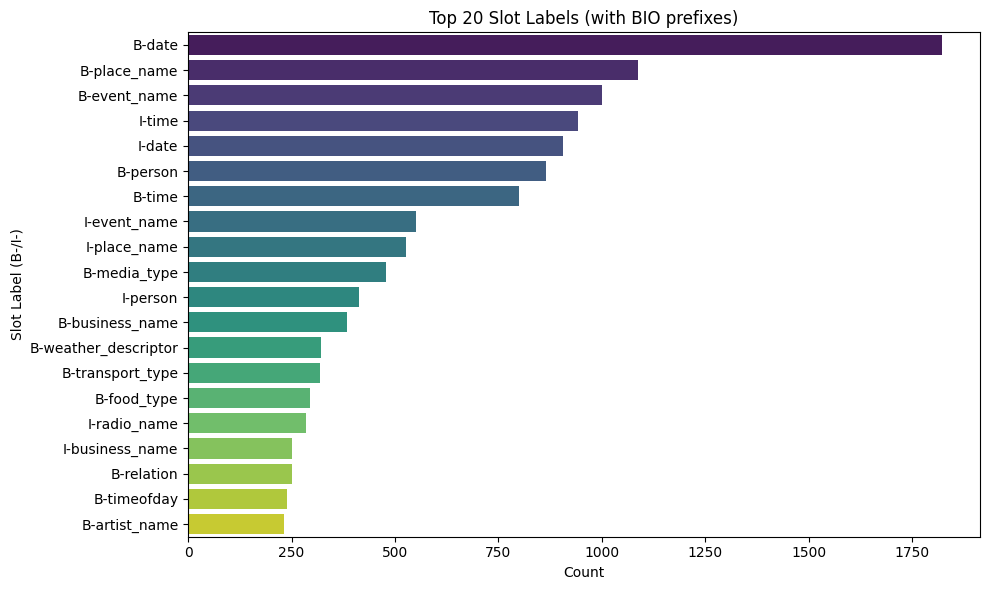

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9732\4065694706.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freqs), y=list(types_), palette="coolwarm")


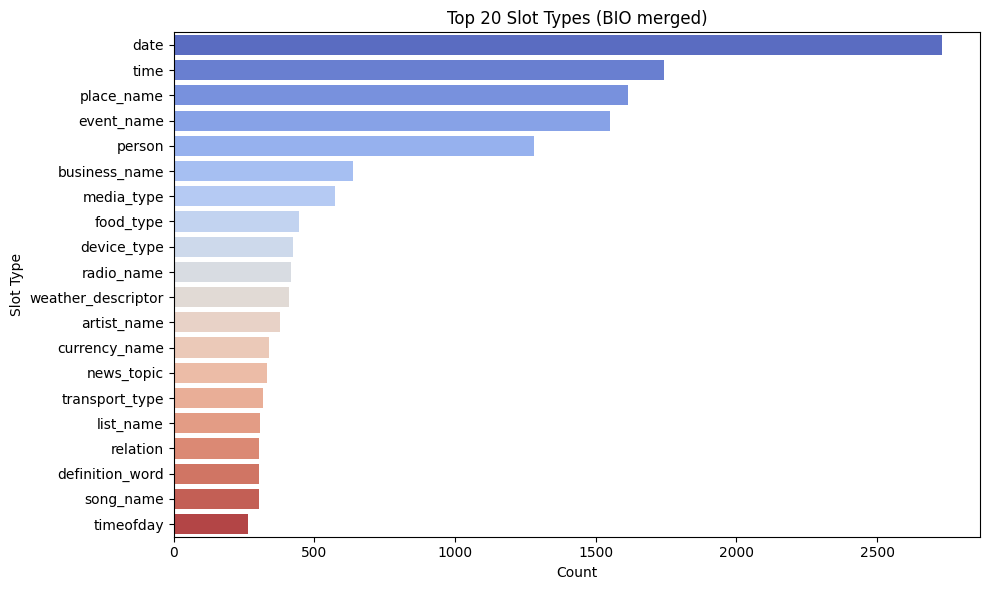

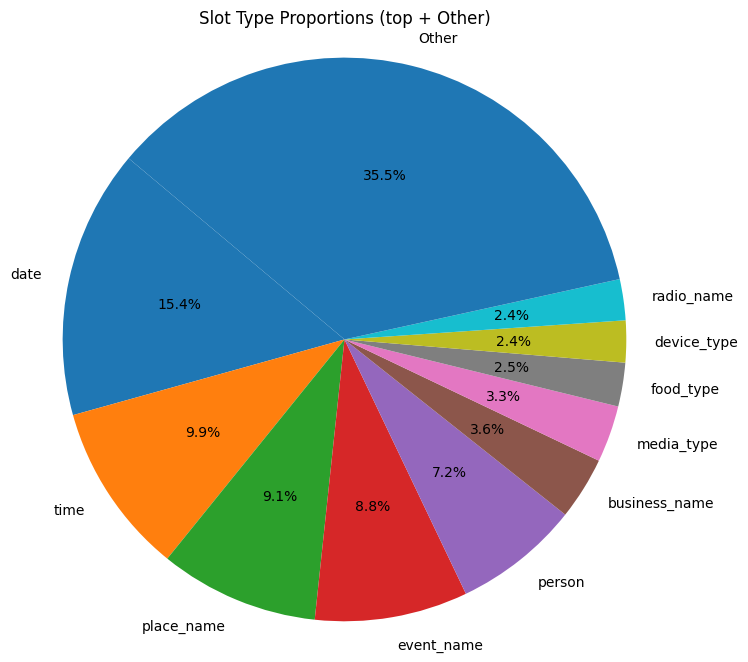

In [25]:
# Now call them
plot_top_slot_labels(cnt, top_n=20)
plot_slot_types(cnt2, top_n=20)
plot_slot_type_pie(cnt2, top_n=10)

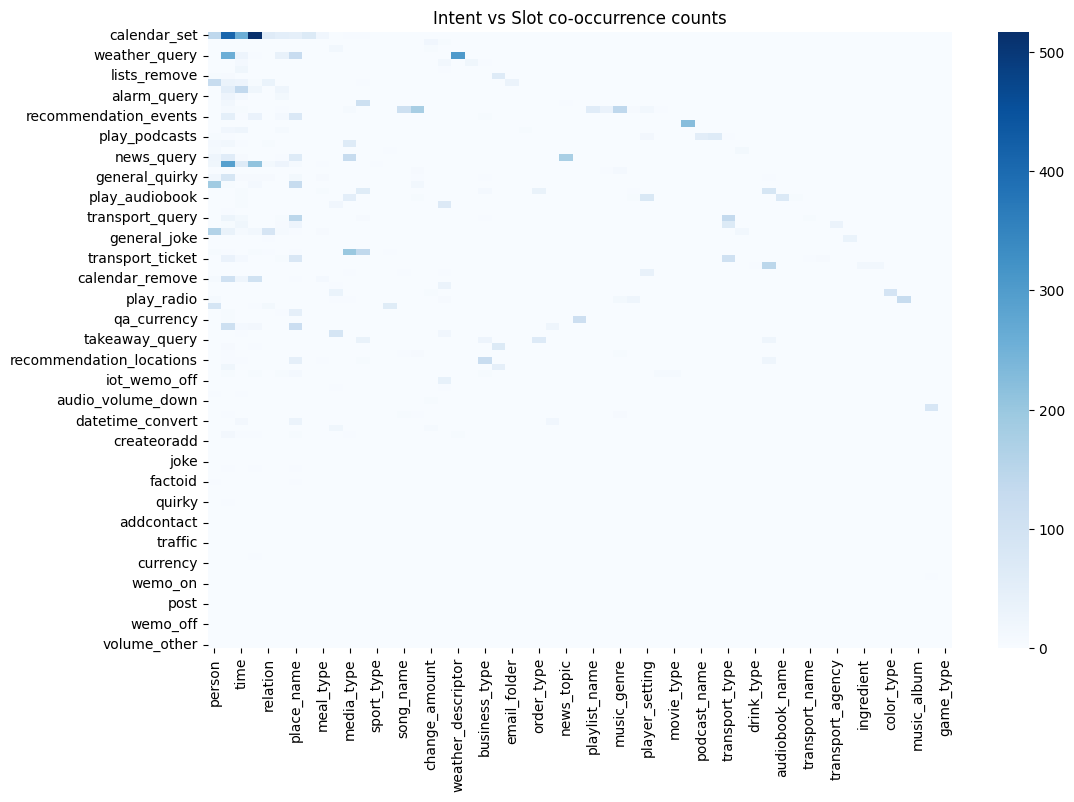

In [26]:

# Intent vs slot co-occurrence matrix
intent_slot = {}
for _, row in df.iterrows():
    intent = row["intent"]
    labels = row["slot_string"].split() if isinstance(row["slot_string"], str) else []
    types = set([lab.split("-",1)[1] for lab in labels if lab != "O" and "-" in lab])
    if intent not in intent_slot:
        intent_slot[intent] = Counter()
    intent_slot[intent].update(types)
# convert to DataFrame
mat = pd.DataFrame(intent_slot).fillna(0).T  # intents as rows, slot types as columns
plt.figure(figsize=(12,8))
sns.heatmap(mat, annot=False, cmap="Blues")
plt.title("Intent vs Slot co-occurrence counts")
plt.show()



In [27]:
# Compare train vs dev vs test
df_dev = pd.read_csv("Data/SLURP/slurp_dev.csv")
df_test = pd.read_csv("Data/SLURP/slurp_test.csv")

for split_df, name in [(df, "train"), (df_dev, "dev"), (df_test, "test")]:
    print(name, "avg tokens:", split_df["sentence"].str.split().map(len).mean(),
          "avg slots:", split_df["slot_string"].apply(count_slots).mean())

# Check how many utterances with no slots
for name, split_df in [("train", df), ("dev", df_dev), ("test", df_test)]:
    no_slot = (split_df["slot_string"].str.count("B-") == 0).sum()
    print(f"{name}: {no_slot} utterances with no slots, out of {len(split_df)}")


train avg tokens: 6.865641827340629 avg slots: 0.9872329338196978
dev avg tokens: 6.814067879980325 avg slots: 0.9945892769306444
test avg tokens: 6.771015467383995 avg slots: 0.949226630800269
train: 3755 utterances with no slots, out of 11514
dev: 646 utterances with no slots, out of 2033
test: 994 utterances with no slots, out of 2974


### ATIS

In [28]:
# Load the ATIS CSV
df = pd.read_csv("Data/ATIS/atis_train.csv")

# Basic stats
print("Num utterances:", len(df))
print("Intents (unique):", df["intent"].nunique())
print("Intents counts:\n", df["intent"].value_counts().head(10))

Num utterances: 4978
Intents (unique): 22
Intents counts:
 intent
flight            3666
airfare            423
ground_service     255
airline            157
abbreviation       147
aircraft            81
flight_time         54
quantity            51
flight+airfare      21
airport             20
Name: count, dtype: int64


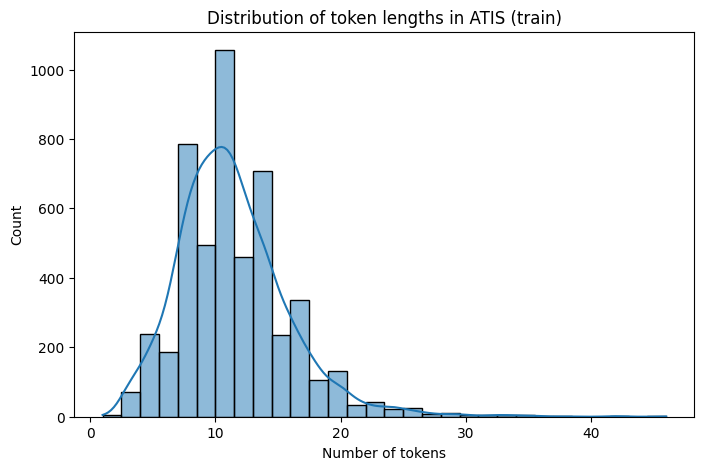

Min tokens: 1 Max tokens: 46 Mean tokens: 11.368220168742466


In [29]:
# Sentence length (token count)
df["token_count"] = df["text"].str.split().map(len)
plt.figure(figsize=(8,5))
sns.histplot(df["token_count"], bins=30, kde=True)
plt.title("Distribution of token lengths in ATIS (train)")
plt.xlabel("Number of tokens")
plt.ylabel("Count")
plt.show()

print("Min tokens:", df["token_count"].min(), 
      "Max tokens:", df["token_count"].max(), 
      "Mean tokens:", df["token_count"].mean())


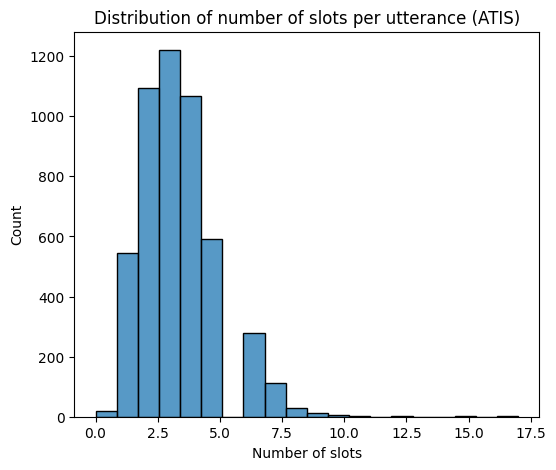

Utterances with no slots: 19 out of 4978


In [30]:
# Slot analysis
def count_slots(slot_string):
    if pd.isna(slot_string):
        return 0
    labs = slot_string.split()
    # Count B- prefixes as number of slots
    return sum(1 for l in labs if l.startswith("B-"))

df["num_slots"] = df["slots"].apply(count_slots)
plt.figure(figsize=(6,5))
sns.histplot(df["num_slots"], bins=20, kde=False)
plt.title("Distribution of number of slots per utterance (ATIS)")
plt.xlabel("Number of slots")
plt.ylabel("Count")
plt.show()

print("Utterances with no slots:", (df["num_slots"] == 0).sum(), "out of", len(df))

Top slot labels: [('B-toloc.city_name', 4343), ('B-fromloc.city_name', 4326), ('I-toloc.city_name', 1101), ('B-depart_date.day_name', 889), ('B-airline_name', 701), ('I-fromloc.city_name', 693), ('B-depart_time.period_of_day', 593), ('I-airline_name', 426), ('B-depart_date.day_number', 395), ('B-depart_date.month_name', 379), ('B-depart_time.time', 369), ('B-round_trip', 348), ('B-cost_relative', 344), ('I-round_trip', 339), ('B-flight_mod', 329), ('B-depart_time.time_relative', 323), ('I-depart_time.time', 299), ('B-stoploc.city_name', 239), ('B-city_name', 227), ('B-class_type', 217)]
Slot types freq: [('toloc.city_name', 5444), ('fromloc.city_name', 5019), ('airline_name', 1127), ('depart_date.day_name', 893), ('round_trip', 687), ('depart_time.time', 668), ('depart_time.period_of_day', 599), ('depart_date.day_number', 515), ('class_type', 400), ('cost_relative', 399), ('depart_date.month_name', 379), ('arrive_time.time', 369), ('flight_mod', 340), ('depart_time.time_relative', 325)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_9732\1127700282.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(freqs), y=list(types_), palette="Spectral")


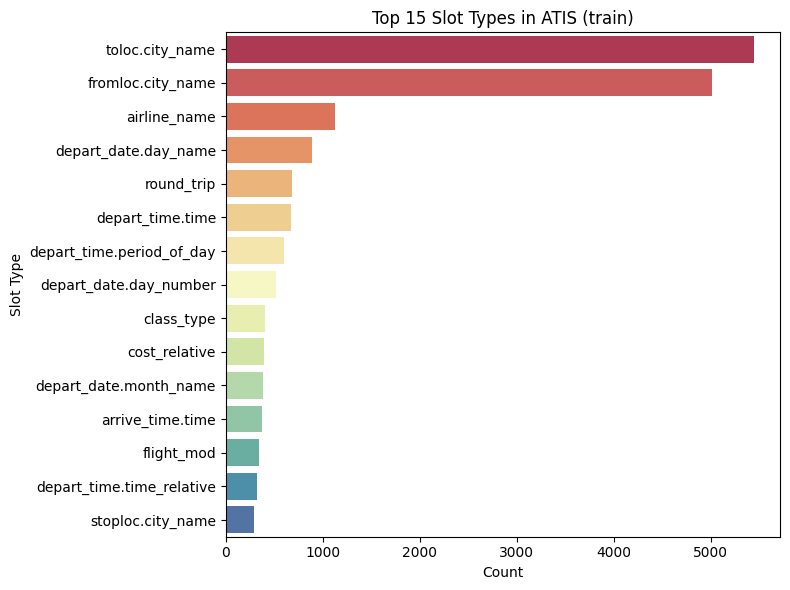

In [31]:
# Slot label frequencies (B-, I-)
all_slot_labels = []
for ss in df["slots"].dropna():
    for lab in ss.split():
        if lab != "O":
            all_slot_labels.append(lab)
cnt = Counter(all_slot_labels)
print("Top slot labels:", cnt.most_common(20))

# Slot types (merge B/I)
slot_types = [lab.split("-",1)[1] for lab in all_slot_labels if "-" in lab]
cnt2 = Counter(slot_types)
print("Slot types freq:", cnt2.most_common(20))

# Visualize slot types
def plot_slot_types(cnt2, top_n=15):
    most = cnt2.most_common(top_n)
    types_, freqs = zip(*most)
    plt.figure(figsize=(8,6))
    sns.barplot(x=list(freqs), y=list(types_), palette="Spectral")
    plt.xlabel("Count")
    plt.ylabel("Slot Type")
    plt.title(f"Top {top_n} Slot Types in ATIS (train)")
    plt.tight_layout()
    plt.show()

plot_slot_types(cnt2, top_n=15)


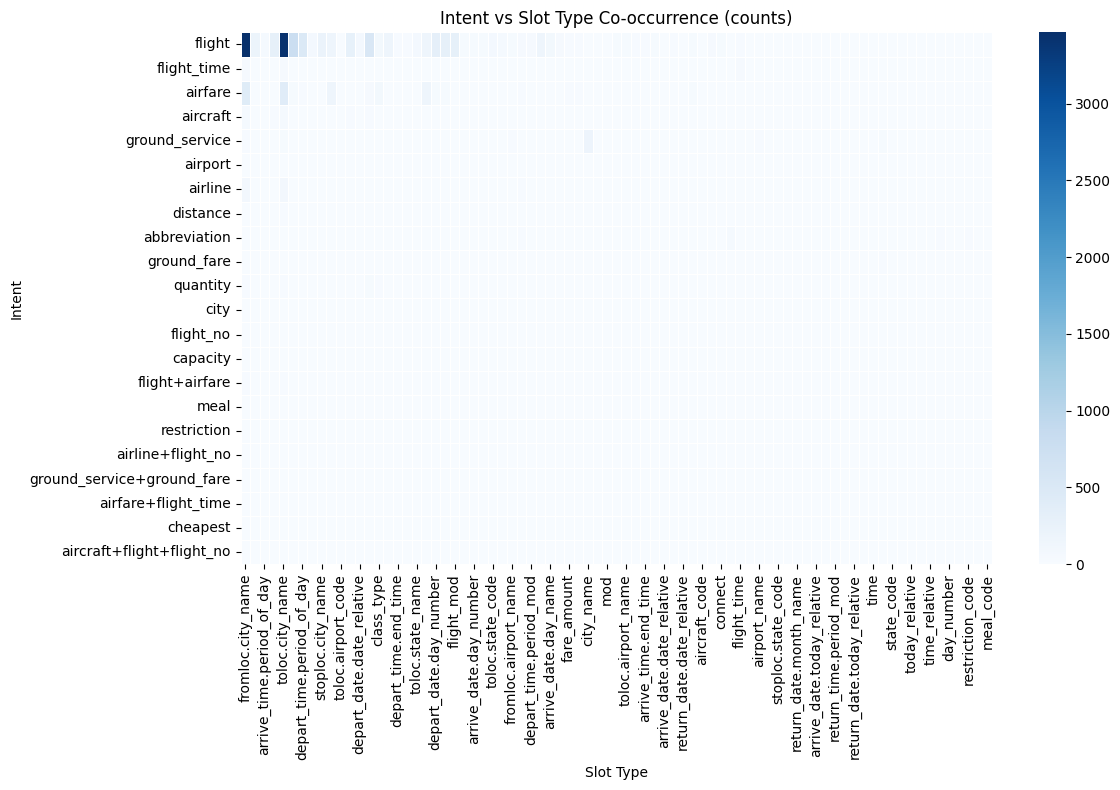

In [32]:
# Intent vs slot co-occurrence heatmap
intent_slot = {}
for _, row in df.iterrows():
    intent = row["intent"]
    labs = row["slots"].split()
    typeset = set([lab.split("-",1)[1] for lab in labs if lab != "O" and "-" in lab])
    if intent not in intent_slot:
        intent_slot[intent] = Counter()
    intent_slot[intent].update(typeset)

# Convert to DataFrame
mat = pd.DataFrame(intent_slot).fillna(0).T  # intents as rows
plt.figure(figsize=(12,8))
sns.heatmap(mat, cmap="Blues", linewidths=0.5)
plt.title("Intent vs Slot Type Co-occurrence (counts)")
plt.xlabel("Slot Type")
plt.ylabel("Intent")
plt.tight_layout()
plt.show()

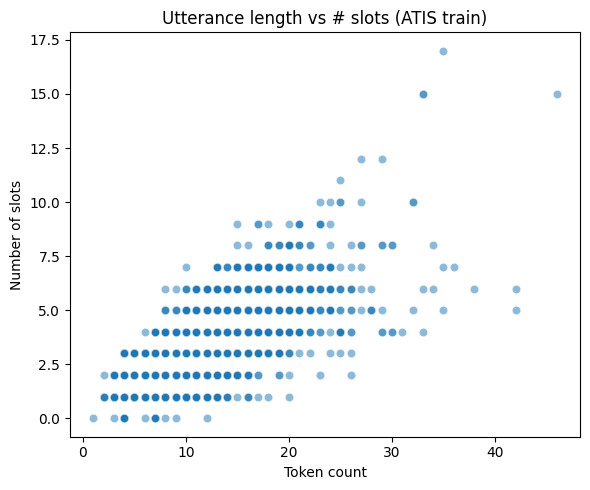

Intents with <= 5 examples:
intent
airline+flight_no             2
ground_service+ground_fare    1
airfare+flight_time           1
cheapest                      1
aircraft+flight+flight_no     1
Name: count, dtype: int64
Slot types with <= 5 occurrences:
{'return_date.month_name': 4, 'return_date.day_number': 5, 'time': 3, 'arrive_time.period_mod': 4, 'toloc.country_name': 3, 'days_code': 3, 'day_name': 5, 'period_of_day': 5, 'today_relative': 5, 'stoploc.state_code': 5, 'state_name': 2, 'stoploc.airport_name': 1, 'arrive_date.today_relative': 2, 'time_relative': 1, 'return_time.period_of_day': 3, 'return_time.period_mod': 2, 'month_name': 2, 'day_number': 2, 'return_date.today_relative': 3, 'return_date.day_name': 1}


In [33]:


# Compare length vs slots: scatter plot
plt.figure(figsize=(6,5))
sns.scatterplot(x="token_count", y="num_slots", data=df, alpha=0.5)
plt.title("Utterance length vs # slots (ATIS train)")
plt.xlabel("Token count")
plt.ylabel("Number of slots")
plt.tight_layout()
plt.show()

# Rare intents / slots
print("Intents with <= 5 examples:")
print(df["intent"].value_counts()[df["intent"].value_counts() <= 5])
print("Slot types with <= 5 occurrences:")
print({k:v for k,v in cnt2.items() if v <= 5})


## Preprocessing

## ATIS

In [34]:
train_csv = "Data/ATIS/atis_train.csv"
test_csv  = "Data/ATIS/atis_test.csv"

atis_train = pd.read_csv(train_csv)
atis_test  = pd.read_csv(test_csv)

atis_train.head(2)

,id,intent,text,slots
0,0,flight,i want to fly from boston at 838 am and arrive...,O O O O O B-fromloc.city_name O B-depart_time....
1,1,flight,what flights are available from pittsburgh to ...,O O O O O B-fromloc.city_name O B-toloc.city_n...


## Tokenising

In [35]:
def nltk_tok(s: str):
    return word_tokenize(s.lower())

def atis_to_samples_nltk(df):
    samples, fixed = [], 0
    for _, row in df.iterrows():
        toks = nltk_tok(row["text"])
        slots = row["slots"].split()

        if len(slots) != len(toks):
            # still handle edge cases
            if len(slots) < len(toks):
                slots = slots + ["O"] * (len(toks) - len(slots))
            else:
                slots = slots[:len(toks)]
            fixed += 1

        samples.append({"tokens": toks, "slots": slots, "intent": row["intent"]})

    if fixed:
        print(f"[ATIS] Repaired {fixed} text/slot mismatches.")
    return samples



In [36]:
atis_train_samples = atis_to_samples_nltk(atis_train)
atis_test_samples  = atis_to_samples_nltk(atis_test)

print(atis_train_samples[0])


{'tokens': ['i', 'want', 'to', 'fly', 'from', 'boston', 'at', '838', 'am', 'and', 'arrive', 'in', 'denver', 'at', '1110', 'in', 'the', 'morning'], 'slots': ['O', 'O', 'O', 'O', 'O', 'B-fromloc.city_name', 'O', 'B-depart_time.time', 'I-depart_time.time', 'O', 'O', 'O', 'B-toloc.city_name', 'O', 'B-arrive_time.time', 'O', 'O', 'B-arrive_time.period_of_day'], 'intent': 'flight'}


## Label Space

In [64]:
def build_label_map(labels, pad_label=None):
    uniq = sorted(set(labels))
    if pad_label is not None and pad_label not in uniq:
        uniq = [pad_label] + uniq
    return {lab: i for i, lab in enumerate(uniq)}

# slot labels (BIO)
all_slot_labels = [lab for s in atis_train_samples for lab in s["slots"]]
slot2id = build_label_map(all_slot_labels, pad_label="O")

# intent labels
intent2id = build_label_map([s["intent"] for s in atis_train_samples])
UNK_INTENT = "<unk_intent>"
intent2id[UNK_INTENT] = len(intent2id) 

len(slot2id), len(intent2id)


(123, 23)

In [65]:

for dataset_name in ["atis", "slurp"]:
    print(f"\n{'='*80}")
    print(f"Processing Dataset: {dataset_name.upper()}")
    print(f"{'='*80}\n")
    
    # Set global DATASET variable
    DATASET = dataset_name
    
    # Load processed artifacts for this dataset
    ART_DIR = f"artifacts/proc/{DATASET}"
    PICKLE = os.path.join(ART_DIR, f"{DATASET}_proc.pkl")
    
    with open(PICKLE, "rb") as f:
        data = pickle.load(f)
    
    train_data = data["train"]
    test_data  = data["test"]
    word2id    = data["word2id"]
    slot2id    = data["slot2id"]
    intent2id  = data["intent2id"]
    id2intent = {v: k for k, v in intent2id.items()}
    id2slot   = {v: k for k, v in slot2id.items()}
    id2word   = {v: k for k, v in word2id.items()}
    loader1 = {dataset_name:[id2intent, id2slot, id2word]}

    PAD_IDX      = word2id["<pad>"]
    UNK_IDX      = word2id["<unk>"]
    SLOT_PAD_IDX = slot2id["O"]
    UNK_INTENT   = "<unk_intent>" if "<unk_intent>" in intent2id else None
    



Processing Dataset: ATIS


Processing Dataset: SLURP



## Building Vocab

In [38]:
from collections import Counter
SPECIAL = {"<pad>": 0, "<unk>": 1}

def build_vocab(list_of_token_lists, min_freq=1):
    cnt = Counter()
    for toks in list_of_token_lists:
        cnt.update(toks)
    word2id = dict(SPECIAL)
    for w, c in cnt.most_common():
        if c >= min_freq and w not in word2id:
            word2id[w] = len(word2id)
    return word2id

word2id = build_vocab([s["tokens"] for s in atis_train_samples], min_freq=1)

## numercalizing samples

In [39]:
# Add unknown intent handling
UNK_INTENT = "<unk_intent>"
if UNK_INTENT not in intent2id:
    intent2id[UNK_INTENT] = len(intent2id)

In [40]:
def numericalize_sample(sample, word2id, slot2id, intent2id, unk_intent="<unk_intent>"):
    x = [word2id.get(t, word2id["<unk>"]) for t in sample["tokens"]]
    y = [slot2id.get(s, slot2id["O"]) for s in sample["slots"]]
    z = intent2id.get(sample["intent"], intent2id[unk_intent])  # fallback to unk_intent
    return {"tokens": x, "slots": y, "intent": z, "len": len(x)}

atis_train_num = [numericalize_sample(s, word2id, slot2id, intent2id) for s in atis_train_samples]
atis_test_num  = [numericalize_sample(s, word2id, slot2id, intent2id)  for s in atis_test_samples]

print("Train samples:", len(atis_train_num), " | Test samples:", len(atis_test_num))
print("One test sample intent:", atis_test_samples[0]["intent"], 
      "-> mapped to", atis_test_num[0]["intent"])

Train samples: 4978  | Test samples: 893
One test sample intent: flight -> mapped to 12


## Saving preprocessed data

In [42]:

os.makedirs("artifacts/proc/atis", exist_ok=True)

pickle.dump(
    {"train": atis_train_num, "test": atis_test_num,
     "word2id": word2id, "slot2id": slot2id, "intent2id": intent2id},
    open("artifacts/proc/atis/atis_proc.pkl", "wb")
)
print("Saved to artifacts/proc/atis/atis_proc.pkl")

Saved to artifacts/proc/atis/atis_proc.pkl


## SLURP

In [43]:
import pandas as pd
import ast  # for safely reading stringified lists/dicts

slurp_train = pd.read_csv("Data/SLURP/slurp_train.csv")
slurp_test  = pd.read_csv("Data/SLURP/slurp_test.csv")

print(slurp_train.head(2))


   slurp_id                                           sentence        intent  \
0      9024                                              event  calendar_set   
1      7874  i need an event three days from now scheduled ...  calendar_set   

                                            entities  \
0                                                 []   
1  [{"span": [4, 5, 6, 7], "type": "date"}, {"spa...   

                                        slot_string  
0                                                 O  
1  O O O O B-date I-date I-date I-date O O B-person  


### Tokenising

In [44]:
def slurp_to_samples(df):
    samples, fixed = [], 0
    for _, row in df.iterrows():
        toks = row["sentence"].lower().strip().split()
        slots = row["slot_string"].split()

        if len(slots) != len(toks):
            # minimal fix if mismatch
            if len(slots) < len(toks):
                slots = slots + ["O"] * (len(toks) - len(slots))
            else:
                slots = slots[:len(toks)]
            fixed += 1

        samples.append({
            "tokens": toks,
            "slots": slots,
            "intent": row["intent"]
        })

    if fixed:
        print(f"[SLURP] Fixed {fixed} text/slot mismatches.")
    return samples

slurp_train_samples = slurp_to_samples(slurp_train)
slurp_test_samples  = slurp_to_samples(slurp_test)

print("Train example:", slurp_train_samples[0])


[SLURP] Fixed 953 text/slot mismatches.
[SLURP] Fixed 249 text/slot mismatches.
Train example: {'tokens': ['event'], 'slots': ['O'], 'intent': 'calendar_set'}


### Buiding Label Maps

In [45]:
def build_label_map(labels, pad_label=None):
    uniq = sorted(set(labels))
    if pad_label is not None and pad_label not in uniq:
        uniq = [pad_label] + uniq
    return {lab: i for i, lab in enumerate(uniq)}

# slot labels
all_slot_labels = [lab for s in slurp_train_samples for lab in s["slots"]]
slurp_slot2id = build_label_map(all_slot_labels, pad_label="O")

# intent labels (train only + unk intent)
slurp_intent2id = build_label_map([s["intent"] for s in slurp_train_samples])
UNK_INTENT = "<unk_intent>"
slurp_intent2id[UNK_INTENT] = len(slurp_intent2id)

print("Num slot labels:", len(slurp_slot2id), "Num intents:", len(slurp_intent2id))


Num slot labels: 107 Num intents: 92


## Building Vocab

In [46]:
from collections import Counter
SPECIAL = {"<pad>": 0, "<unk>": 1}

def build_vocab(list_of_token_lists, min_freq=1):
    cnt = Counter()
    for toks in list_of_token_lists:
        cnt.update(toks)
    word2id = dict(SPECIAL)
    for w, c in cnt.most_common():
        if c >= min_freq and w not in word2id:
            word2id[w] = len(word2id)
    return word2id

slurp_word2id = build_vocab([s["tokens"] for s in slurp_train_samples], min_freq=1)
print("SLURP vocab size:", len(slurp_word2id))


SLURP vocab size: 5399


### Numercalising

In [47]:
def numericalize_sample(sample, word2id, slot2id, intent2id, unk_intent="<unk_intent>"):
    x = [word2id.get(t, word2id["<unk>"]) for t in sample["tokens"]]
    y = [slot2id.get(s, slot2id["O"]) for s in sample["slots"]]
    z = intent2id.get(sample["intent"], intent2id[unk_intent])
    return {"tokens": x, "slots": y, "intent": z, "len": len(x)}

slurp_train_num = [numericalize_sample(s, slurp_word2id, slurp_slot2id, slurp_intent2id) for s in slurp_train_samples]
slurp_test_num  = [numericalize_sample(s, slurp_word2id, slurp_slot2id, slurp_intent2id)  for s in slurp_test_samples]

print("Train samples:", len(slurp_train_num), " | Test samples:", len(slurp_test_num))
print("One numeric sample:", {k:(v[:6] if isinstance(v, list) else v) for k,v in slurp_train_num[0].items()})


Train samples: 11514  | Test samples: 2974
One numeric sample: {'tokens': [46], 'slots': [106], 'intent': 10, 'len': 1}


## Saving preprocessed data

In [48]:
import os, pickle

# make dir
os.makedirs("artifacts/proc/slurp", exist_ok=True)

# save processed data + vocab/label maps
pickle.dump(
    {
        "train": slurp_train_num,
        "test": slurp_test_num,
        "word2id": slurp_word2id,
        "slot2id": slurp_slot2id,
        "intent2id": slurp_intent2id
    },
    open("artifacts/proc/slurp/slurp_proc.pkl", "wb")
)

print("Saved to artifacts/proc/slurp/slurp_proc.pkl")


Saved to artifacts/proc/slurp/slurp_proc.pkl


## Model Building

## RNN Cell

In [49]:


class RNNCell(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.Wx = nn.Linear(input_dim, hidden_dim)
        self.Wh = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.hidden_dim = hidden_dim

    def forward(self, x, h_prev):
        # x: [batch, input_dim], h_prev: [batch, hidden_dim]
        h = torch.tanh(self.Wx(x) + self.Wh(h_prev))
        return h


## LSTM Cell

In [50]:
class LSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super().__init__()
        self.Wx = nn.Linear(input_dim, 4*hidden_dim)
        self.Wh = nn.Linear(hidden_dim, 4*hidden_dim, bias=False)
        self.hidden_dim = hidden_dim

    def forward(self, x, h_prev, c_prev):
        gates = self.Wx(x) + self.Wh(h_prev)
        i, f, o, g = gates.chunk(4, dim=1)

        i = torch.sigmoid(i)   # input gate
        f = torch.sigmoid(f)   # forget gate
        o = torch.sigmoid(o)   # output gate
        g = torch.tanh(g)      # candidate

        c = f * c_prev + i * g
        h = o * torch.tanh(c)
        return h, c


## Custom Encoder

In [51]:
class CustomEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, cell_type="rnn", pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.hidden_dim = hidden_dim
        self.cell_type = cell_type
        if cell_type == "rnn":
            self.cell = RNNCell(embed_dim, hidden_dim)
        elif cell_type == "lstm":
            self.cell = LSTMCell(embed_dim, hidden_dim)
        else:
            raise ValueError("cell_type must be 'rnn' or 'lstm'")

    def forward(self, x, lengths):
        emb = self.embedding(x) 
        B, T, D = emb.size()
        device = x.device
        h = torch.zeros(B, self.hidden_dim, device=device)
        c = torch.zeros(B, self.hidden_dim, device=device) if self.cell_type == "lstm" else None

        outputs = []
        for t in range(T):
            xt = emb[:, t, :]
            if self.cell_type == "rnn":
                h = self.cell(xt, h)
                outputs.append(h.unsqueeze(1))
            else:
                h, c = self.cell(xt, h, c)
                outputs.append(h.unsqueeze(1))
        outputs = torch.cat(outputs, dim=1)  # [B,T,H]
        return outputs, h  # full sequence, last hidden

## Independent Heads

In [52]:
class IntentClassifier(nn.Module):
    def __init__(self, encoder, hidden_dim, num_classes):
        super().__init__()
        self.encoder = encoder
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, lengths):
        _, h = self.encoder(x, lengths)
        return self.fc(h)  # [B, num_classes]

class SlotTagger(nn.Module):
    def __init__(self, encoder, hidden_dim, num_slots):
        super().__init__()
        self.encoder = encoder
        self.fc = nn.Linear(hidden_dim, num_slots)

    def forward(self, x, lengths):
        seq_out, _ = self.encoder(x, lengths)
        return self.fc(seq_out)  # [B, T, num_slots]


In [53]:
def set_seed(seed=42):
    random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed(42)

## PART 1

### Independent Slot Filling and Intent Recognition

## 1) Load processed artifacts

In [54]:
def stratified_split(full, val_ratio=0.1):
    by_intent = {}
    for ex in full:
        by_intent.setdefault(ex["intent"], []).append(ex)
    tr, va = [], []
    for _, arr in by_intent.items():
        k = max(1, int(len(arr)*val_ratio))
        va.extend(arr[:k]); tr.extend(arr[k:])
    return tr, va

## 2) Dataset / Collate

In [55]:
class NLUSeqDataset(Dataset):
    def __init__(self, arr):
        self.arr = arr
    def __len__(self): return len(self.arr)
    def __getitem__(self, i): return self.arr[i]

def create_pad_collate(PAD_IDX, SLOT_PAD_IDX):
    """Factory function to create pad_collate with specific padding indices"""
    def pad_collate(batch):
        # batch: list of dicts {tokens, slots, intent, len}
        max_len = max(b["len"] for b in batch)
        B = len(batch)
        tokens = torch.full((B, max_len), PAD_IDX, dtype=torch.long)
        slots  = torch.full((B, max_len), SLOT_PAD_IDX, dtype=torch.long)
        mask   = torch.zeros((B, max_len), dtype=torch.bool)
        intents = torch.tensor([b["intent"] for b in batch], dtype=torch.long)
        lengths = torch.tensor([b["len"] for b in batch], dtype=torch.long)
        for i, b in enumerate(batch):
            L = b["len"]
            tokens[i, :L] = torch.tensor(b["tokens"], dtype=torch.long)
            slots[i, :L]  = torch.tensor(b["slots"], dtype=torch.long)
            mask[i, :L]   = 1
        return {"tokens": tokens, "slots": slots, "intents": intents, "mask": mask, "lengths": lengths}
    return pad_collate



## 3) Metrics

In [66]:
outputs = []

In [67]:
@torch.no_grad()
def accuracy_intent(logits, gold):
    pred = logits.argmax(dim=1)
    outputs.append((pred, gold))
    return (pred == gold).float().mean().item()

@torch.no_grad()
def seq_prf1(logits, gold, mask, ignore_idx):
    # micro P/R/F1 at token-level
    pred = logits.argmax(dim=-1)
    valid = mask & (gold != ignore_idx)
    tp = ((pred == gold) & valid).sum().item()
    fp = ((pred != gold) & valid).sum().item()
    fn = fp  # because every wrong pred is a miss for the gold class in micro averaging
    P = tp / (tp + fp + 1e-9)
    R = tp / (tp + fn + 1e-9)
    F1 = 2*P*R / (P + R + 1e-9)
    return P, R, F1

In [68]:


def macro_prf1_from_counts(tp, fp, fn, n_classes):
    # per-class P/R/F1 then macro average
    precisions, recalls, f1s = [], [], []
    for c in range(n_classes):
        P = tp[c] / (tp[c] + fp[c] + 1e-9)
        R = tp[c] / (tp[c] + fn[c] + 1e-9)
        F1 = 2*P*R / (P+R+1e-9)
        precisions.append(P); recalls.append(R); f1s.append(F1)
    return sum(precisions)/n_classes, sum(recalls)/n_classes, sum(f1s)/n_classes

@torch.no_grad()
def intent_full_metrics(model, loader, device, n_classes):
    model.eval()
    ce = nn.CrossEntropyLoss()
    total_loss, total_correct, total = 0.0, 0, 0

    # per-class counts
    tp = [0]*n_classes; fp = [0]*n_classes; fn = [0]*n_classes

    for batch in loader:
        x = batch["tokens"].to(device)
        y = batch["intents"].to(device)
        lengths = batch["lengths"].to(device)

        logits = model(x, lengths)
        loss = ce(logits, y)
        total_loss += loss.item() * x.size(0)

        pred = logits.argmax(dim=1)
        total_correct += (pred == y).sum().item()
        total += x.size(0)

        # update per-class
        for c in range(n_classes):
            tp[c] += ((pred == c) & (y == c)).sum().item()
            fp[c] += ((pred == c) & (y != c)).sum().item()
            fn[c] += ((pred != c) & (y == c)).sum().item()

    acc = total_correct / max(1, total)
    P_macro, R_macro, F1_macro = macro_prf1_from_counts(tp, fp, fn, n_classes)
    return {
        "loss": total_loss / max(1, total),
        "accuracy": acc,
        "precision_macro": P_macro,
        "recall_macro": R_macro,
        "f1_macro": F1_macro,
    }

@torch.no_grad()
def slot_micro_prf1(model, loader, device, ignore_idx):
    model.eval()
    ce = nn.CrossEntropyLoss(ignore_index=ignore_idx)
    total_loss, n_batches = 0.0, 0
    TP = 0; FP = 0; FN = 0

    for batch in loader:
        x = batch["tokens"].to(device)
        y = batch["slots"].to(device)
        mask = batch["mask"].to(device)
        lengths = batch["lengths"].to(device)

        logits = model(x, lengths)           # [B,T,C]
        loss = ce(logits.view(-1, logits.size(-1)), y.view(-1))
        total_loss += loss.item(); n_batches += 1

        pred = logits.argmax(dim=-1)         # [B,T]
        valid = mask & (y != ignore_idx)
        tp = ((pred == y) & valid).sum().item()
        fp = ((pred != y) & valid).sum().item()
        fn = fp  # micro: each mistake counts as both a miss for true and a false for predicted

        TP += tp; FP += fp; FN += fn

    P = TP / (TP + FP + 1e-9)
    R = TP / (TP + FN + 1e-9)
    F1 = 2*P*R / (P + R + 1e-9)
    return {
        "loss": total_loss / max(1, n_batches),
        "precision_micro": P,
        "recall_micro": R,
        "f1_micro": F1,
    }


In [ ]:
@torch.no_grad()
def save_intent_predictions(model, loader, device, id2intent, id2word, output_path):
    """
    Save intent predictions to CSV file with columns: sentence, actual, predicted
    """
    model.eval()
    results = []
    
    for batch in loader:
        x = batch["tokens"].to(device)
        y = batch["intents"].to(device)
        lengths = batch["lengths"].to(device)
        
        logits = model(x, lengths)
        pred = logits.argmax(dim=1)
        
        # Convert to sentences
        for i in range(x.size(0)):
            token_ids = x[i, :lengths[i]].cpu().numpy()
            sentence = " ".join([id2word.get(tid, "<unk>") for tid in token_ids])
            actual_intent = id2intent[y[i].item()]
            predicted_intent = id2intent[pred[i].item()]
            
            results.append({
                "sentence": sentence,
                "actual": actual_intent,
                "predicted": predicted_intent
            })
    
    df = pd.DataFrame(results)
    df.to_csv(output_path, index=False)
    print(f"Saved intent predictions → {output_path}")
    return df


@torch.no_grad()
def save_slot_predictions(model, loader, device, id2slot, id2word, output_path, slot_pad_idx):
    """
    Save slot predictions to CSV file with columns: sentence, actual, predicted
    """
    model.eval()
    results = []
    
    for batch in loader:
        x = batch["tokens"].to(device)
        y = batch["slots"].to(device)
        mask = batch["mask"].to(device)
        lengths = batch["lengths"].to(device)
        
        logits = model(x, lengths)
        pred = logits.argmax(dim=-1)
        
        # Convert to sentences with slot tags
        for i in range(x.size(0)):
            L = lengths[i].item()
            token_ids = x[i, :L].cpu().numpy()
            actual_slots = y[i, :L].cpu().numpy()
            predicted_slots = pred[i, :L].cpu().numpy()
            
            sentence = " ".join([id2word.get(tid, "<unk>") for tid in token_ids])
            
            # Format slot tags as "word/tag word/tag ..."
            actual_tags = [id2slot[sid] for sid in actual_slots if sid != slot_pad_idx]
            predicted_tags = [id2slot[sid] for sid in predicted_slots if sid != slot_pad_idx]
            
            actual_str = " ".join(actual_tags)
            predicted_str = " ".join(predicted_tags)
            
            results.append({
                "sentence": sentence,
                "actual": actual_str,
                "predicted": predicted_str
            })
    
    df = pd.DataFrame(results)
    df.to_csv(output_path, index=False)
    print(f"Saved slot predictions → {output_path}")
    return df

## Independent Slot Filling and Intent Recognition

## 4) Train/Eval loops

In [69]:
def train_intent(model, loader, optimizer, device):
    model.train()
    ce = nn.CrossEntropyLoss()
    total_loss, total_acc, n = 0.0, 0.0, 0
    for batch in loader:
        x = batch["tokens"].to(device)
        y = batch["intents"].to(device)
        lengths = batch["lengths"].to(device)
        optimizer.zero_grad()
        logits = model(x, lengths)
        loss = ce(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        total_acc  += accuracy_intent(logits.detach(), y) * x.size(0)
        n += x.size(0)
    return total_loss/n, total_acc/n

@torch.no_grad()
def eval_intent(model, loader, device):
    model.eval()
    ce = nn.CrossEntropyLoss()
    total_loss, total_acc, n = 0.0, 0.0, 0
    for batch in loader:
        x = batch["tokens"].to(device)
        y = batch["intents"].to(device)
        lengths = batch["lengths"].to(device)
        logits = model(x, lengths)
        loss = ce(logits, y)
        total_loss += loss.item() * x.size(0)
        total_acc  += accuracy_intent(logits, y) * x.size(0)
        n += x.size(0)
    return total_loss/n, total_acc/n

def train_slots(model, loader, optimizer, device, slot_pad_idx):
    model.train()
    ce = nn.CrossEntropyLoss(ignore_index=slot_pad_idx)
    total_loss, total_f1, n_tok = 0.0, 0.0, 0
    for batch in loader:
        x = batch["tokens"].to(device)
        y = batch["slots"].to(device)
        mask = batch["mask"].to(device)
        lengths = batch["lengths"].to(device)
        optimizer.zero_grad()
        logits = model(x, lengths)  # [B,T,C]
        loss = ce(logits.view(-1, logits.size(-1)), y.view(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        P,R,F1 = seq_prf1(logits.detach(), y, mask, slot_pad_idx)
        total_loss += loss.item() * x.size(0)
        total_f1  += F1 * x.size(0)
        n_tok += x.size(0)
    return total_loss/n_tok, total_f1/n_tok

@torch.no_grad()
def eval_slots(model, loader, device, slot_pad_idx):
    model.eval()
    ce = nn.CrossEntropyLoss(ignore_index=slot_pad_idx)
    total_loss, total_P, total_R, total_F1, n_batches = 0.0, 0.0, 0.0, 0.0, 0
    for batch in loader:
        x = batch["tokens"].to(device)
        y = batch["slots"].to(device)
        mask = batch["mask"].to(device)
        lengths = batch["lengths"].to(device)
        logits = model(x, lengths)
        loss = ce(logits.view(-1, logits.size(-1)), y.view(-1))
        P,R,F1 = seq_prf1(logits, y, mask, slot_pad_idx)
        total_loss += loss.item()
        total_P    += P
        total_R    += R
        total_F1   += F1
        n_batches  += 1
    return total_loss/n_batches, total_P/n_batches, total_R/n_batches, total_F1/n_batches


## Independent Slot Filling and Intent Recognition

## Train BOTH models with RNN and LSTM

In [70]:
# Run experiments for both ATIS and SLURP datasets
all_results = []

for dataset_name in ["atis", "slurp"]:
    print(f"\n{'='*80}")
    print(f"Processing Dataset: {dataset_name.upper()}")
    print(f"{'='*80}\n")
    
    # Set global DATASET variable
    DATASET = dataset_name
    
    # Load processed artifacts for this dataset
    ART_DIR = f"artifacts/proc/{DATASET}"
    PICKLE = os.path.join(ART_DIR, f"{DATASET}_proc.pkl")
    
    with open(PICKLE, "rb") as f:
        data = pickle.load(f)
    
    train_data = data["train"]
    test_data  = data["test"]
    word2id    = data["word2id"]
    slot2id    = data["slot2id"]
    intent2id  = data["intent2id"]
   
    PAD_IDX      = word2id["<pad>"]
    UNK_IDX      = word2id["<unk>"]
    SLOT_PAD_IDX = slot2id["O"]
    UNK_INTENT   = "<unk_intent>" if "<unk_intent>" in intent2id else None
    
    # Split train into train/val
    train_data, val_data = stratified_split(train_data, val_ratio=0.1)
    
    # Create pad_collate function with dataset-specific padding indices
    pad_collate = create_pad_collate(PAD_IDX, SLOT_PAD_IDX)
    
    # Create data loaders
    train_loader = DataLoader(NLUSeqDataset(train_data), batch_size=64, shuffle=True,  collate_fn=pad_collate)
    val_loader   = DataLoader(NLUSeqDataset(val_data),   batch_size=128, shuffle=False, collate_fn=pad_collate)
    test_loader  = DataLoader(NLUSeqDataset(test_data),  batch_size=128, shuffle=False, collate_fn=pad_collate)
    
    print(f"Loaded {DATASET.upper()}: train={len(train_data)} val={len(val_data)} test={len(test_data)}")


Processing Dataset: ATIS

Loaded ATIS: train=4481 val=497 test=893

Processing Dataset: SLURP

Loaded SLURP: train=10368 val=1146 test=2974


In [ ]:
def run_experiment(cell_type="rnn", embed_dim=128, hidden_dim=128, epochs=8, lr=3e-3, weight_decay=1e-5, device=None):
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    V = len(word2id); C_intent = len(intent2id); C_slot = len(slot2id)

    out_dir = f"Results/Independent Slot Filling and Intent Recognition/{DATASET}/{cell_type.upper()}"
    os.makedirs(out_dir, exist_ok=True)
    
    # Create model directory
    model_dir = f"artifacts/models/1.Independent Slot Filling and Intent Recognition/{DATASET.upper()}/{cell_type.upper()}"
    os.makedirs(model_dir, exist_ok=True)

    intent_log, slot_log = [], []

    # ---------- Intent model ----------
    enc_int = CustomEncoder(V, embed_dim, hidden_dim, cell_type=cell_type, pad_idx=PAD_IDX)
    model_int = IntentClassifier(enc_int, hidden_dim, C_intent).to(device)
    opt_int = torch.optim.Adam(model_int.parameters(), lr=lr, weight_decay=weight_decay)

    best_va_acc = -1.0
    best_int_state = None

    print(f"\n=== {DATASET.upper()} | {cell_type.upper()} | intent ===")
    intent_train_start = time.time()
    for ep in range(1, epochs+1):
        tr_loss, tr_acc = train_intent(model_int, train_loader, opt_int, device)
        va_loss, va_acc = eval_intent(model_int, val_loader, device)
        te_loss, te_acc = eval_intent(model_int, test_loader, device)
        print(f"[ep {ep:02d}] train: loss={tr_loss:.4f} acc={tr_acc:.4f} | val: loss={va_loss:.4f} acc={va_acc:.4f} | test acc={te_acc:.4f}")

        intent_log.append({"epoch": ep, "train_loss": tr_loss, "train_acc": tr_acc,
                           "val_loss": va_loss, "val_acc": va_acc,
                           "test_loss": te_loss, "test_acc": te_acc})

        if va_acc > best_va_acc:
            best_va_acc = va_acc
            best_int_state = {k: v.cpu().state_dict() for k, v in model_int._modules.items()}
    intent_train_time = time.time() - intent_train_start

    # reload best val
    if best_int_state is not None:
        for name, module in model_int._modules.items():
            module.load_state_dict(best_int_state[name])
    
    # Save intent model
    torch.save(model_int.state_dict(), os.path.join(model_dir, "intent_model.pt"))
    print(f"Saved intent model → {os.path.join(model_dir, 'intent_model.pt')}")

    # Full test metrics (acc + macro P/R/F1)
    intent_test_start = time.time()
    intent_test = intent_full_metrics(model_int, test_loader, device, C_intent)
    intent_test_time = time.time() - intent_test_start
    
    # Save intent predictions to CSV
    id2intent = {v: k for k, v in intent2id.items()}
    id2word = {v: k for k, v in word2id.items()}
    intent_pred_path = os.path.join(out_dir, "intent_predictions.csv")
    save_intent_predictions(model_int, test_loader, device, id2intent, id2word, intent_pred_path)

    # ---------- Slot model ----------
    enc_slot = CustomEncoder(V, embed_dim, hidden_dim, cell_type=cell_type, pad_idx=PAD_IDX)
    model_slot = SlotTagger(enc_slot, hidden_dim, C_slot).to(device)
    opt_slot = torch.optim.Adam(model_slot.parameters(), lr=lr, weight_decay=weight_decay)

    best_va_f1 = -1.0
    best_slot_state = None

    print(f"\n=== {DATASET.upper()} | {cell_type.upper()} | slots ===")
    slot_train_start = time.time()
    for ep in range(1, epochs+1):
        tr_loss, tr_f1 = train_slots(model_slot, train_loader, opt_slot, device, SLOT_PAD_IDX)
        va_loss, va_P, va_R, va_F1 = eval_slots(model_slot, val_loader, device, SLOT_PAD_IDX)
        te_loss, te_P, te_R, te_F1 = eval_slots(model_slot, test_loader, device, SLOT_PAD_IDX)
        print(f"[ep {ep:02d}] train: loss={tr_loss:.4f} f1={tr_f1:.4f} | val: loss={va_loss:.4f} P={va_P:.4f} R={va_R:.4f} F1={va_F1:.4f} | test F1={te_F1:.4f}")

        slot_log.append({"epoch": ep, "train_loss": tr_loss, "train_f1": tr_f1,
                         "val_loss": va_loss, "val_P": va_P, "val_R": va_R, "val_F1": va_F1,
                         "test_loss": te_loss, "test_P": te_P, "test_R": te_R, "test_F1": te_F1})

        if va_F1 > best_va_f1:
            best_va_f1 = va_F1
            best_slot_state = {k: v.cpu().state_dict() for k, v in model_slot._modules.items()}
    slot_train_time = time.time() - slot_train_start

    # reload best val
    if best_slot_state is not None:
        for name, module in model_slot._modules.items():
            module.load_state_dict(best_slot_state[name])
    
    # Save slot model
    torch.save(model_slot.state_dict(), os.path.join(model_dir, "slot_model.pt"))
    print(f"Saved slot model → {os.path.join(model_dir, 'slot_model.pt')}")

    # Full test micro P/R/F1 for slots
    slot_test_start = time.time()
    slot_test = slot_micro_prf1(model_slot, test_loader, device, ignore_idx=SLOT_PAD_IDX)
    slot_test_time = time.time() - slot_test_start
    
    # Save slot predictions to CSV
    id2slot = {v: k for k, v in slot2id.items()}
    slot_pred_path = os.path.join(out_dir, "slot_predictions.csv")
    save_slot_predictions(model_slot, test_loader, device, id2slot, id2word, slot_pred_path, SLOT_PAD_IDX)

    # ---------- Save epoch logs ----------
    pd.DataFrame(intent_log).to_csv(os.path.join(out_dir, "intent_results.csv"), index=False)
    pd.DataFrame(slot_log).to_csv(os.path.join(out_dir, "slot_results.csv"), index=False)

    # ---------- Save test summary for this architecture ----------
    test_summary = {
        "dataset": DATASET,
        "model": cell_type.upper(),
        # intent
        "intent_test_loss": intent_test["loss"],
        "intent_test_accuracy": intent_test["accuracy"],
        "intent_test_precision_macro": intent_test["precision_macro"],
        "intent_test_recall_macro": intent_test["recall_macro"],
        "intent_test_f1_macro": intent_test["f1_macro"],
        "intent_train_time_sec": intent_train_time,
        "intent_test_time_sec": intent_test_time,
        # slots
        "slot_test_loss": slot_test["loss"],
        "slot_test_precision_micro": slot_test["precision_micro"],
        "slot_test_recall_micro": slot_test["recall_micro"],
        "slot_test_f1_micro": slot_test["f1_micro"],
        "slot_train_time_sec": slot_train_time,
        "slot_test_time_sec": slot_test_time,
        # total
        "total_train_time_sec": intent_train_time + slot_train_time,
        "total_test_time_sec": intent_test_time + slot_test_time,
    }
    pd.DataFrame([test_summary]).to_csv(os.path.join(out_dir, "test_summary.csv"), index=False)
    print(f"Saved test summary → {os.path.join(out_dir, 'test_summary.csv')}")
    print(f"Training time: Intent={intent_train_time:.2f}s, Slot={slot_train_time:.2f}s, Total={intent_train_time + slot_train_time:.2f}s")
    print(f"Test time: Intent={intent_test_time:.2f}s, Slot={slot_test_time:.2f}s, Total={intent_test_time + slot_test_time:.2f}s")
    return test_summary


In [72]:
# Run experiments for both ATIS and SLURP datasets
all_results = []

for dataset_name in ["atis", "slurp"]:
    print(f"\n{'='*80}")
    print(f"Processing Dataset: {dataset_name.upper()}")
    print(f"{'='*80}\n")
    
    # Set global DATASET variable
    DATASET = dataset_name
    
    # Load processed artifacts for this dataset
    ART_DIR = f"artifacts/proc/{DATASET}"
    PICKLE = os.path.join(ART_DIR, f"{DATASET}_proc.pkl")
    
    with open(PICKLE, "rb") as f:
        data = pickle.load(f)
    
    train_data = data["train"]
    test_data  = data["test"]
    word2id    = data["word2id"]
    slot2id    = data["slot2id"]
    intent2id  = data["intent2id"]
    
    PAD_IDX      = word2id["<pad>"]
    UNK_IDX      = word2id["<unk>"]
    SLOT_PAD_IDX = slot2id["O"]
    UNK_INTENT   = "<unk_intent>" if "<unk_intent>" in intent2id else None
    
    # Split train into train/val
    train_data, val_data = stratified_split(train_data, val_ratio=0.1)
    
    # Create pad_collate function with dataset-specific padding indices
    pad_collate = create_pad_collate(PAD_IDX, SLOT_PAD_IDX)
    
    # Create data loaders
    train_loader = DataLoader(NLUSeqDataset(train_data), batch_size=64, shuffle=True,  collate_fn=pad_collate)
    val_loader   = DataLoader(NLUSeqDataset(val_data),   batch_size=128, shuffle=False, collate_fn=pad_collate)
    test_loader  = DataLoader(NLUSeqDataset(test_data),  batch_size=128, shuffle=False, collate_fn=pad_collate)
    
    print(f"Loaded {DATASET.upper()}: train={len(train_data)} val={len(val_data)} test={len(test_data)}")
    
    # Run experiments with RNN and LSTM
    rnn_sum  = run_experiment(cell_type="rnn",  embed_dim=128, hidden_dim=128, epochs=8)
    lstm_sum = run_experiment(cell_type="lstm", embed_dim=128, hidden_dim=128, epochs=8)
    
    # Save combined results for this dataset
    comp_dir = f"Results/Independent Slot Filling and Intent Recognition/{DATASET}"
    os.makedirs(comp_dir, exist_ok=True)
    pd.DataFrame([rnn_sum, lstm_sum]).to_csv(os.path.join(comp_dir, "test_summary_all.csv"), index=False)
    print(f"\nSaved combined comparison → {os.path.join(comp_dir, 'test_summary_all.csv')}")
    
    all_results.extend([rnn_sum, lstm_sum])

print(f"\n{'='*80}")
print("All experiments completed!")
print(f"{'='*80}")

# Save overall results across all datasets
overall_results_df = pd.DataFrame(all_results)
print("\nOverall Results Summary:")
print(overall_results_df.to_string(index=False))


Processing Dataset: ATIS

Loaded ATIS: train=4481 val=497 test=893

=== ATIS | RNN | intent ===
[ep 01] train: loss=1.5591 acc=0.6911 | val: loss=1.5971 acc=0.6781 | test acc=0.6159
[ep 02] train: loss=1.4139 acc=0.6949 | val: loss=3.3486 acc=0.3944 | test acc=0.2452
[ep 03] train: loss=2.8757 acc=0.4091 | val: loss=2.8909 acc=0.3038 | test acc=0.5319
[ep 04] train: loss=2.3981 acc=0.4501 | val: loss=2.0204 acc=0.5614 | test acc=0.4479
[ep 05] train: loss=1.4763 acc=0.7126 | val: loss=1.2220 acc=0.7364 | test acc=0.7077
[ep 06] train: loss=1.1650 acc=0.7364 | val: loss=1.1677 acc=0.7364 | test acc=0.7077
[ep 07] train: loss=1.1541 acc=0.7364 | val: loss=1.1966 acc=0.7364 | test acc=0.7077
[ep 08] train: loss=1.1603 acc=0.7364 | val: loss=1.1634 acc=0.7364 | test acc=0.7077
Saved intent model → artifacts/models/1.Independent Slot Filling and Intent Recognition/ATIS/RNN\intent_model.pt

=== ATIS | RNN | slots ===
[ep 01] train: loss=1.2316 f1=0.7688 | val: loss=0.4403 P=0.9000 R=0.9000 

KeyboardInterrupt: 

## PART 2
### Slot → Intent 
### Perform slot filling first. Use these slot predictions as additional features for 
### intent classification. 

## Model Architecture: Slot-Augmented Intent Classifier

For each token, we concatenate:
- **Word embedding** (from vocabulary)
- **Slot embedding** (from predicted slot labels)

This combined representation goes through RNN/LSTM → final hidden state → intent classification

In [118]:
class SlotAugmentedIntentClassifier(nn.Module):
    """
    Intent classifier that uses both word embeddings and slot embeddings.
    
    Architecture:
    1. Embed words: [B, T] -> [B, T, embed_dim]
    2. Embed predicted slots: [B, T] -> [B, T, slot_embed_dim]
    3. Concatenate: [B, T, embed_dim + slot_embed_dim]
    4. Pass through RNN/LSTM encoder
    5. Use final hidden state for intent classification
    """
    def __init__(self, vocab_size, slot_size, embed_dim, slot_embed_dim, 
                 hidden_dim, num_intents, cell_type="rnn", pad_idx=0):
        super().__init__()
        self.word_emb = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.slot_emb = nn.Embedding(slot_size, slot_embed_dim, padding_idx=0)
        
        self.hidden_dim = hidden_dim
        self.cell_type = cell_type
        
        # Create RNN/LSTM cell for combined embeddings
        input_dim = embed_dim + slot_embed_dim
        if cell_type == "rnn":
            self.cell = RNNCell(input_dim, hidden_dim)
        elif cell_type == "lstm":
            self.cell = LSTMCell(input_dim, hidden_dim)
        else:
            raise ValueError("cell_type must be 'rnn' or 'lstm'")
        
        # Final classification layer
        self.fc = nn.Linear(hidden_dim, num_intents)

    def forward(self, words, slot_preds, lengths):
        """
        Args:
            words: [B, T] - word token ids
            slot_preds: [B, T] - predicted slot ids
            lengths: [B] - sequence lengths
        Returns:
            logits: [B, num_intents]
        """
        # Get embeddings
        w_emb = self.word_emb(words)           # [B, T, embed_dim]
        s_emb = self.slot_emb(slot_preds)      # [B, T, slot_embed_dim]
        x = torch.cat([w_emb, s_emb], dim=-1)  # [B, T, embed_dim + slot_embed_dim]
        
        # Encode through RNN/LSTM
        B, T, D = x.size()
        device = x.device
        h = torch.zeros(B, self.hidden_dim, device=device)
        
        if self.cell_type == "rnn":
            for t in range(T):
                h = self.cell(x[:, t, :], h)
        else:  # lstm
            c = torch.zeros(B, self.hidden_dim, device=device)
            for t in range(T):
                h, c = self.cell(x[:, t, :], h, c)
        
        # Classification from final hidden state
        return self.fc(h)  # [B, num_intents]

## Helper: Load Trained Slot Model

We'll load the slot models we saved in Part 1 to generate slot predictions

In [ ]:
def load_trained_slot_model(dataset_name, cell_type, vocab_size, num_slots, embed_dim, hidden_dim, pad_idx):
   
    model_path = f"artifacts/models/1.Independent Slot Filling and Intent Recognition/{dataset_name.upper()}/{cell_type.upper()}/slot_model.pt"
    
    # Recreate the model architecture
    encoder = CustomEncoder(vocab_size, embed_dim, hidden_dim, cell_type=cell_type, pad_idx=pad_idx)
    slot_model = SlotTagger(encoder, hidden_dim, num_slots)
    
    # Load saved weights
    slot_model.load_state_dict(torch.load(model_path, map_location='cpu'))
    slot_model.eval()
    
    print(f"Loaded slot model from {model_path}")
    return slot_model

## Training Functions for Slot→Intent Model

In [ ]:
def train_slot2intent(model, slot_model, loader, optimizer, device):
    
    model.train()
    slot_model.eval()  # Keep slot model frozen
    
    ce = nn.CrossEntropyLoss()
    total_loss, total_acc, n = 0.0, 0.0, 0
    
    for batch in loader:
        x = batch["tokens"].to(device)
        y = batch["intents"].to(device)
        lengths = batch["lengths"].to(device)
        
        # Get slot predictions from frozen slot model
        with torch.no_grad():
            slot_logits = slot_model(x, lengths)
            slot_preds = slot_logits.argmax(dim=-1)  # [B, T]
        
        # Train intent model with slot predictions as features
        optimizer.zero_grad()
        logits = model(x, slot_preds, lengths)
        loss = ce(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        
        total_loss += loss.item() * x.size(0)
        total_acc += accuracy_intent(logits.detach(), y) * x.size(0)
        n += x.size(0)
    
    return total_loss / n, total_acc / n


@torch.no_grad()
def eval_slot2intent(model, slot_model, loader, device):
  
    model.eval()
    slot_model.eval()
    
    ce = nn.CrossEntropyLoss()
    total_loss, total_acc, n = 0.0, 0.0, 0
    
    for batch in loader:
        x = batch["tokens"].to(device)
        y = batch["intents"].to(device)
        lengths = batch["lengths"].to(device)
        
        # Get slot predictions
        slot_logits = slot_model(x, lengths)
        slot_preds = slot_logits.argmax(dim=-1)
        
        # Evaluate intent model
        logits = model(x, slot_preds, lengths)
        loss = ce(logits, y)
        
        total_loss += loss.item() * x.size(0)
        total_acc += accuracy_intent(logits, y) * x.size(0)
        n += x.size(0)
    
    return total_loss / n, total_acc / n

## Full Metrics Evaluation with Slot Predictions

In [ ]:
@torch.no_grad()
def slot2intent_full_metrics(model, slot_model, loader, device, n_classes):
    
    model.eval()
    slot_model.eval()
    
    ce = nn.CrossEntropyLoss()
    total_loss, total_correct, total = 0.0, 0, 0
    
    # Per-class counts for macro metrics
    tp = [0] * n_classes
    fp = [0] * n_classes
    fn = [0] * n_classes
    
    for batch in loader:
        x = batch["tokens"].to(device)
        y = batch["intents"].to(device)
        lengths = batch["lengths"].to(device)
        
        # Get slot predictions
        slot_logits = slot_model(x, lengths)
        slot_preds = slot_logits.argmax(dim=-1)
        
        # Get intent predictions
        logits = model(x, slot_preds, lengths)
        loss = ce(logits, y)
        total_loss += loss.item() * x.size(0)
        
        pred = logits.argmax(dim=1)
        total_correct += (pred == y).sum().item()
        total += x.size(0)
        
        # Update per-class counts
        for c in range(n_classes):
            tp[c] += ((pred == c) & (y == c)).sum().item()
            fp[c] += ((pred == c) & (y != c)).sum().item()
            fn[c] += ((pred != c) & (y == c)).sum().item()
    
    # Calculate metrics
    acc = total_correct / max(1, total)
    P_macro, R_macro, F1_macro = macro_prf1_from_counts(tp, fp, fn, n_classes)
    
    return {
        "loss": total_loss / max(1, total),
        "accuracy": acc,
        "precision_macro": P_macro,
        "recall_macro": R_macro,
        "f1_macro": F1_macro,
    }

## Main Experiment Runner for Slot→Intent

In [ ]:
def run_slot2intent_experiment(cell_type="rnn", embed_dim=128, slot_embed_dim=32, 
                               hidden_dim=128, epochs=8, lr=3e-3, weight_decay=1e-5, 
                               device=None):
  
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    V = len(word2id)
    C_intent = len(intent2id)
    C_slot = len(slot2id)
    
    # Create output directories
    out_dir = f"Results/2.Slot2Intent/{DATASET}/{cell_type.upper()}"
    os.makedirs(out_dir, exist_ok=True)
    
    model_dir = f"artifacts/models/2.Slot2Intent/{DATASET.upper()}/{cell_type.upper()}"
    os.makedirs(model_dir, exist_ok=True)
    
    print(f"\n{'='*80}")
    print(f"Slot→Intent Experiment: {DATASET.upper()} | {cell_type.upper()}")
    print(f"{'='*80}")
    
    # ----- Step 1: Load pre-trained slot model from Part 1 -----
    print(f"\n[Step 1/3] Loading pre-trained slot model...")
    slot_model = load_trained_slot_model(
        DATASET, cell_type, V, C_slot, embed_dim, hidden_dim, PAD_IDX
    ).to(device)
    
    # ----- Step 2: Create and train slot-augmented intent classifier -----
    print(f"\n[Step 2/3] Training slot-augmented intent classifier...")
    model = SlotAugmentedIntentClassifier(
        vocab_size=V,
        slot_size=C_slot,
        embed_dim=embed_dim,
        slot_embed_dim=slot_embed_dim,
        hidden_dim=hidden_dim,
        num_intents=C_intent,
        cell_type=cell_type,
        pad_idx=PAD_IDX
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # Training loop with timing
    intent_log = []
    best_va_acc = -1.0
    best_state = None
    
    train_start = time.time()
    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = train_slot2intent(model, slot_model, train_loader, optimizer, device)
        va_loss, va_acc = eval_slot2intent(model, slot_model, val_loader, device)
        te_loss, te_acc = eval_slot2intent(model, slot_model, test_loader, device)
        
        print(f"[ep {ep:02d}] train: loss={tr_loss:.4f} acc={tr_acc:.4f} | "
              f"val: loss={va_loss:.4f} acc={va_acc:.4f} | test acc={te_acc:.4f}")
        
        intent_log.append({
            "epoch": ep,
            "train_loss": tr_loss,
            "train_acc": tr_acc,
            "val_loss": va_loss,
            "val_acc": va_acc,
            "test_loss": te_loss,
            "test_acc": te_acc
        })
        
        if va_acc > best_va_acc:
            best_va_acc = va_acc
            best_state = model.state_dict().copy()
    
    train_time = time.time() - train_start
    
    # Reload best model
    if best_state is not None:
        model.load_state_dict(best_state)
    
    # Save model
    torch.save(model.state_dict(), os.path.join(model_dir, "intent_model.pt"))
    print(f"\n Saved intent model → {os.path.join(model_dir, 'intent_model.pt')}")
    
    # ----- Step 3: Final evaluation -----
    print(f"\n[Step 3/3] Computing final test metrics...")
    test_start = time.time()
    intent_test = slot2intent_full_metrics(model, slot_model, test_loader, device, C_intent)
    test_time = time.time() - test_start
    
    # Save epoch logs
    pd.DataFrame(intent_log).to_csv(os.path.join(out_dir, "intent_results.csv"), index=False)
    print(f"Saved epoch logs → {os.path.join(out_dir, 'intent_results.csv')}")
    
    # Create test summary
    test_summary = {
        "dataset": DATASET,
        "model": cell_type.upper(),
        "intent_test_loss": intent_test["loss"],
        "intent_test_accuracy": intent_test["accuracy"],
        "intent_test_precision_macro": intent_test["precision_macro"],
        "intent_test_recall_macro": intent_test["recall_macro"],
        "intent_test_f1_macro": intent_test["f1_macro"],
        "intent_train_time_sec": train_time,
        "intent_test_time_sec": test_time,
    }
    
    # Save test summary
    pd.DataFrame([test_summary]).to_csv(os.path.join(out_dir, "test_summary.csv"), index=False)
    print(f"Saved test summary → {os.path.join(out_dir, 'test_summary.csv')}")
    print(f"\nTraining time: {train_time:.2f}s | Test time: {test_time:.2f}s")
    print(f"Test Accuracy: {intent_test['accuracy']:.4f} | Test F1 (macro): {intent_test['f1_macro']:.4f}")
    
    return test_summary

## Execute Slot→Intent Experiments

Now we'll run the complete pipeline for both ATIS and SLURP datasets with RNN and LSTM architectures

In [124]:
# Run experiments for both ATIS and SLURP datasets
all_slot2intent_results = []

for dataset_name in ["atis", "slurp"]:
    print(f"\n\n{'#'*80}")
    print(f"#  DATASET: {dataset_name.upper()}")
    print(f"{'#'*80}\n")
    
    # Set global DATASET variable
    DATASET = dataset_name
    
    # Load processed artifacts for this dataset
    ART_DIR = f"artifacts/proc/{DATASET}"
    PICKLE = os.path.join(ART_DIR, f"{DATASET}_proc.pkl")
    
    with open(PICKLE, "rb") as f:
        data = pickle.load(f)
    
    train_data = data["train"]
    test_data  = data["test"]
    word2id    = data["word2id"]
    slot2id    = data["slot2id"]
    intent2id  = data["intent2id"]
    
    PAD_IDX      = word2id["<pad>"]
    UNK_IDX      = word2id["<unk>"]
    SLOT_PAD_IDX = slot2id["O"]
    UNK_INTENT   = "<unk_intent>" if "<unk_intent>" in intent2id else None
    
    # Split train into train/val
    train_data, val_data = stratified_split(train_data, val_ratio=0.1)
    
    # Create pad_collate function with dataset-specific padding indices
    pad_collate = create_pad_collate(PAD_IDX, SLOT_PAD_IDX)
    
    # Create data loaders
    train_loader = DataLoader(NLUSeqDataset(train_data), batch_size=64, shuffle=True,  collate_fn=pad_collate)
    val_loader   = DataLoader(NLUSeqDataset(val_data),   batch_size=128, shuffle=False, collate_fn=pad_collate)
    test_loader  = DataLoader(NLUSeqDataset(test_data),  batch_size=128, shuffle=False, collate_fn=pad_collate)
    
    print(f" Loaded {DATASET.upper()}: train={len(train_data)} | val={len(val_data)} | test={len(test_data)}")
    
    # Run experiments with RNN and LSTM
    rnn_sum  = run_slot2intent_experiment(
        cell_type="rnn",  
        embed_dim=128, 
        slot_embed_dim=32,  # Additional dimension for slot embeddings
        hidden_dim=128, 
        epochs=8
    )
    
    lstm_sum = run_slot2intent_experiment(
        cell_type="lstm", 
        embed_dim=128, 
        slot_embed_dim=32, 
        hidden_dim=128, 
        epochs=8
    )
    
    # Save combined results for this dataset
    comp_dir = f"Results/2.Slot2Intent/{DATASET}"
    os.makedirs(comp_dir, exist_ok=True)
    pd.DataFrame([rnn_sum, lstm_sum]).to_csv(
        os.path.join(comp_dir, "test_summary_all.csv"), index=False
    )
    print(f"\n✓ Saved combined comparison → {os.path.join(comp_dir, 'test_summary_all.csv')}")
    
    all_slot2intent_results.extend([rnn_sum, lstm_sum])

print(f"\n\n{'='*80}")
print("ALL SLOT2INTENT EXPERIMENTS COMPLETED! ")
print(f"{'='*80}\n")



################################################################################
#  DATASET: ATIS
################################################################################

 Loaded ATIS: train=4481 | val=497 | test=893

Slot→Intent Experiment: ATIS | RNN

[Step 1/3] Loading pre-trained slot model...
Loaded slot model from artifacts/models/1.Independent Slot Filling and Intent Recognition/ATIS/RNN/slot_model.pt

[Step 2/3] Training slot-augmented intent classifier...
[ep 01] train: loss=1.4036 acc=0.7003 | val: loss=1.1698 acc=0.7364 | test acc=0.7077
[ep 01] train: loss=1.4036 acc=0.7003 | val: loss=1.1698 acc=0.7364 | test acc=0.7077
[ep 02] train: loss=1.1148 acc=0.7362 | val: loss=1.2292 acc=0.7163 | test acc=0.7066
[ep 02] train: loss=1.1148 acc=0.7362 | val: loss=1.2292 acc=0.7163 | test acc=0.7066
[ep 03] train: loss=1.0911 acc=0.7393 | val: loss=1.1605 acc=0.7082 | test acc=0.7010
[ep 03] train: loss=1.0911 acc=0.7393 | val: loss=1.1605 acc=0.7082 | test acc=0.7010
[ep 

## Overall Results Summary

In [125]:
import os
import pandas as pd

# Combine all results from Part 2
def create_part2_summary():
    all_results = []
    
    for dataset in ['atis', 'slurp']:
        for cell_type in ['RNN', 'LSTM']:
            result_path = f'Results/2.Slot2Intent/{dataset}/{cell_type}/test_summary.csv'
            if os.path.exists(result_path):
                df = pd.read_csv(result_path)
                df['Dataset'] = dataset.upper()
                df['Cell_Type'] = cell_type
                all_results.append(df)
    
    if all_results:
        combined_df = pd.concat(all_results, ignore_index=True)
        # Reorder columns for better readability
        cols = ['Dataset', 'Cell_Type'] + [col for col in combined_df.columns if col not in ['Dataset', 'Cell_Type']]
        combined_df = combined_df[cols]
        
        # Save combined results
        output_dir = 'Results/2.Slot2Intent'
        os.makedirs(output_dir, exist_ok=True)
        combined_df.to_csv(f'{output_dir}/test_summary_all.csv', index=False)
        
        print("Part 2 (Slot→Intent) - Combined Test Summary:")
        print("="*100)
        print(combined_df.to_string(index=False))
        print("\nSaved to Results/2.Slot2Intent/test_summary_all.csv")
    else:
        print("No Part 2 results found yet. Please run the experiments first.")

create_part2_summary()

Part 2 (Slot→Intent) - Combined Test Summary:
Dataset Cell_Type dataset model  intent_test_loss  intent_test_accuracy  intent_test_precision_macro  intent_test_recall_macro  intent_test_f1_macro  intent_train_time_sec  intent_test_time_sec
   ATIS       RNN    atis   RNN          1.353944              0.705487                     0.030777                  0.043341              0.035994              17.025062              0.116953
   ATIS      LSTM    atis  LSTM          0.399079              0.908175                     0.451841                  0.446060              0.397927              32.335589              0.247695
  SLURP       RNN   slurp   RNN          2.521355              0.341291                     0.129362                  0.134036              0.117425              34.331209              0.729847
  SLURP      LSTM   slurp  LSTM          1.169494              0.767653                     0.460823                  0.456654              0.454500              58.242982       

## PART 3

### Intent → Slot 
### Perform intent recognition first. Use the intent predictions as an additional 
### feature for slot filling.



### Architecture:
1. **Step 1:** Train an independent intent classifier (reuse from Part 1)
2. **Step 2:** For each sentence, predict its intent
3. **Step 3:** Concatenate word embeddings + intent embeddings for slot tagging
   - `z_t = [word_emb(x_t); intent_emb(predicted_intent)]`
4. **Step 4:** Process through RNN/LSTM for slot predictions

### Experiments:
- **RNN → RNN:** RNN intent model → RNN slot tagger
- **LSTM → LSTM:** LSTM intent model → LSTM slot tagger

## Model Architecture: Intent-Augmented Slot Tagger

For each token, we concatenate:
- **Word embedding** (from vocabulary)
- **Intent embedding** (from predicted intent - same for all tokens in a sentence)

This combined representation goes through RNN/LSTM → slot predictions per token

In [ ]:
class IntentAugmentedSlotTagger(nn.Module):
  
    def __init__(self, vocab_size, intent_size, embed_dim, intent_embed_dim, 
                 hidden_dim, num_slots, cell_type="rnn", pad_idx=0):
        super().__init__()
        self.word_emb = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.intent_emb = nn.Embedding(intent_size, intent_embed_dim)
        
        self.hidden_dim = hidden_dim
        self.cell_type = cell_type
        
        # Create RNN/LSTM cell for combined embeddings
        input_dim = embed_dim + intent_embed_dim
        if cell_type == "rnn":
            self.cell = RNNCell(input_dim, hidden_dim)
        elif cell_type == "lstm":
            self.cell = LSTMCell(input_dim, hidden_dim)
        else:
            raise ValueError("cell_type must be 'rnn' or 'lstm'")
        
        # Slot classification layer
        self.fc = nn.Linear(hidden_dim, num_slots)

    def forward(self, words, intent_preds, lengths):
     
        # Get embeddings
        w_emb = self.word_emb(words)              # [B, T, embed_dim]
        i_emb = self.intent_emb(intent_preds)     # [B, intent_embed_dim]
        
        # Broadcast intent embedding to all timesteps
        i_emb = i_emb.unsqueeze(1).expand(-1, w_emb.size(1), -1)  # [B, T, intent_embed_dim]
        
        # Concatenate word and intent embeddings
        x = torch.cat([w_emb, i_emb], dim=-1)     # [B, T, embed_dim + intent_embed_dim]
        
        # Encode through RNN/LSTM
        B, T, D = x.size()
        device = x.device
        h = torch.zeros(B, self.hidden_dim, device=device)
        outputs = []
        
        if self.cell_type == "rnn":
            for t in range(T):
                h = self.cell(x[:, t, :], h)
                outputs.append(h.unsqueeze(1))
        else:  # lstm
            c = torch.zeros(B, self.hidden_dim, device=device)
            for t in range(T):
                h, c = self.cell(x[:, t, :], h, c)
                outputs.append(h.unsqueeze(1))
        
        H = torch.cat(outputs, dim=1)  # [B, T, hidden_dim]
        
        # Slot predictions per token
        return self.fc(H)  # [B, T, num_slots]

## Helper: Load Trained Intent Model

We'll load the intent models we saved in Part 1 to generate intent predictions

In [ ]:
def load_trained_intent_model(dataset_name, cell_type, vocab_size, num_intents, embed_dim, hidden_dim, pad_idx):
    
    model_path = f"artifacts/models/1.Independent Slot Filling and Intent Recognition/{dataset_name.upper()}/{cell_type.upper()}/intent_model.pt"
    
    # Recreate the model architecture
    encoder = CustomEncoder(vocab_size, embed_dim, hidden_dim, cell_type=cell_type, pad_idx=pad_idx)
    intent_model = IntentClassifier(encoder, hidden_dim, num_intents)
    
    # Load saved weights
    intent_model.load_state_dict(torch.load(model_path, map_location='cpu'))
    intent_model.eval()
    
    print(f"Loaded intent model from {model_path}")
    return intent_model

## Training Functions for Intent→Slot Model

In [ ]:
def train_intent2slot(model, intent_model, loader, optimizer, device, slot_pad_idx):
   
    model.train()
    intent_model.eval()
    
    ce = nn.CrossEntropyLoss(ignore_index=slot_pad_idx)
    total_loss, total_f1, n = 0.0, 0.0, 0
    
    for batch in loader:
        x = batch["tokens"].to(device)
        y = batch["slots"].to(device)
        lengths = batch["lengths"].to(device)
        mask = batch["mask"].to(device)
        
        # Get intent predictions (frozen model)
        with torch.no_grad():
            intent_logits = intent_model(x, lengths)
            intent_preds = intent_logits.argmax(dim=1)  # [B]
        
        # Train slot model with intent features
        optimizer.zero_grad()
        slot_logits = model(x, intent_preds, lengths)  # [B, T, num_slots]
        
        # Compute loss
        loss = ce(slot_logits.view(-1, slot_logits.size(-1)), y.view(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        
        # Compute metrics
        with torch.no_grad():
            slot_pred = slot_logits.argmax(dim=-1)
            valid = mask & (y != slot_pad_idx)
            
            # Micro F1
            tp = ((slot_pred == y) & valid).sum().item()
            fp = ((slot_pred != y) & valid).sum().item()
            fn = fp
            P = tp / (tp + fp + 1e-9)
            R = tp / (tp + fn + 1e-9)
            F1 = 2 * P * R / (P + R + 1e-9)
        
        total_loss += loss.item() * x.size(0)
        total_f1 += F1 * x.size(0)
        n += x.size(0)
    
    return total_loss / n, total_f1 / n


@torch.no_grad()
def eval_intent2slot(model, intent_model, loader, device, slot_pad_idx):
    """
    Evaluate the intent→slot model
    
    Args:
        model: IntentAugmentedSlotTagger
        intent_model: Frozen intent classifier
        loader: DataLoader
        device: device
        slot_pad_idx: padding index for slots
    
    Returns:
        avg_loss, avg_f1
    """
    model.eval()
    intent_model.eval()
    
    ce = nn.CrossEntropyLoss(ignore_index=slot_pad_idx)
    total_loss, total_f1, n = 0.0, 0.0, 0
    
    for batch in loader:
        x = batch["tokens"].to(device)
        y = batch["slots"].to(device)
        lengths = batch["lengths"].to(device)
        mask = batch["mask"].to(device)
        
        # Get intent predictions
        intent_logits = intent_model(x, lengths)
        intent_preds = intent_logits.argmax(dim=1)
        
        # Evaluate slot model
        slot_logits = model(x, intent_preds, lengths)
        loss = ce(slot_logits.view(-1, slot_logits.size(-1)), y.view(-1))
        
        # Compute metrics
        slot_pred = slot_logits.argmax(dim=-1)
        valid = mask & (y != slot_pad_idx)
        
        # Micro F1
        tp = ((slot_pred == y) & valid).sum().item()
        fp = ((slot_pred != y) & valid).sum().item()
        fn = fp
        P = tp / (tp + fp + 1e-9)
        R = tp / (tp + fn + 1e-9)
        F1 = 2 * P * R / (P + R + 1e-9)
        
        total_loss += loss.item() * x.size(0)
        total_f1 += F1 * x.size(0)
        n += x.size(0)
    
    return total_loss / n, total_f1 / n

## Full Metrics Evaluation with Intent Predictions

In [ ]:
@torch.no_grad()
def intent2slot_full_metrics(model, intent_model, loader, device, n_classes, slot_pad_idx):
  
    model.eval()
    intent_model.eval()
    
    ce = nn.CrossEntropyLoss(ignore_index=slot_pad_idx)
    total_loss = 0.0
    
    # Micro metrics (overall)
    micro_tp, micro_fp, micro_fn = 0, 0, 0
    
    # Macro metrics (per-class)
    tp = [0] * n_classes
    fp = [0] * n_classes
    fn = [0] * n_classes
    
    n_batches = 0
    
    for batch in loader:
        x = batch["tokens"].to(device)
        y = batch["slots"].to(device)
        lengths = batch["lengths"].to(device)
        mask = batch["mask"].to(device)
        
        # Get intent predictions
        intent_logits = intent_model(x, lengths)
        intent_preds = intent_logits.argmax(dim=1)
        
        # Get slot predictions
        slot_logits = model(x, intent_preds, lengths)
        loss = ce(slot_logits.view(-1, slot_logits.size(-1)), y.view(-1))
        total_loss += loss.item()
        
        slot_pred = slot_logits.argmax(dim=-1)
        valid = mask & (y != slot_pad_idx)
        
        # Micro metrics
        micro_tp += ((slot_pred == y) & valid).sum().item()
        micro_fp += ((slot_pred != y) & valid).sum().item()
        micro_fn += ((slot_pred != y) & valid).sum().item()
        
        # Macro metrics (per-class)
        for c in range(n_classes):
            if c == slot_pad_idx:
                continue
            tp[c] += ((slot_pred == c) & (y == c) & valid).sum().item()
            fp[c] += ((slot_pred == c) & (y != c) & valid).sum().item()
            fn[c] += ((slot_pred != c) & (y == c) & valid).sum().item()
        
        n_batches += 1
    
    # Calculate micro metrics
    P_micro = micro_tp / (micro_tp + micro_fp + 1e-9)
    R_micro = micro_tp / (micro_tp + micro_fn + 1e-9)
    F1_micro = 2 * P_micro * R_micro / (P_micro + R_micro + 1e-9)
    
    # Calculate macro metrics
    P_macro, R_macro, F1_macro = macro_prf1_from_counts(tp, fp, fn, n_classes)
    
    return {
        "loss": total_loss / max(1, n_batches),
        "precision_micro": P_micro,
        "recall_micro": R_micro,
        "f1_micro": F1_micro,
        "precision_macro": P_macro,
        "recall_macro": R_macro,
        "f1_macro": F1_macro,
    }

## Main Experiment Runner for Intent→Slot

In [ ]:
def run_intent2slot_experiment(cell_type="rnn", embed_dim=128, intent_embed_dim=32, 
                               hidden_dim=128, epochs=8, lr=3e-3, weight_decay=1e-5, 
                               device=None):
    
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    V = len(word2id)
    C_intent = len(intent2id)
    C_slot = len(slot2id)
    
    # Create output directories
    out_dir = f"Results/3.Intent2Slot/{DATASET}/{cell_type.upper()}"
    os.makedirs(out_dir, exist_ok=True)
    
    model_dir = f"artifacts/models/3.Intent2Slot/{DATASET.upper()}/{cell_type.upper()}"
    os.makedirs(model_dir, exist_ok=True)
    
    print(f"\n{'='*80}")
    print(f"Intent→Slot Experiment: {DATASET.upper()} | {cell_type.upper()}")
    print(f"{'='*80}")
    
    # ----- Step 1: Load pre-trained intent model from Part 1 -----
    print(f"\n[Step 1/3] Loading pre-trained intent model...")
    intent_model = load_trained_intent_model(
        DATASET, cell_type, V, C_intent, embed_dim, hidden_dim, PAD_IDX
    ).to(device)
    
    # ----- Step 2: Create and train intent-augmented slot tagger -----
    print(f"\n[Step 2/3] Training intent-augmented slot tagger...")
    model = IntentAugmentedSlotTagger(
        vocab_size=V,
        intent_size=C_intent,
        embed_dim=embed_dim,
        intent_embed_dim=intent_embed_dim,
        hidden_dim=hidden_dim,
        num_slots=C_slot,
        cell_type=cell_type,
        pad_idx=PAD_IDX
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # Training loop with timing
    slot_log = []
    best_va_f1 = -1.0
    best_state = None
    
    train_start = time.time()
    for ep in range(1, epochs + 1):
        tr_loss, tr_f1 = train_intent2slot(model, intent_model, train_loader, optimizer, device, SLOT_PAD_IDX)
        va_loss, va_f1 = eval_intent2slot(model, intent_model, val_loader, device, SLOT_PAD_IDX)
        te_loss, te_f1 = eval_intent2slot(model, intent_model, test_loader, device, SLOT_PAD_IDX)
        
        print(f"[ep {ep:02d}] train: loss={tr_loss:.4f} F1={tr_f1:.4f} | "
              f"val: loss={va_loss:.4f} F1={va_f1:.4f} | test F1={te_f1:.4f}")
        
        slot_log.append({
            "epoch": ep,
            "train_loss": tr_loss,
            "train_f1": tr_f1,
            "val_loss": va_loss,
            "val_f1": va_f1,
            "test_loss": te_loss,
            "test_f1": te_f1
        })
        
        if va_f1 > best_va_f1:
            best_va_f1 = va_f1
            best_state = model.state_dict().copy()
    
    train_time = time.time() - train_start
    
    # Reload best model
    if best_state is not None:
        model.load_state_dict(best_state)
    
    # Save model
    torch.save(model.state_dict(), os.path.join(model_dir, "slot_model.pt"))
    print(f"\nSaved slot model → {os.path.join(model_dir, 'slot_model.pt')}")
    
    # ----- Step 3: Final evaluation -----
    print(f"\n[Step 3/3] Computing final test metrics...")
    test_start = time.time()
    slot_test = intent2slot_full_metrics(model, intent_model, test_loader, device, C_slot, SLOT_PAD_IDX)
    test_time = time.time() - test_start
    
    # Save epoch logs
    pd.DataFrame(slot_log).to_csv(os.path.join(out_dir, "slot_results.csv"), index=False)
    print(f"Saved epoch logs → {os.path.join(out_dir, 'slot_results.csv')}")
    
    # Create test summary
    test_summary = {
        "dataset": DATASET,
        "model": cell_type.upper(),
        "slot_test_loss": slot_test["loss"],
        "slot_test_precision_micro": slot_test["precision_micro"],
        "slot_test_recall_micro": slot_test["recall_micro"],
        "slot_test_f1_micro": slot_test["f1_micro"],
        "slot_test_precision_macro": slot_test["precision_macro"],
        "slot_test_recall_macro": slot_test["recall_macro"],
        "slot_test_f1_macro": slot_test["f1_macro"],
        "slot_train_time_sec": train_time,
        "slot_test_time_sec": test_time,
    }
    
    # Save test summary
    pd.DataFrame([test_summary]).to_csv(os.path.join(out_dir, "test_summary.csv"), index=False)
    print(f" Saved test summary → {os.path.join(out_dir, 'test_summary.csv')}")
    print(f"\nTraining time: {train_time:.2f}s | Test time: {test_time:.2f}s")
    print(f" Test F1 (micro): {slot_test['f1_micro']:.4f} | Test F1 (macro): {slot_test['f1_macro']:.4f}")
    
    return test_summary

## Execute Intent→Slot Experiments



In [131]:
# Run experiments for both ATIS and SLURP datasets
all_intent2slot_results = []

for dataset_name in ["atis", "slurp"]:
    print(f"\n\n{'#'*80}")
    print(f"#  DATASET: {dataset_name.upper()}")
    print(f"{'#'*80}\n")
    
    # Set global DATASET variable
    DATASET = dataset_name
    
    # Load processed artifacts for this dataset
    ART_DIR = f"artifacts/proc/{DATASET}"
    PICKLE = os.path.join(ART_DIR, f"{DATASET}_proc.pkl")
    
    with open(PICKLE, "rb") as f:
        data = pickle.load(f)
    
    train_data = data["train"]
    test_data  = data["test"]
    word2id    = data["word2id"]
    slot2id    = data["slot2id"]
    intent2id  = data["intent2id"]
    
    PAD_IDX      = word2id["<pad>"]
    UNK_IDX      = word2id["<unk>"]
    SLOT_PAD_IDX = slot2id["O"]
    UNK_INTENT   = "<unk_intent>" if "<unk_intent>" in intent2id else None
    
    # Split train into train/val
    train_data, val_data = stratified_split(train_data, val_ratio=0.1)
    
    # Create pad_collate function with dataset-specific padding indices
    pad_collate = create_pad_collate(PAD_IDX, SLOT_PAD_IDX)
    
    # Create data loaders
    train_loader = DataLoader(NLUSeqDataset(train_data), batch_size=64, shuffle=True,  collate_fn=pad_collate)
    val_loader   = DataLoader(NLUSeqDataset(val_data),   batch_size=128, shuffle=False, collate_fn=pad_collate)
    test_loader  = DataLoader(NLUSeqDataset(test_data),  batch_size=128, shuffle=False, collate_fn=pad_collate)
    
    print(f" Loaded {DATASET.upper()}: train={len(train_data)} | val={len(val_data)} | test={len(test_data)}")
    
    # Run experiments with RNN and LSTM
    rnn_sum  = run_intent2slot_experiment(
        cell_type="rnn",  
        embed_dim=128, 
        intent_embed_dim=32,  # Additional dimension for intent embeddings
        hidden_dim=128, 
        epochs=8
    )
    
    lstm_sum = run_intent2slot_experiment(
        cell_type="lstm", 
        embed_dim=128, 
        intent_embed_dim=32, 
        hidden_dim=128, 
        epochs=8
    )
    
    # Save combined results for this dataset
    comp_dir = f"Results/3.Intent2Slot/{DATASET}"
    os.makedirs(comp_dir, exist_ok=True)
    pd.DataFrame([rnn_sum, lstm_sum]).to_csv(
        os.path.join(comp_dir, "test_summary_all.csv"), index=False
    )
    print(f"\n✓ Saved combined comparison → {os.path.join(comp_dir, 'test_summary_all.csv')}")
    
    all_intent2slot_results.extend([rnn_sum, lstm_sum])

print(f"\n\n{'='*80}")
print(" ALL INTENT→SLOT EXPERIMENTS COMPLETED! ")
print(f"{'='*80}\n")



################################################################################
#  DATASET: ATIS
################################################################################

 Loaded ATIS: train=4481 | val=497 | test=893

Intent→Slot Experiment: ATIS | RNN

[Step 1/3] Loading pre-trained intent model...
Loaded intent model from artifacts/models/1.Independent Slot Filling and Intent Recognition/ATIS/RNN/intent_model.pt

[Step 2/3] Training intent-augmented slot tagger...
[ep 01] train: loss=1.2464 F1=0.7502 | val: loss=0.4787 F1=0.8875 | test F1=0.8618
[ep 02] train: loss=0.3323 F1=0.9208 | val: loss=0.2614 F1=0.9340 | test F1=0.9089
[ep 03] train: loss=0.2118 F1=0.9477 | val: loss=0.2118 F1=0.9524 | test F1=0.9252
[ep 04] train: loss=0.1489 F1=0.9633 | val: loss=0.1802 F1=0.9528 | test F1=0.9283
[ep 05] train: loss=0.0910 F1=0.9769 | val: loss=0.1501 F1=0.9642 | test F1=0.9312
[ep 06] train: loss=0.0621 F1=0.9837 | val: loss=0.1399 F1=0.9658 | test F1=0.9355
[ep 07] train: loss=

## Part 3 Results Summary

In [133]:
import os
import pandas as pd

# Combine all results from Part 3
def create_part3_summary():
    all_results = []
    
    for dataset in ['atis', 'slurp']:
        for cell_type in ['RNN', 'LSTM']:
            result_path = f'Results/3.Intent2Slot/{dataset}/{cell_type}/test_summary.csv'
            if os.path.exists(result_path):
                df = pd.read_csv(result_path)
                df['Dataset'] = dataset.upper()
                df['Cell_Type'] = cell_type
                all_results.append(df)
    
    if all_results:
        combined_df = pd.concat(all_results, ignore_index=True)
        # Reorder columns for better readability
        cols = ['Dataset', 'Cell_Type'] + [col for col in combined_df.columns if col not in ['Dataset', 'Cell_Type']]
        combined_df = combined_df[cols]
        
        # Save combined results
        output_dir = 'Results/3.Intent2Slot'
        os.makedirs(output_dir, exist_ok=True)
        combined_df.to_csv(f'{output_dir}/test_summary_all.csv', index=False)
        
        print("Part 3 (Intent→Slot) - Combined Test Summary:")
        print("="*100)
        print(combined_df.to_string(index=False))
        print(f"\nSaved to Results/3.Intent2Slot/test_summary_all.csv")
    else:
        print("No Part 3 results found yet. Please run the experiments first.")

create_part3_summary()

Part 3 (Intent→Slot) - Combined Test Summary:
Dataset Cell_Type dataset model  slot_test_loss  slot_test_precision_micro  slot_test_recall_micro  slot_test_f1_micro  slot_test_precision_macro  slot_test_recall_macro  slot_test_f1_macro  slot_train_time_sec  slot_test_time_sec
   ATIS       RNN    atis   RNN        0.324029                   0.937961                0.937961            0.937961                   0.629091                0.595401            0.598583            18.405334            0.248506
   ATIS      LSTM    atis  LSTM        0.278617                   0.939874                0.939874            0.939874                   0.648658                0.605408            0.612081            34.609260            0.358196
  SLURP       RNN   slurp   RNN        1.234546                   0.729162                0.729162            0.729162                   0.565694                0.518123            0.529177            36.639231            0.904144
  SLURP      LSTM   slurp  LST

## PART 4 

## Joint Model with Shared Encoder (Multi-Task Learning)

### Implement a shared encoder (RNN/LSTM) with two output heads: one for slot filling, one for intent classification. The joint training objective combines sequence labelling loss and classification loss.

-
### Architecture:
```
Input Sentence
      ↓
  [Embeddings]
      ↓
╔═════════════════════╗
║  SHARED ENCODER     ║  ← Single RNN/LSTM learns features useful for BOTH tasks
║  (RNN or LSTM)      ║
╔═════════════════════╝
      ↓
   [Hidden States]
      ↓
   ┌──────┴──────┐
   ↓             ↓
[Slot Head]  [Intent Head]
   ↓             ↓
Slot Labels   Intent Label
```

### Joint Loss:
- **L_total = λ_slot × L_slot + λ_intent × L_intent**
- Both losses backpropagate through the shared encoder
- The encoder learns representations that are useful for both tasks



### Experiments:
- **RNN:** Shared RNN encoder with two heads
- **LSTM:** Shared LSTM encoder with two heads

## Shared Encoder Architecture

The encoder processes the input sequence and produces hidden states that will be used by both output heads

In [ ]:
class SharedEncoder(nn.Module):
   
    def __init__(self, vocab_size, embed_dim, hidden_dim, cell_type="rnn", pad_idx=0):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.cell_type = cell_type
        self.hidden_dim = hidden_dim
        
        if cell_type == "rnn":
            self.cell = RNNCell(embed_dim, hidden_dim)
        elif cell_type == "lstm":
            self.cell = LSTMCell(embed_dim, hidden_dim)
        else:
            raise ValueError("cell_type must be 'rnn' or 'lstm'")

    def forward(self, x, lengths):
      
        E = self.emb(x)  # [B, T, embed_dim]
        B, T, D = E.size()
        device = x.device
        
        h = torch.zeros(B, self.hidden_dim, device=device)
        outputs = []
        
        if self.cell_type == "rnn":
            for t in range(T):
                h = self.cell(E[:, t, :], h)
                outputs.append(h.unsqueeze(1))
        else:  # lstm
            c = torch.zeros(B, self.hidden_dim, device=device)
            for t in range(T):
                h, c = self.cell(E[:, t, :], h, c)
                outputs.append(h.unsqueeze(1))
        
        H = torch.cat(outputs, dim=1)  # [B, T, hidden_dim]
        
        return H, h  # all states, last hidden state

## Joint NLU Model (Multi-Task)

Single model with shared encoder + two output heads for simultaneous slot and intent prediction

In [ ]:
class JointNLUModel(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_slots, num_intents, 
                 cell_type="rnn", pad_idx=0):
        super().__init__()
        
        # Shared encoder
        self.encoder = SharedEncoder(vocab_size, embed_dim, hidden_dim, cell_type, pad_idx)
        
        # Task-specific output heads
        self.slot_head = nn.Linear(hidden_dim, num_slots)      # Per-token slot predictions
        self.intent_head = nn.Linear(hidden_dim, num_intents)  # Sequence-level intent prediction
    
    def forward(self, x, lengths):
        """
        Args:
            x: [B, T] - input token ids
            lengths: [B] - sequence lengths
        
        Returns:
            slot_logits: [B, T, num_slots] - slot predictions for each token
            intent_logits: [B, num_intents] - intent prediction for sequence
        """
        # Get representations from shared encoder
        H, h_last = self.encoder(x, lengths)
        
        # Generate predictions from both heads
        slot_logits = self.slot_head(H)          # [B, T, num_slots]
        intent_logits = self.intent_head(h_last) # [B, num_intents]
        
        return slot_logits, intent_logits

## Training Function for Joint Model

In [ ]:
def train_joint(model, loader, optimizer, device, slot_pad_idx, lambda_slot=1.0, lambda_intent=1.0):
 
    model.train()
    
    ce_slot = nn.CrossEntropyLoss(ignore_index=slot_pad_idx)
    ce_intent = nn.CrossEntropyLoss()
    
    total_loss, total_slot_f1, total_intent_acc, n = 0.0, 0.0, 0.0, 0
    
    for batch in loader:
        x = batch["tokens"].to(device)
        y_slots = batch["slots"].to(device)
        y_intents = batch["intents"].to(device)
        lengths = batch["lengths"].to(device)
        mask = batch["mask"].to(device)
        
        optimizer.zero_grad()
        
        # Forward pass (both heads)
        slot_logits, intent_logits = model(x, lengths)
        
        # Compute individual losses
        loss_slot = ce_slot(slot_logits.view(-1, slot_logits.size(-1)), y_slots.view(-1))
        loss_intent = ce_intent(intent_logits, y_intents)
        
        # Combined loss
        loss = lambda_slot * loss_slot + lambda_intent * loss_intent
        
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        
        # Compute metrics for monitoring
        with torch.no_grad():
            # Slot micro F1
            slot_pred = slot_logits.argmax(dim=-1)
            valid = mask & (y_slots != slot_pad_idx)
            tp = ((slot_pred == y_slots) & valid).sum().item()
            fp = ((slot_pred != y_slots) & valid).sum().item()
            fn = fp
            P = tp / (tp + fp + 1e-9)
            R = tp / (tp + fn + 1e-9)
            F1_slot = 2 * P * R / (P + R + 1e-9)
            
            # Intent accuracy
            intent_pred = intent_logits.argmax(dim=1)
            acc_intent = (intent_pred == y_intents).float().mean().item()
        
        bs = x.size(0)
        total_loss += loss.item() * bs
        total_slot_f1 += F1_slot * bs
        total_intent_acc += acc_intent * bs
        n += bs
    
    return total_loss / n, total_slot_f1 / n, total_intent_acc / n

## Evaluation Function for Joint Model

In [ ]:
@torch.no_grad()
def eval_joint(model, loader, device, slot_pad_idx, lambda_slot=1.0, lambda_intent=1.0):
  
    model.eval()
    
    ce_slot = nn.CrossEntropyLoss(ignore_index=slot_pad_idx)
    ce_intent = nn.CrossEntropyLoss()
    
    total_loss, total_slot_f1, total_intent_acc, n = 0.0, 0.0, 0.0, 0
    
    for batch in loader:
        x = batch["tokens"].to(device)
        y_slots = batch["slots"].to(device)
        y_intents = batch["intents"].to(device)
        lengths = batch["lengths"].to(device)
        mask = batch["mask"].to(device)
        
        # Forward pass
        slot_logits, intent_logits = model(x, lengths)
        
        # Compute losses
        loss_slot = ce_slot(slot_logits.view(-1, slot_logits.size(-1)), y_slots.view(-1))
        loss_intent = ce_intent(intent_logits, y_intents)
        loss = lambda_slot * loss_slot + lambda_intent * loss_intent
        
        # Compute metrics
        slot_pred = slot_logits.argmax(dim=-1)
        valid = mask & (y_slots != slot_pad_idx)
        tp = ((slot_pred == y_slots) & valid).sum().item()
        fp = ((slot_pred != y_slots) & valid).sum().item()
        fn = fp
        P = tp / (tp + fp + 1e-9)
        R = tp / (tp + fn + 1e-9)
        F1_slot = 2 * P * R / (P + R + 1e-9)
        
        intent_pred = intent_logits.argmax(dim=1)
        acc_intent = (intent_pred == y_intents).float().mean().item()
        
        bs = x.size(0)
        total_loss += loss.item() * bs
        total_slot_f1 += F1_slot * bs
        total_intent_acc += acc_intent * bs
        n += bs
    
    return total_loss / n, total_slot_f1 / n, total_intent_acc / n

## Comprehensive Metrics for Joint Model

In [ ]:
@torch.no_grad()
def joint_full_metrics(model, loader, device, n_intent_classes, n_slot_classes, slot_pad_idx):
   
    model.eval()
    
    ce_slot = nn.CrossEntropyLoss(ignore_index=slot_pad_idx)
    ce_intent = nn.CrossEntropyLoss()
    
    # Intent metrics
    total_intent_loss = 0.0
    intent_correct, intent_total = 0, 0
    intent_tp = [0] * n_intent_classes
    intent_fp = [0] * n_intent_classes
    intent_fn = [0] * n_intent_classes
    
    # Slot metrics (micro)
    total_slot_loss = 0.0
    slot_tp, slot_fp, slot_fn = 0, 0, 0
    
    # Slot metrics (macro)
    slot_tp_per_class = [0] * n_slot_classes
    slot_fp_per_class = [0] * n_slot_classes
    slot_fn_per_class = [0] * n_slot_classes
    
    n_batches = 0
    
    for batch in loader:
        x = batch["tokens"].to(device)
        y_slots = batch["slots"].to(device)
        y_intents = batch["intents"].to(device)
        lengths = batch["lengths"].to(device)
        mask = batch["mask"].to(device)
        
        slot_logits, intent_logits = model(x, lengths)
        
        # Losses
        loss_slot = ce_slot(slot_logits.view(-1, slot_logits.size(-1)), y_slots.view(-1))
        loss_intent = ce_intent(intent_logits, y_intents)
        total_slot_loss += loss_slot.item()
        total_intent_loss += loss_intent.item()
        
        # Intent predictions
        intent_pred = intent_logits.argmax(dim=1)
        intent_correct += (intent_pred == y_intents).sum().item()
        intent_total += x.size(0)
        
        for c in range(n_intent_classes):
            intent_tp[c] += ((intent_pred == c) & (y_intents == c)).sum().item()
            intent_fp[c] += ((intent_pred == c) & (y_intents != c)).sum().item()
            intent_fn[c] += ((intent_pred != c) & (y_intents == c)).sum().item()
        
        # Slot predictions
        slot_pred = slot_logits.argmax(dim=-1)
        valid = mask & (y_slots != slot_pad_idx)
        
        # Micro
        slot_tp += ((slot_pred == y_slots) & valid).sum().item()
        slot_fp += ((slot_pred != y_slots) & valid).sum().item()
        slot_fn += ((slot_pred != y_slots) & valid).sum().item()
        
        # Macro (per-class)
        for c in range(n_slot_classes):
            if c == slot_pad_idx:
                continue
            slot_tp_per_class[c] += ((slot_pred == c) & (y_slots == c) & valid).sum().item()
            slot_fp_per_class[c] += ((slot_pred == c) & (y_slots != c) & valid).sum().item()
            slot_fn_per_class[c] += ((slot_pred != c) & (y_slots == c) & valid).sum().item()
        
        n_batches += 1
    
    # Calculate intent metrics
    intent_acc = intent_correct / max(1, intent_total)
    intent_P_macro, intent_R_macro, intent_F1_macro = macro_prf1_from_counts(
        intent_tp, intent_fp, intent_fn, n_intent_classes
    )
    
    # Calculate slot metrics (micro)
    slot_P_micro = slot_tp / (slot_tp + slot_fp + 1e-9)
    slot_R_micro = slot_tp / (slot_tp + slot_fn + 1e-9)
    slot_F1_micro = 2 * slot_P_micro * slot_R_micro / (slot_P_micro + slot_R_micro + 1e-9)
    
    # Calculate slot metrics (macro)
    slot_P_macro, slot_R_macro, slot_F1_macro = macro_prf1_from_counts(
        slot_tp_per_class, slot_fp_per_class, slot_fn_per_class, n_slot_classes
    )
    
    return {
        "intent_loss": total_intent_loss / max(1, n_batches),
        "intent_accuracy": intent_acc,
        "intent_precision_macro": intent_P_macro,
        "intent_recall_macro": intent_R_macro,
        "intent_f1_macro": intent_F1_macro,
        "slot_loss": total_slot_loss / max(1, n_batches),
        "slot_precision_micro": slot_P_micro,
        "slot_recall_micro": slot_R_micro,
        "slot_f1_micro": slot_F1_micro,
        "slot_precision_macro": slot_P_macro,
        "slot_recall_macro": slot_R_macro,
        "slot_f1_macro": slot_F1_macro,
    }

## Main Experiment Runner for Joint Model

In [ ]:
def run_joint_experiment(cell_type="rnn", embed_dim=128, hidden_dim=128, 
                        epochs=8, lr=3e-3, weight_decay=1e-5,
                        lambda_slot=1.0, lambda_intent=1.0, device=None):
   
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    V = len(word2id)
    C_intent = len(intent2id)
    C_slot = len(slot2id)
    
    # Create output directories
    out_dir = f"Results/4.Joint Model/{DATASET}/{cell_type.upper()}"
    os.makedirs(out_dir, exist_ok=True)
    
    model_dir = f"artifacts/models/4.Joint Model/{DATASET.upper()}/{cell_type.upper()}"
    os.makedirs(model_dir, exist_ok=True)
    
    print(f"\n{'='*80}")
    print(f"Joint Model (Multi-Task) Experiment: {DATASET.upper()} | {cell_type.upper()}")
    print(f"{'='*80}")
    print(f"Lambda weights: slot={lambda_slot}, intent={lambda_intent}")
    
    # Create joint model
    model = JointNLUModel(
        vocab_size=V,
        embed_dim=embed_dim,
        hidden_dim=hidden_dim,
        num_slots=C_slot,
        num_intents=C_intent,
        cell_type=cell_type,
        pad_idx=PAD_IDX
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # Training loop with timing
    logs = []
    best_val_score = -1.0
    best_state = None
    
    train_start = time.time()
    for ep in range(1, epochs + 1):
        tr_loss, tr_slot_f1, tr_intent_acc = train_joint(
            model, train_loader, optimizer, device, SLOT_PAD_IDX, lambda_slot, lambda_intent
        )
        va_loss, va_slot_f1, va_intent_acc = eval_joint(
            model, val_loader, device, SLOT_PAD_IDX, lambda_slot, lambda_intent
        )
        te_loss, te_slot_f1, te_intent_acc = eval_joint(
            model, test_loader, device, SLOT_PAD_IDX, lambda_slot, lambda_intent
        )
        
        print(f"[ep {ep:02d}] train: loss={tr_loss:.4f} slotF1={tr_slot_f1:.4f} intentAcc={tr_intent_acc:.4f} | "
              f"val: slotF1={va_slot_f1:.4f} intentAcc={va_intent_acc:.4f} | "
              f"test: slotF1={te_slot_f1:.4f} intentAcc={te_intent_acc:.4f}")
        
        logs.append({
            "epoch": ep,
            "train_loss": tr_loss,
            "train_slot_f1": tr_slot_f1,
            "train_intent_acc": tr_intent_acc,
            "val_loss": va_loss,
            "val_slot_f1": va_slot_f1,
            "val_intent_acc": va_intent_acc,
            "test_loss": te_loss,
            "test_slot_f1": te_slot_f1,
            "test_intent_acc": te_intent_acc
        })
        
        # Early stopping based on combined score (normalized sum)
        val_score = va_slot_f1 + va_intent_acc
        if val_score > best_val_score:
            best_val_score = val_score
            best_state = model.state_dict().copy()
    
    train_time = time.time() - train_start
    
    # Reload best model
    if best_state is not None:
        model.load_state_dict(best_state)
    
    # Save joint model
    torch.save(model.state_dict(), os.path.join(model_dir, "joint_model.pt"))
    print(f"\n✓ Saved joint model → {os.path.join(model_dir, 'joint_model.pt')}")
    
    # Final evaluation with comprehensive metrics
    print(f"\n[Final Evaluation] Computing comprehensive metrics...")
    test_start = time.time()
    test_metrics = joint_full_metrics(model, test_loader, device, C_intent, C_slot, SLOT_PAD_IDX)
    test_time = time.time() - test_start
    
    # Save epoch logs
    pd.DataFrame(logs).to_csv(os.path.join(out_dir, "joint_results.csv"), index=False)
    print(f"✓ Saved epoch logs → {os.path.join(out_dir, 'joint_results.csv')}")
    
    # Create test summary
    test_summary = {
        "dataset": DATASET,
        "model": cell_type.upper(),
        # Intent metrics
        "intent_test_loss": test_metrics["intent_loss"],
        "intent_test_accuracy": test_metrics["intent_accuracy"],
        "intent_test_precision_macro": test_metrics["intent_precision_macro"],
        "intent_test_recall_macro": test_metrics["intent_recall_macro"],
        "intent_test_f1_macro": test_metrics["intent_f1_macro"],
        # Slot metrics
        "slot_test_loss": test_metrics["slot_loss"],
        "slot_test_precision_micro": test_metrics["slot_precision_micro"],
        "slot_test_recall_micro": test_metrics["slot_recall_micro"],
        "slot_test_f1_micro": test_metrics["slot_f1_micro"],
        "slot_test_precision_macro": test_metrics["slot_precision_macro"],
        "slot_test_recall_macro": test_metrics["slot_recall_macro"],
        "slot_test_f1_macro": test_metrics["slot_f1_macro"],
        # Timing
        "train_time_sec": train_time,
        "test_time_sec": test_time,
    }
    
    # Save test summary
    pd.DataFrame([test_summary]).to_csv(os.path.join(out_dir, "test_summary.csv"), index=False)
    print(f"Saved test summary → {os.path.join(out_dir, 'test_summary.csv')}")
    print(f"\n Training time: {train_time:.2f}s | Test time: {test_time:.2f}s")
    print(f"Intent Acc: {test_metrics['intent_accuracy']:.4f} | Slot F1: {test_metrics['slot_f1_micro']:.4f}")
    
    return test_summary

## Execute Joint Model Experiments

Run multi-task learning experiments for both ATIS and SLURP with RNN and LSTM architectures

In [141]:
# Run joint experiments for both ATIS and SLURP datasets
all_joint_results = []

for dataset_name in ["atis", "slurp"]:
    print(f"\n\n{'#'*80}")
    print(f"#  DATASET: {dataset_name.upper()}")
    print(f"{'#'*80}\n")
    
    # Set global DATASET variable
    DATASET = dataset_name
    
    # Load processed artifacts for this dataset
    ART_DIR = f"artifacts/proc/{DATASET}"
    PICKLE = os.path.join(ART_DIR, f"{DATASET}_proc.pkl")
    
    with open(PICKLE, "rb") as f:
        data = pickle.load(f)
    
    train_data = data["train"]
    test_data  = data["test"]
    word2id    = data["word2id"]
    slot2id    = data["slot2id"]
    intent2id  = data["intent2id"]
    
    PAD_IDX      = word2id["<pad>"]
    UNK_IDX      = word2id["<unk>"]
    SLOT_PAD_IDX = slot2id["O"]
    UNK_INTENT   = "<unk_intent>" if "<unk_intent>" in intent2id else None
    
    # Split train into train/val
    train_data, val_data = stratified_split(train_data, val_ratio=0.1)
    
    # Create pad_collate function with dataset-specific padding indices
    pad_collate = create_pad_collate(PAD_IDX, SLOT_PAD_IDX)
    
    # Create data loaders
    train_loader = DataLoader(NLUSeqDataset(train_data), batch_size=64, shuffle=True,  collate_fn=pad_collate)
    val_loader   = DataLoader(NLUSeqDataset(val_data),   batch_size=128, shuffle=False, collate_fn=pad_collate)
    test_loader  = DataLoader(NLUSeqDataset(test_data),  batch_size=128, shuffle=False, collate_fn=pad_collate)
    
    print(f"Loaded {DATASET.upper()}: train={len(train_data)} | val={len(val_data)} | test={len(test_data)}")
    
    # Run experiments with RNN and LSTM
    rnn_sum  = run_joint_experiment(
        cell_type="rnn",  
        embed_dim=128, 
        hidden_dim=128, 
        epochs=8,
        lambda_slot=1.0,    # Equal weighting for both tasks
        lambda_intent=1.0
    )
    
    lstm_sum = run_joint_experiment(
        cell_type="lstm", 
        embed_dim=128, 
        hidden_dim=128, 
        epochs=8,
        lambda_slot=1.0,
        lambda_intent=1.0
    )
    
    # Save combined results for this dataset
    comp_dir = f"Results/4.Joint Model/{DATASET}"
    os.makedirs(comp_dir, exist_ok=True)
    pd.DataFrame([rnn_sum, lstm_sum]).to_csv(
        os.path.join(comp_dir, "test_summary_all.csv"), index=False
    )
    print(f"\n✓ Saved combined comparison → {os.path.join(comp_dir, 'test_summary_all.csv')}")
    
    all_joint_results.extend([rnn_sum, lstm_sum])

print(f"\n\n{'='*80}")
print("ALL JOINT MODEL EXPERIMENTS COMPLETED")
print(f"{'='*80}\n")



################################################################################
#  DATASET: ATIS
################################################################################

Loaded ATIS: train=4481 | val=497 | test=893

Joint Model (Multi-Task) Experiment: ATIS | RNN
Lambda weights: slot=1.0, intent=1.0
[ep 01] train: loss=2.6774 slotF1=0.7438 intentAcc=0.7253 | val: slotF1=0.8691 intentAcc=0.7344 | test: slotF1=0.8259 intentAcc=0.7178
[ep 02] train: loss=1.5339 slotF1=0.8993 intentAcc=0.7516 | val: slotF1=0.9185 intentAcc=0.7324 | test: slotF1=0.8718 intentAcc=0.7111
[ep 03] train: loss=1.2787 slotF1=0.9308 intentAcc=0.7717 | val: slotF1=0.9215 intentAcc=0.7565 | test: slotF1=0.9085 intentAcc=0.7189
[ep 04] train: loss=1.2203 slotF1=0.9392 intentAcc=0.7666 | val: slotF1=0.9345 intentAcc=0.7706 | test: slotF1=0.9068 intentAcc=0.7424
[ep 05] train: loss=1.1455 slotF1=0.9541 intentAcc=0.7561 | val: slotF1=0.9387 intentAcc=0.7545 | test: slotF1=0.9098 intentAcc=0.7391
[ep 06] trai

## Part 4 Results Summary

In [142]:
import os
import pandas as pd

# Combine all results from Part 4
def create_part4_summary():
    all_results = []
    
    for dataset in ['atis', 'slurp']:
        for cell_type in ['RNN', 'LSTM']:
            result_path = f'Results/4.Joint Model/{dataset}/{cell_type}/test_summary.csv'
            if os.path.exists(result_path):
                df = pd.read_csv(result_path)
                df['Dataset'] = dataset.upper()
                df['Cell_Type'] = cell_type
                all_results.append(df)
    
    if all_results:
        combined_df = pd.concat(all_results, ignore_index=True)
        # Reorder columns for better readability
        cols = ['Dataset', 'Cell_Type'] + [col for col in combined_df.columns if col not in ['Dataset', 'Cell_Type']]
        combined_df = combined_df[cols]
        
        # Save combined results
        output_dir = 'Results/4.Joint Model'
        os.makedirs(output_dir, exist_ok=True)
        combined_df.to_csv(f'{output_dir}/test_summary_all.csv', index=False)
        
        print("Part 4 (Joint Model - Multi-Task Learning) - Combined Test Summary:")
        print("="*100)
        print(combined_df.to_string(index=False))
        print(f"\nSaved to Results/4.Joint Model/test_summary_all.csv")
    else:
        print("No Part 4 results found yet. Please run the experiments first.")

create_part4_summary()

Part 4 (Joint Model - Multi-Task Learning) - Combined Test Summary:
Dataset Cell_Type dataset model  intent_test_loss  intent_test_accuracy  intent_test_precision_macro  intent_test_recall_macro  intent_test_f1_macro  slot_test_loss  slot_test_precision_micro  slot_test_recall_micro  slot_test_f1_micro  slot_test_precision_macro  slot_test_recall_macro  slot_test_f1_macro  train_time_sec  test_time_sec
   ATIS       RNN    atis   RNN          1.177838              0.744681                     0.049312                  0.083333              0.060061        0.326384                   0.922930                0.922930            0.922930                   0.600547                0.563229            0.558030       16.114624       0.257033
   ATIS      LSTM    atis  LSTM          0.554169              0.872340                     0.179342                  0.245876              0.203571        0.315402                   0.931129                0.931129            0.931129                   0.

# Analysis and Visualisation of results





We'll compare performance across:
- **Datasets:** ATIS vs SLURP
- **Architectures:** RNN vs LSTM
- **Metrics:** Intent accuracy, Slot F1, Combined performance

In [283]:
# Visualization and analysis libraries
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("Visualization libraries loaded!")

Visualization libraries loaded!


In [284]:
def load_all_results():
    """Load results from all four approaches for analysis"""
    results = {}
    
    # Approach names and their folder paths
    approaches = {
        'Independent': 'Results/1 Independent Slot Filling and Intent Recognition',
        'Slot→Intent': 'Results/2.Slot2Intent',
        'Intent→Slot': 'Results/3.Intent2Slot',
        'Joint Model': 'Results/4.Joint Model'
    }
    
    datasets = ['atis', 'slurp']
    architectures = ['RNN', 'LSTM']
    
    for approach_name, base_path in approaches.items():
        results[approach_name] = {}
        
        for dataset in datasets:
            results[approach_name][dataset] = {}
            
            for arch in architectures:
                try:
                    # Construct path to test_summary.csv
                    summary_path = os.path.join(base_path, dataset, arch, 'test_summary.csv')
                    
                    if os.path.exists(summary_path):
                        df = pd.read_csv(summary_path)
                        results[approach_name][dataset][arch] = df
                        print(f"[OK] Loaded: {approach_name} / {dataset.upper()} / {arch}")
                    else:
                        print(f"[WARNING] Not found: {summary_path}")
                        results[approach_name][dataset][arch] = None
                        
                except Exception as e:
                    print(f"[ERROR] Error loading {approach_name}/{dataset}/{arch}: {e}")
                    results[approach_name][dataset][arch] = None
    
    return results

# Load all results
all_results = load_all_results()
print("\nResults loaded successfully!")

[OK] Loaded: Independent / ATIS / RNN
[OK] Loaded: Independent / ATIS / LSTM
[OK] Loaded: Independent / SLURP / RNN
[OK] Loaded: Independent / SLURP / LSTM
[OK] Loaded: Slot→Intent / ATIS / RNN
[OK] Loaded: Slot→Intent / ATIS / LSTM
[OK] Loaded: Slot→Intent / SLURP / RNN
[OK] Loaded: Slot→Intent / SLURP / LSTM
[OK] Loaded: Intent→Slot / ATIS / RNN
[OK] Loaded: Intent→Slot / ATIS / LSTM
[OK] Loaded: Intent→Slot / SLURP / RNN
[OK] Loaded: Intent→Slot / SLURP / LSTM
[OK] Loaded: Joint Model / ATIS / RNN
[OK] Loaded: Joint Model / ATIS / LSTM
[OK] Loaded: Joint Model / SLURP / RNN
[OK] Loaded: Joint Model / SLURP / LSTM

Results loaded successfully!


In [285]:
def extract_metrics_table(results):
    """Extract key metrics into a structured DataFrame for easy comparison"""
    rows = []
    
    for approach in results.keys():
        for dataset in ['atis', 'slurp']:
            for arch in ['RNN', 'LSTM']:
                df = results[approach][dataset][arch]
                
                if df is not None and not df.empty:
                    # Get the last epoch's metrics (best model)
                    last_row = df.iloc[-1]
                    
                    # Handle different column naming conventions for different approaches
                    # Part 1: Independent - has both intent_ and slot_ prefixed columns
                    # Part 2: Slot→Intent - has only intent_ prefixed columns  
                    # Part 3: Intent→Slot - has only slot_ prefixed columns
                    # Part 4: Joint Model - has test_intent_acc and test_slot_f1 columns
                    
                    # Extract intent accuracy
                    intent_acc = last_row.get('intent_test_accuracy',
                                             last_row.get('test_intent_accuracy', 
                                                         last_row.get('test_intent_acc', 0)))
                    
                    # Extract slot F1
                    slot_f1 = last_row.get('slot_test_f1_micro',
                                          last_row.get('slot_test_f1_macro',
                                                      last_row.get('test_slot_f1_macro',
                                                                  last_row.get('test_slot_f1', 0))))
                    
                    # Extract training time
                    train_time = last_row.get('total_train_time_sec',
                                             last_row.get('train_time_sec',
                                                         last_row.get('intent_train_time_sec',
                                                                     last_row.get('slot_train_time_sec',
                                                                                 last_row.get('total_train_time', 0)))))
                    
                    # Extract test time
                    test_time = last_row.get('total_test_time_sec',
                                            last_row.get('test_time_sec',
                                                        last_row.get('intent_test_time_sec',
                                                                    last_row.get('slot_test_time_sec',
                                                                                last_row.get('test_time', 0)))))
                    
                    row = {
                        'Approach': approach,
                        'Dataset': dataset.upper(),
                        'Architecture': arch,
                        'Intent_Acc': intent_acc * 100,
                        'Slot_F1': slot_f1 * 100,
                        'Combined': (intent_acc + slot_f1) / 2 * 100,
                        'Train_Time': train_time,
                        'Test_Time': test_time
                    }
                    rows.append(row)
    
    metrics_df = pd.DataFrame(rows)
    return metrics_df

# Extract metrics
metrics_table = extract_metrics_table(all_results)
print("Metrics Table:")
print(metrics_table.to_string(index=False))
print(f"\nExtracted metrics for {len(metrics_table)} configurations")
print("\nNote: Slot->Intent only has Intent metrics, Intent->Slot only has Slot metrics.")

Metrics Table:
   Approach Dataset Architecture  Intent_Acc   Slot_F1  Combined  Train_Time  Test_Time
Independent    ATIS          RNN   70.772676 93.194862 81.983769   33.545976   0.248908
Independent    ATIS         LSTM   73.460246 93.987428 83.723837   59.039826   0.359199
Independent   SLURP          RNN    7.800941 72.870007 40.335474   58.128420   0.813109
Independent   SLURP         LSTM   76.765299 74.809513 75.787406  100.088652   1.569754
Slot→Intent    ATIS          RNN   70.548712  0.000000 35.274356   17.025062   0.116953
Slot→Intent    ATIS         LSTM   90.817469  0.000000 45.408735   32.335589   0.247695
Slot→Intent   SLURP          RNN   34.129119  0.000000 17.064560   34.331209   0.729847
Slot→Intent   SLURP         LSTM   76.765299  0.000000 38.382650   58.242982   0.913100
Intent→Slot    ATIS          RNN    0.000000 93.796119 46.898060   18.405334   0.248506
Intent→Slot    ATIS         LSTM    0.000000 93.987428 46.993714   34.609260   0.358196
Intent→Slot   SLU

Overall Performance Comparison (Averaged across all configurations):

Saved to: Results/overall_comparison.png
Saved to: Results/overall_comparison.png


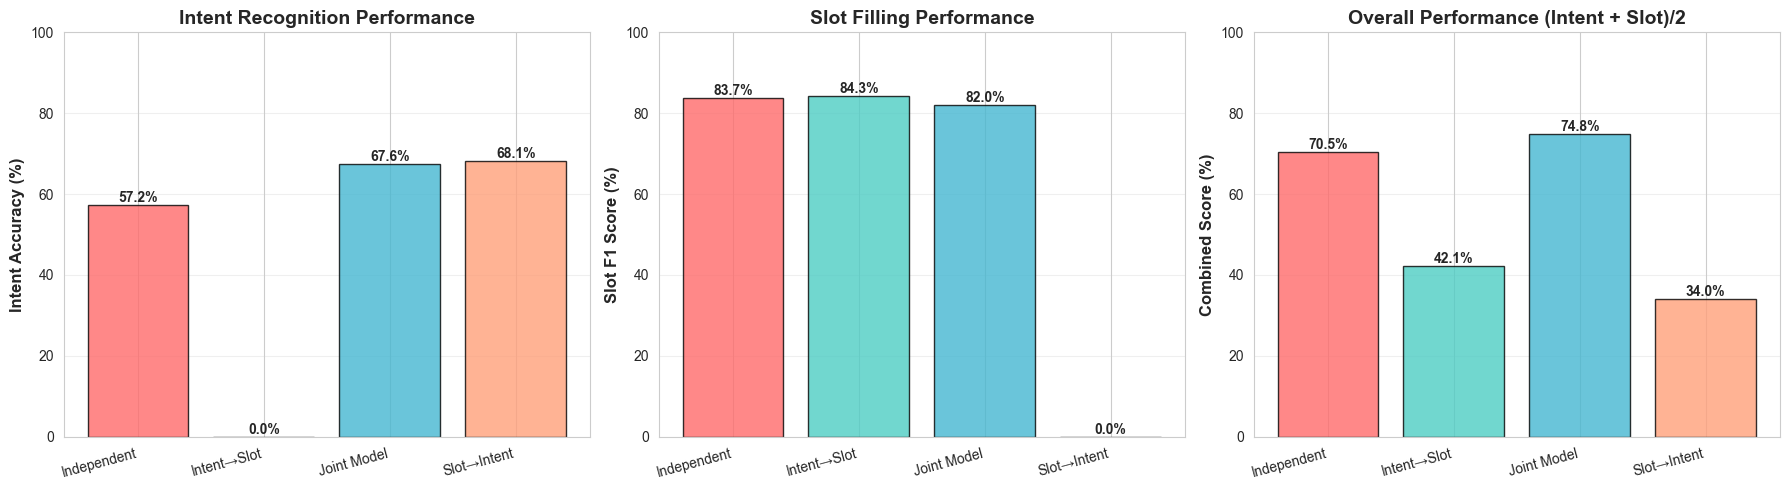

In [286]:
def plot_overall_metrics_comparison(metrics_df, save_path=None):
    """Create bar charts comparing all approaches across key metrics"""
    
    # Average metrics across all datasets and architectures
    avg_metrics = metrics_df.groupby('Approach')[['Intent_Acc', 'Slot_F1', 'Combined']].mean()
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Define colors for each approach
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
    
    # Plot 1: Intent Accuracy
    ax1 = axes[0]
    bars1 = ax1.bar(avg_metrics.index, avg_metrics['Intent_Acc'], color=colors, alpha=0.8, edgecolor='black')
    ax1.set_ylabel('Intent Accuracy (%)', fontweight='bold')
    ax1.set_title('Intent Recognition Performance', fontweight='bold', fontsize=14)
    ax1.set_ylim([0, 100])
    ax1.grid(axis='y', alpha=0.3)
    ax1.set_xticklabels(avg_metrics.index, rotation=15, ha='right')
    
    # Add value labels on bars
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    # Plot 2: Slot F1 Score
    ax2 = axes[1]
    bars2 = ax2.bar(avg_metrics.index, avg_metrics['Slot_F1'], color=colors, alpha=0.8, edgecolor='black')
    ax2.set_ylabel('Slot F1 Score (%)', fontweight='bold')
    ax2.set_title('Slot Filling Performance', fontweight='bold', fontsize=14)
    ax2.set_ylim([0, 100])
    ax2.grid(axis='y', alpha=0.3)
    ax2.set_xticklabels(avg_metrics.index, rotation=15, ha='right')
    
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    # Plot 3: Combined Score
    ax3 = axes[2]
    bars3 = ax3.bar(avg_metrics.index, avg_metrics['Combined'], color=colors, alpha=0.8, edgecolor='black')
    ax3.set_ylabel('Combined Score (%)', fontweight='bold')
    ax3.set_title('Overall Performance (Intent + Slot)/2', fontweight='bold', fontsize=14)
    ax3.set_ylim([0, 100])
    ax3.grid(axis='y', alpha=0.3)
    ax3.set_xticklabels(avg_metrics.index, rotation=15, ha='right')
    
    for bar in bars3:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved to: {save_path}")
    
    plt.show()
    
    return avg_metrics

# Create overall comparison
print("Overall Performance Comparison (Averaged across all configurations):\n")
avg_performance = plot_overall_metrics_comparison(metrics_table, 
                                                   save_path='Results/overall_comparison.png')

Dataset-Specific Performance Comparison:



Saved to: Results/dataset_comparison.png


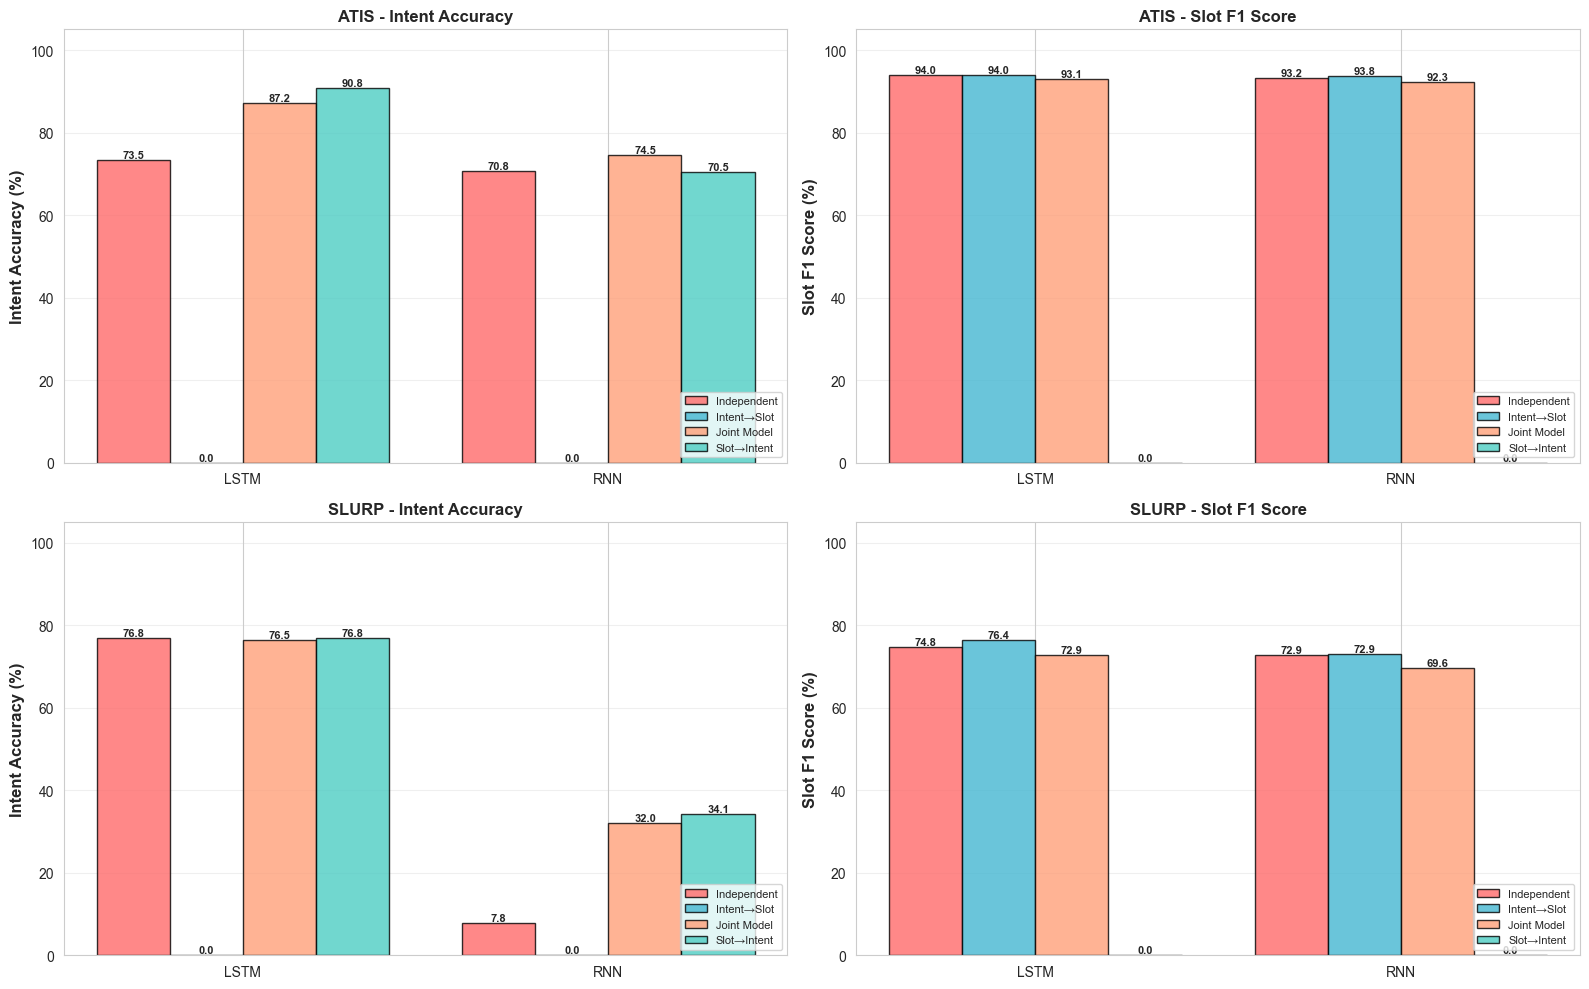

In [287]:
def plot_dataset_specific_comparison(metrics_df, save_path=None):
    """Compare approaches separately for each dataset"""
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    datasets = ['ATIS', 'SLURP']
    metrics = ['Intent_Acc', 'Slot_F1']
    metric_names = ['Intent Accuracy (%)', 'Slot F1 Score (%)']
    
    colors = {'Independent': '#FF6B6B', 'Slot→Intent': '#4ECDC4', 
              'Intent→Slot': '#45B7D1', 'Joint Model': '#FFA07A'}
    
    for i, dataset in enumerate(datasets):
        for j, (metric, metric_name) in enumerate(zip(metrics, metric_names)):
            ax = axes[i][j]
            
            # Filter data for this dataset
            dataset_data = metrics_df[metrics_df['Dataset'] == dataset]
            
            # Group by approach and architecture
            pivot = dataset_data.pivot_table(values=metric, 
                                            index='Architecture', 
                                            columns='Approach')
            
            # Create grouped bar chart
            x = np.arange(len(pivot.index))
            width = 0.2
            
            for idx, approach in enumerate(pivot.columns):
                offset = (idx - 1.5) * width
                bars = ax.bar(x + offset, pivot[approach], width, 
                            label=approach, color=colors[approach], 
                            alpha=0.8, edgecolor='black')
                
                # Add value labels
                for bar in bars:
                    height = bar.get_height()
                    if not np.isnan(height):
                        ax.text(bar.get_x() + bar.get_width()/2., height,
                               f'{height:.1f}', ha='center', va='bottom', 
                               fontsize=8, fontweight='bold')
            
            ax.set_ylabel(metric_name, fontweight='bold')
            ax.set_title(f'{dataset} - {metric_name.split("(")[0].strip()}', 
                        fontweight='bold', fontsize=12)
            ax.set_xticks(x)
            ax.set_xticklabels(pivot.index)
            ax.set_ylim([0, 105])
            ax.legend(loc='lower right', fontsize=8)
            ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved to: {save_path}")
    
    plt.show()

# Create dataset-specific comparison
print("Dataset-Specific Performance Comparison:\n")
plot_dataset_specific_comparison(metrics_table, 
                                 save_path='Results/dataset_comparison.png')

Learning Curves - ATIS with LSTM:

Saved to: Results/learning_curves_atis_lstm.png
Saved to: Results/learning_curves_atis_lstm.png


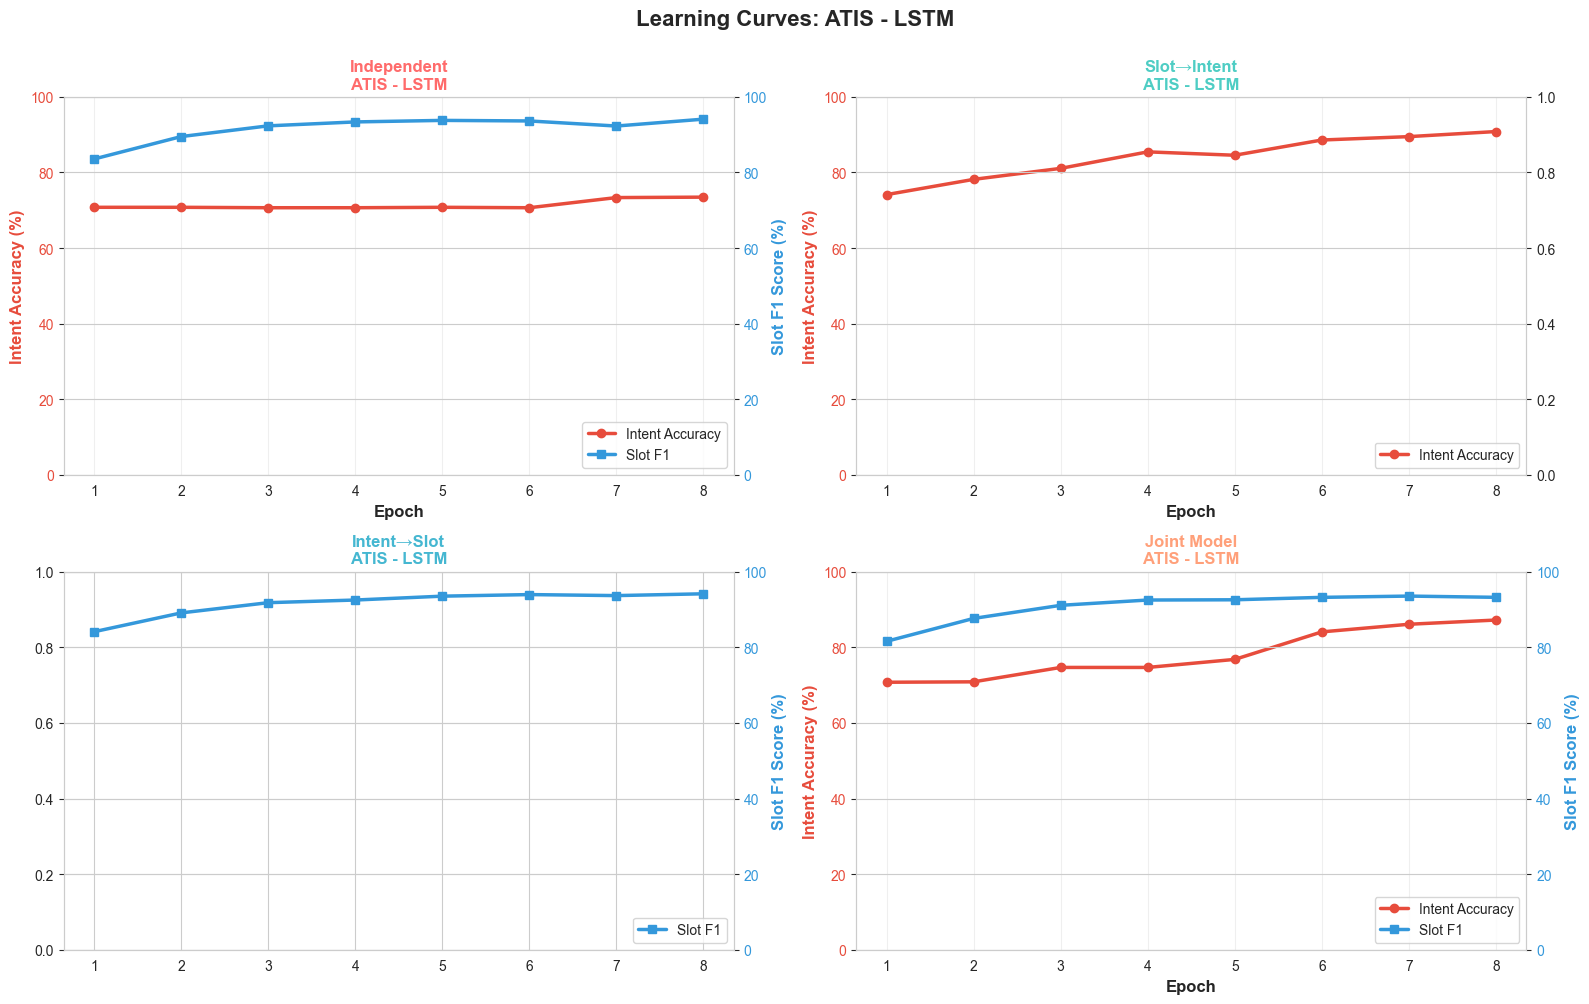

In [288]:
def load_epoch_data(results_dir, approach, dataset, architecture):
    """Load epoch-by-epoch training data for learning curves"""
    
    # Approach 1: Independent - has separate intent_results.csv and slot_results.csv
    if '1 Independent' in approach:
        intent_path = os.path.join(results_dir, approach, dataset, architecture, 'intent_results.csv')
        slot_path = os.path.join(results_dir, approach, dataset, architecture, 'slot_results.csv')
        
        if os.path.exists(intent_path) and os.path.exists(slot_path):
            intent_df = pd.read_csv(intent_path)
            slot_df = pd.read_csv(slot_path)
            
            if not intent_df.empty and not slot_df.empty and 'epoch' in intent_df.columns:
                # Merge intent and slot data on epoch
                merged_df = pd.merge(intent_df[['epoch', 'test_acc']], 
                                    slot_df[['epoch', 'test_F1']], 
                                    on='epoch', how='inner')
                merged_df.rename(columns={'test_acc': 'intent_test_accuracy', 
                                         'test_F1': 'slot_test_f1_micro'}, inplace=True)
                return merged_df
    
    # Approach 2: Slot→Intent - has intent_results.csv
    elif '2.Slot2Intent' in approach:
        intent_path = os.path.join(results_dir, approach, dataset, architecture, 'intent_results.csv')
        if os.path.exists(intent_path):
            df = pd.read_csv(intent_path)
            if not df.empty and 'epoch' in df.columns:
                df.rename(columns={'test_acc': 'intent_test_accuracy'}, inplace=True)
                return df
    
    # Approach 3: Intent→Slot - has slot_results.csv
    elif '3.Intent2Slot' in approach:
        slot_path = os.path.join(results_dir, approach, dataset, architecture, 'slot_results.csv')
        if os.path.exists(slot_path):
            df = pd.read_csv(slot_path)
            if not df.empty and 'epoch' in df.columns:
                df.rename(columns={'test_f1': 'slot_test_f1_micro'}, inplace=True)
                return df
    
    # Approach 4: Joint Model - has joint_results.csv
    elif '4.Joint Model' in approach:
        joint_path = os.path.join(results_dir, approach, dataset, architecture, 'joint_results.csv')
        if os.path.exists(joint_path):
            df = pd.read_csv(joint_path)
            if not df.empty and 'epoch' in df.columns:
                return df
    
    return None

def plot_learning_curves(results_dir='Results', dataset='atis', architecture='LSTM', save_path=None):
    """Plot training progression over epochs for all approaches"""
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Use actual directory names
    approaches = [
        '1 Independent Slot Filling and Intent Recognition',
        '2.Slot2Intent',
        '3.Intent2Slot',
        '4.Joint Model'
    ]
    # Display names for titles
    approach_names = ['Independent', 'Slot→Intent', 'Intent→Slot', 'Joint Model']
    colors = {'Independent': '#FF6B6B', 'Slot→Intent': '#4ECDC4', 
              'Intent→Slot': '#45B7D1', 'Joint Model': '#FFA07A'}
    
    for idx, (approach, name) in enumerate(zip(approaches, approach_names)):
        row, col = idx // 2, idx % 2
        ax = axes[row][col]
        
        # Load epoch data specifically for learning curves
        df = load_epoch_data(results_dir, approach, dataset, architecture)
        
        if df is not None and not df.empty:
            epochs = df['epoch'].values
            
            # Plot intent accuracy
            ax_intent = ax
            intent_cols = ['test_intent_acc', 'intent_test_accuracy', 'test_intent_accuracy', 'test_acc']
            intent_col = None
            for col in intent_cols:
                if col in df.columns:
                    intent_col = col
                    break
            
            if intent_col:
                ax_intent.plot(epochs, df[intent_col] * 100, 
                              label='Intent Accuracy', color='#E74C3C', 
                              linewidth=2.5, marker='o', markersize=6)
                ax_intent.set_xlabel('Epoch', fontweight='bold')
                ax_intent.set_ylabel('Intent Accuracy (%)', color='#E74C3C', fontweight='bold')
                ax_intent.tick_params(axis='y', labelcolor='#E74C3C')
                ax_intent.grid(True, alpha=0.3)
            
            # Plot slot F1 on secondary axis
            ax_slot = ax_intent.twinx()
            slot_cols = ['test_slot_f1', 'slot_test_f1_micro', 'slot_test_f1_macro', 'test_slot_f1_macro', 'test_f1', 'test_F1']
            slot_col = None
            for col in slot_cols:
                if col in df.columns:
                    slot_col = col
                    break
            
            if slot_col:
                ax_slot.plot(epochs, df[slot_col] * 100, 
                            label='Slot F1', color='#3498DB', 
                            linewidth=2.5, marker='s', markersize=6)
                ax_slot.set_ylabel('Slot F1 Score (%)', color='#3498DB', fontweight='bold')
                ax_slot.tick_params(axis='y', labelcolor='#3498DB')
            
            ax_intent.set_title(f'{name}\n{dataset.upper()} - {architecture}', 
                               fontweight='bold', fontsize=12,
                               color=colors[name])
            
            # Add legend
            lines1, labels1 = ax_intent.get_legend_handles_labels()
            lines2, labels2 = ax_slot.get_legend_handles_labels()
            if lines1 or lines2:
                ax_intent.legend(lines1 + lines2, labels1 + labels2, loc='lower right')
            
            # Set y-axis limits
            if intent_col:
                ax_intent.set_ylim([0, 100])
            if slot_col:
                ax_slot.set_ylim([0, 100])
        else:
            ax.text(0.5, 0.5, f'No data for {name}', 
                   ha='center', va='center', transform=ax.transAxes, fontsize=12)
            ax.set_title(f'{name} - No Data', fontweight='bold')
    
    plt.suptitle(f'Learning Curves: {dataset.upper()} - {architecture}', 
                 fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved to: {save_path}")
    
    plt.show()

# Plot learning curves for ATIS-LSTM
print("Learning Curves - ATIS with LSTM:\n")
plot_learning_curves(results_dir='Results', dataset='atis', architecture='LSTM',
                     save_path='Results/learning_curves_atis_lstm.png')

Learning Curves - SLURP with LSTM:

Saved to: Results/learning_curves_slurp_lstm.png
Saved to: Results/learning_curves_slurp_lstm.png


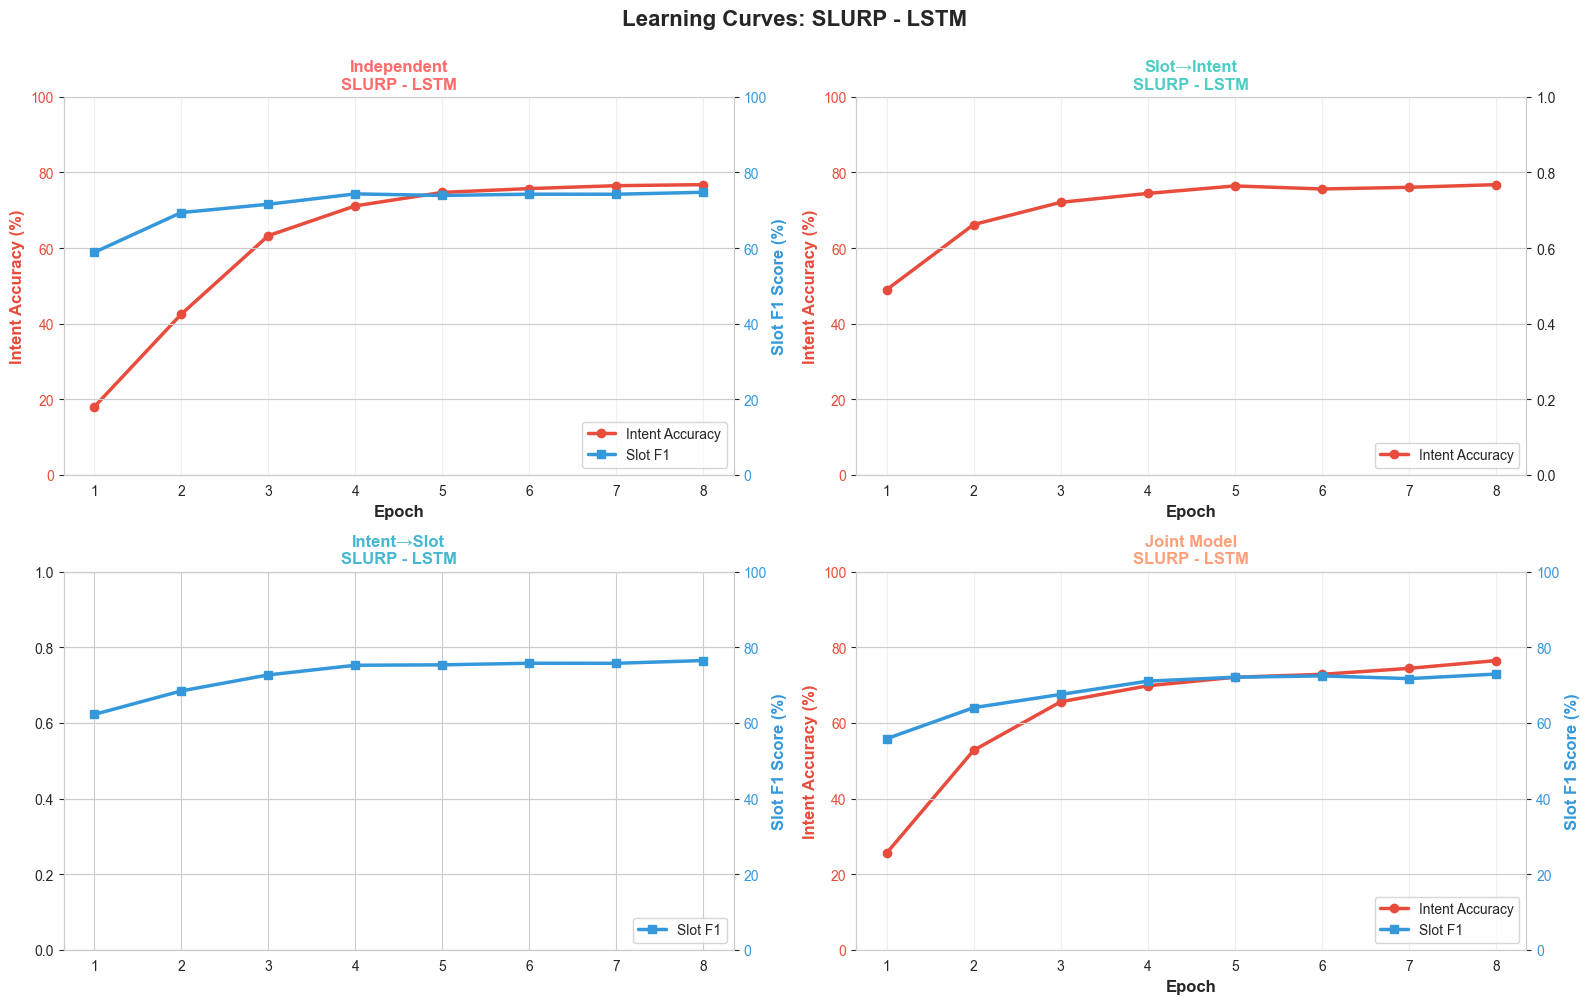

In [289]:
# Plot learning curves for SLURP-LSTM
print("Learning Curves - SLURP with LSTM:\n")
plot_learning_curves(results_dir='Results', dataset='slurp', architecture='LSTM',
                     save_path='Results/learning_curves_slurp_lstm.png')


Learning Curves - ATIS with RNN:

Saved to: Results/learning_curves_atis_rnn.png
Saved to: Results/learning_curves_atis_rnn.png


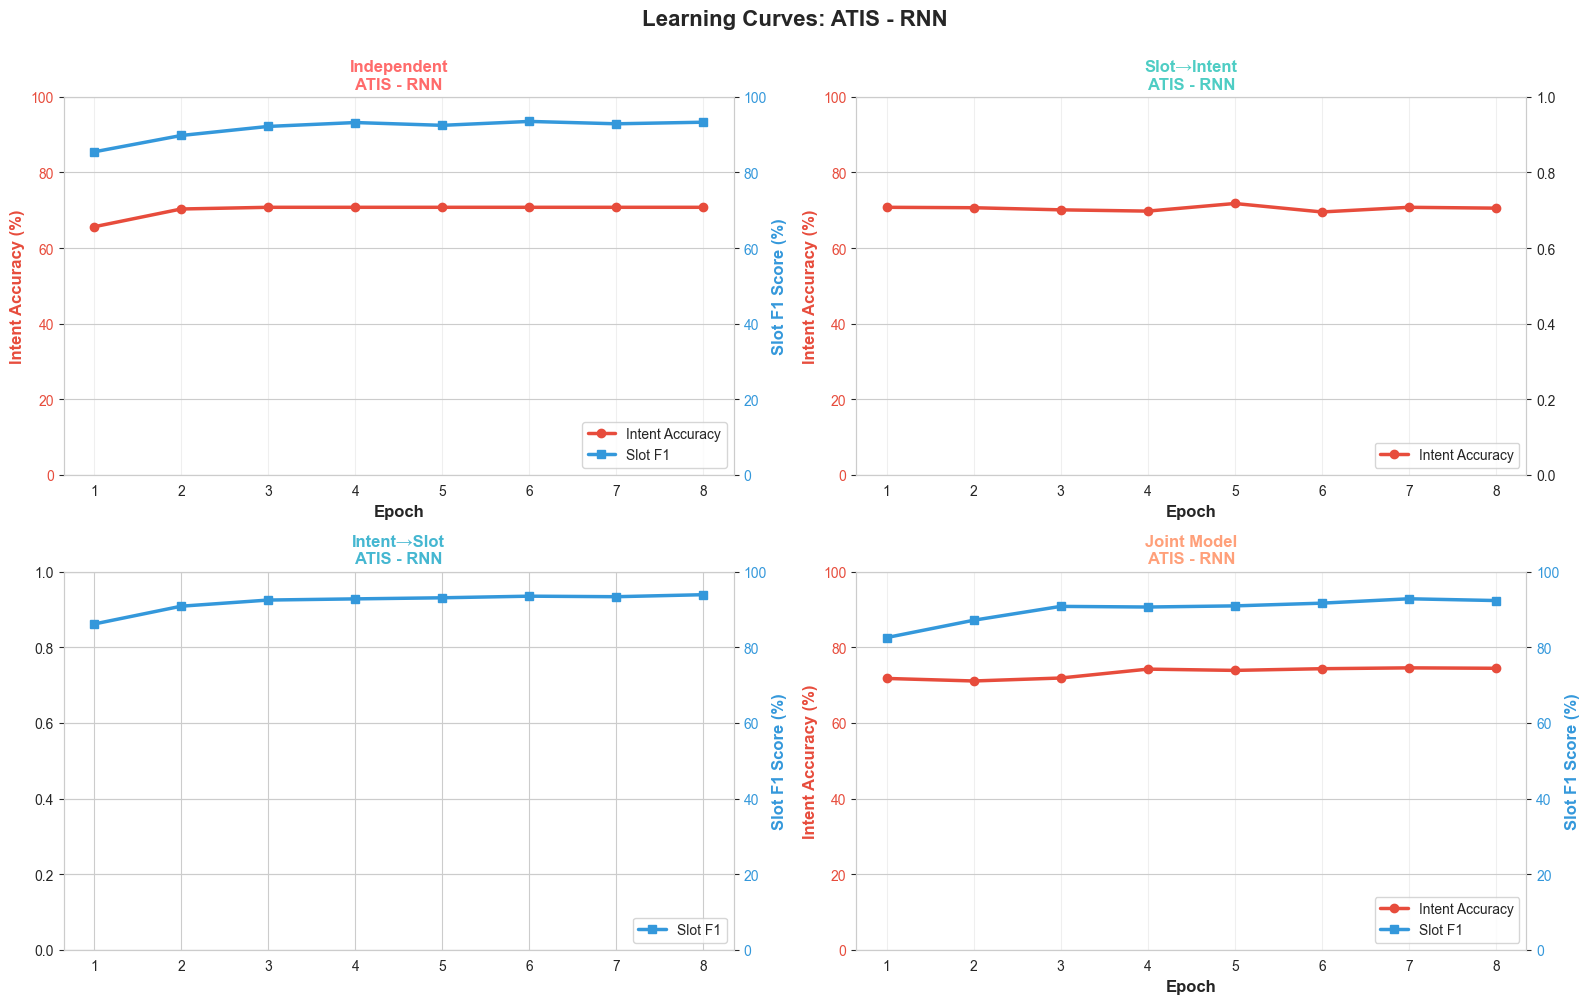



Learning Curves - SLURP with RNN:

Saved to: Results/learning_curves_slurp_rnn.png
Saved to: Results/learning_curves_slurp_rnn.png


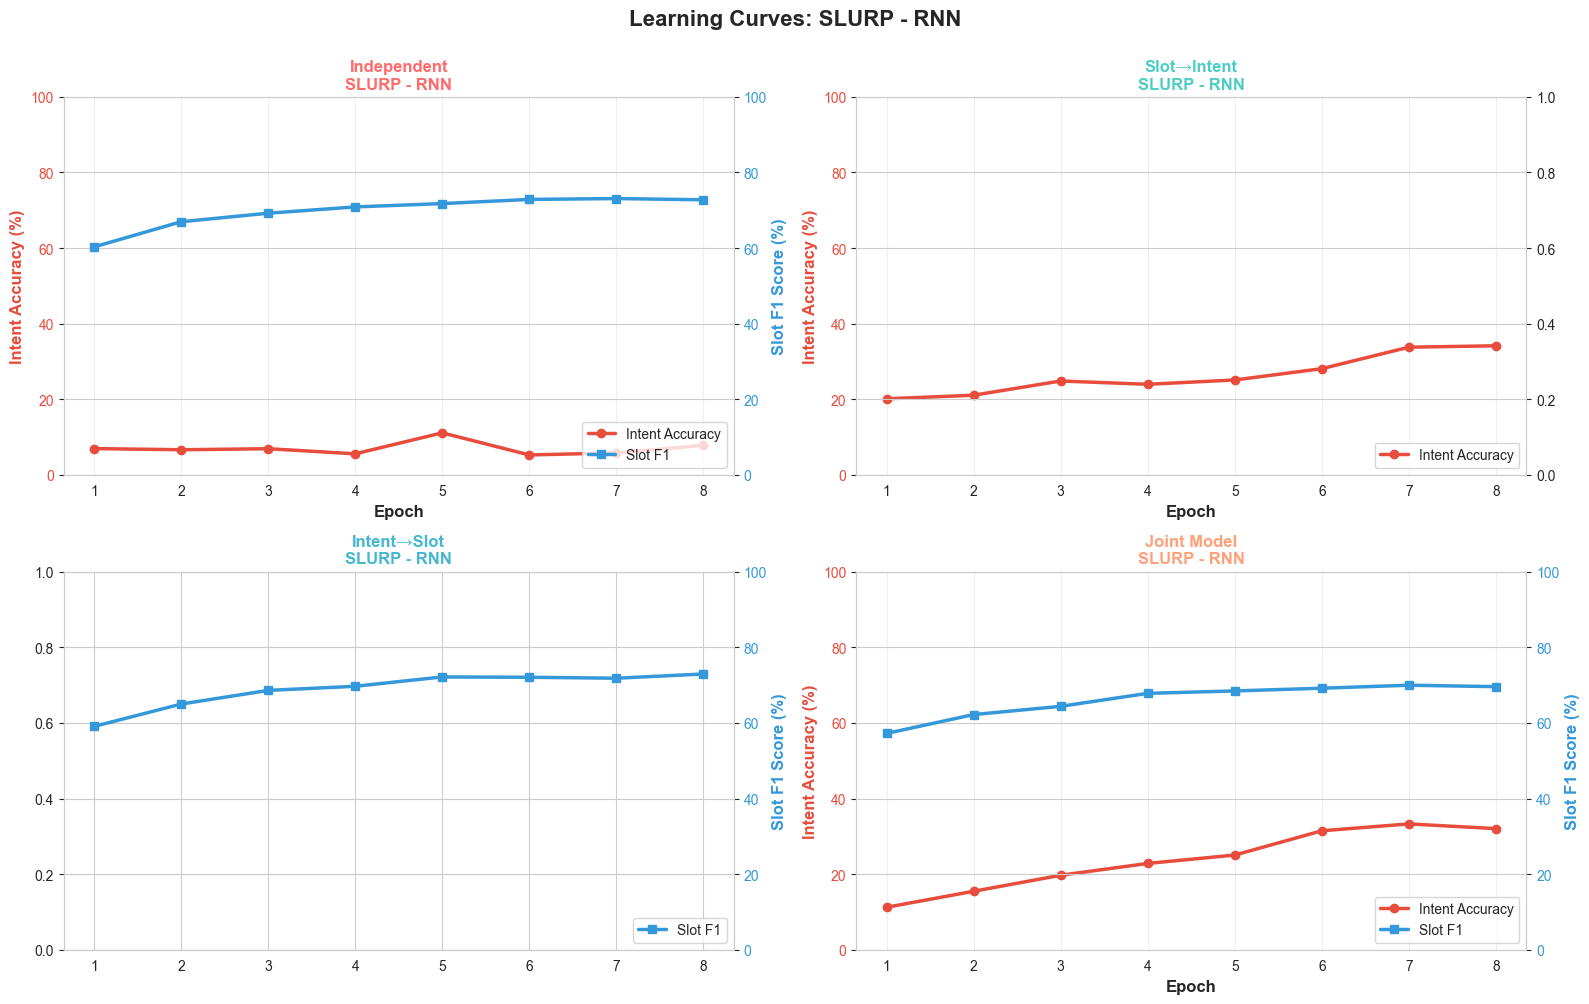

In [290]:
# Plot learning curves for RNN architecture
print("\nLearning Curves - ATIS with RNN:\n")
plot_learning_curves(results_dir='Results', dataset='atis', architecture='RNN',
                     save_path='Results/learning_curves_atis_rnn.png')

print("\n" + "="*80 + "\n")

print("Learning Curves - SLURP with RNN:\n")
plot_learning_curves(results_dir='Results', dataset='slurp', architecture='RNN',
                     save_path='Results/learning_curves_slurp_rnn.png')

In [291]:
# Calculate improvement over Independent baseline
def calculate_improvements(metrics_df):
    """Calculate % improvement over Independent baseline for each configuration"""
    
    improvement_rows = []
    
    # Get baseline (Independent) scores for each dataset-architecture combination
    baseline_df = metrics_df[metrics_df['Approach'] == 'Independent'].copy()
    
    # For each non-baseline approach
    for approach in ['Slot→Intent', 'Intent→Slot', 'Joint Model']:
        approach_data = metrics_df[metrics_df['Approach'] == approach]
        
        for _, row in approach_data.iterrows():
            # Find matching baseline
            baseline_row = baseline_df[
                (baseline_df['Dataset'] == row['Dataset']) & 
                (baseline_df['Architecture'] == row['Architecture'])
            ]
            
            if not baseline_row.empty:
                baseline = baseline_row.iloc[0]
                
                # Calculate improvements
                intent_improvement = ((row['Intent_Acc'] - baseline['Intent_Acc']) / baseline['Intent_Acc'] * 100)
                slot_improvement = ((row['Slot_F1'] - baseline['Slot_F1']) / baseline['Slot_F1'] * 100)
                combined_improvement = ((row['Combined'] - baseline['Combined']) / baseline['Combined'] * 100)
                
                improvement_rows.append({
                    'Approach': approach,
                    'Dataset': row['Dataset'],
                    'Architecture': row['Architecture'],
                    'Intent_Improvement': intent_improvement,
                    'Slot_Improvement': slot_improvement,
                    'Combined_Improvement': combined_improvement
                })
    
    return pd.DataFrame(improvement_rows)

# Calculate improvements
improvement_df = calculate_improvements(metrics_table)

print("Improvement over Independent Baseline:")
print(improvement_df.to_string(index=False))
print(f"\nCalculated improvements for {len(improvement_df)} configurations")

Improvement over Independent Baseline:
   Approach Dataset Architecture  Intent_Improvement  Slot_Improvement  Combined_Improvement
Slot→Intent    ATIS          RNN           -0.316456       -100.000000            -56.973976
Slot→Intent    ATIS         LSTM           23.628049       -100.000000            -45.763672
Slot→Intent   SLURP          RNN          337.500000       -100.000000            -57.693420
Slot→Intent   SLURP         LSTM            0.000000       -100.000000            -49.354844
Intent→Slot    ATIS          RNN         -100.000000          0.645161            -42.795922
Intent→Slot    ATIS         LSTM         -100.000000          0.000000            -43.870568
Intent→Slot   SLURP          RNN         -100.000000          0.063371             -9.612832
Intent→Slot   SLURP         LSTM         -100.000000          2.191358            -49.563614
Joint Model    ATIS          RNN            5.221519         -0.967742              1.703705
Joint Model    ATIS         LST

Improvement Heatmap (vs. Independent Baseline):

Saved to: Results/improvement_heatmap.png
Saved to: Results/improvement_heatmap.png


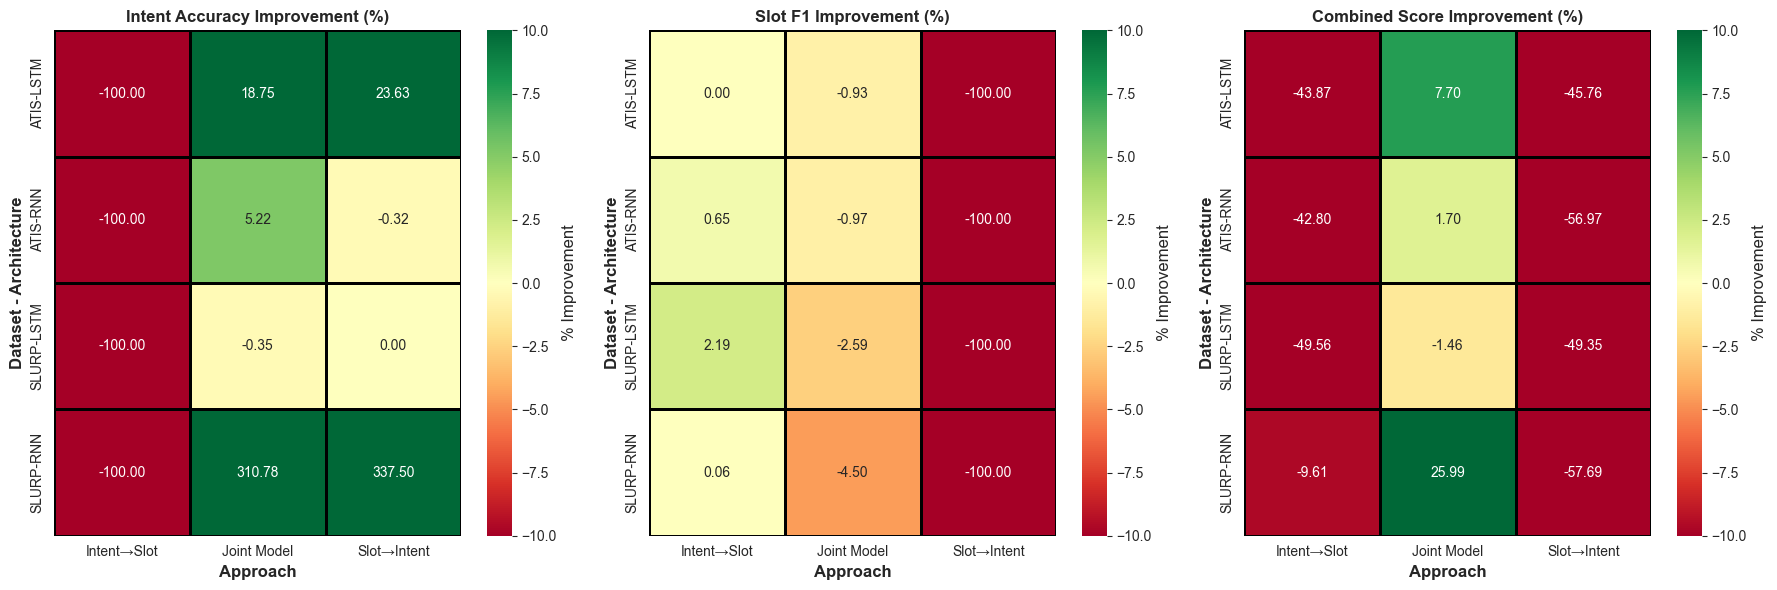

In [292]:
def plot_improvement_heatmap(improvement_df, save_path=None):
    """Create heatmap showing % improvement over baseline"""
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    metrics = ['Intent_Improvement', 'Slot_Improvement', 'Combined_Improvement']
    titles = ['Intent Accuracy Improvement (%)', 
              'Slot F1 Improvement (%)', 
              'Combined Score Improvement (%)']
    
    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        ax = axes[idx]
        
        # Create pivot table
        pivot = improvement_df.pivot_table(
            values=metric,
            index=['Dataset', 'Architecture'],
            columns='Approach'
        )
        
        # Create heatmap
        sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
                   ax=ax, cbar_kws={'label': '% Improvement'},
                   linewidths=1, linecolor='black', vmin=-10, vmax=10)
        
        ax.set_title(title, fontweight='bold', fontsize=12)
        ax.set_xlabel('Approach', fontweight='bold')
        ax.set_ylabel('Dataset - Architecture', fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved to: {save_path}")
    
    plt.show()

# Plot improvement heatmap
print("Improvement Heatmap (vs. Independent Baseline):\n")
plot_improvement_heatmap(improvement_df, save_path='Results/improvement_heatmap.png')

Radar Chart - ATIS with LSTM:

Saved to: Results/radar_chart_atis_lstm.png
Saved to: Results/radar_chart_atis_lstm.png


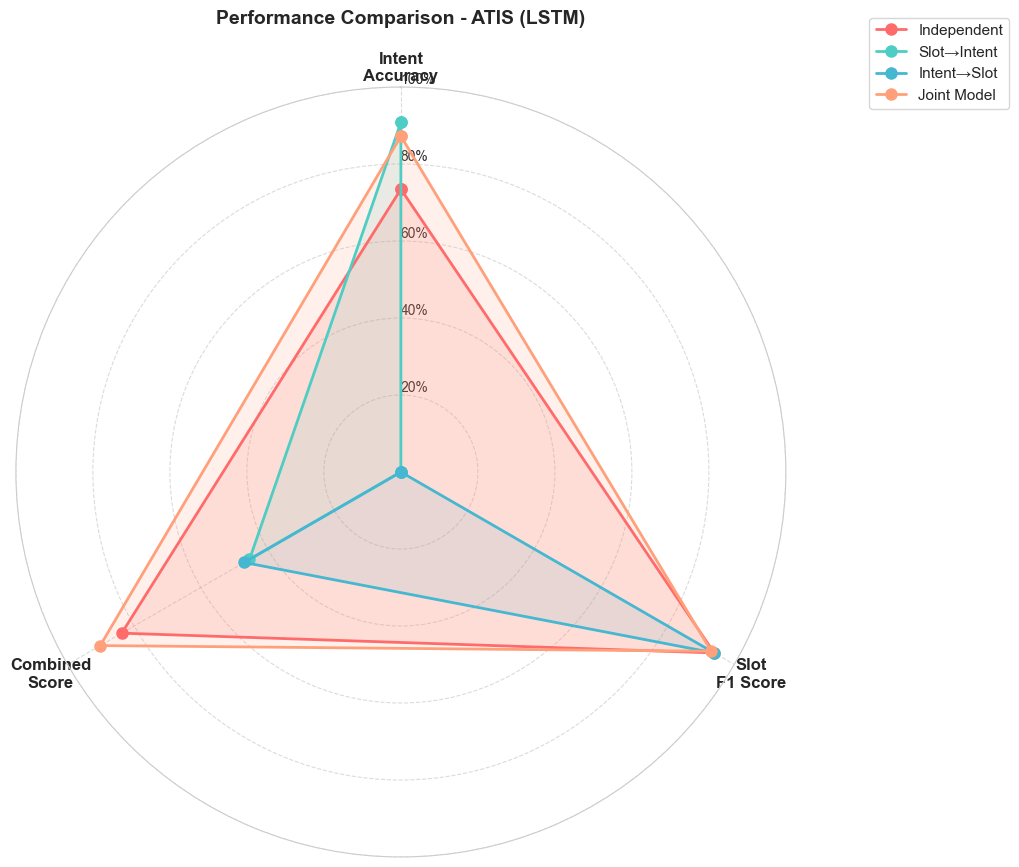

In [293]:
def plot_radar_chart(metrics_df, dataset='ATIS', architecture='LSTM', save_path=None):
    """Create radar chart comparing all approaches on multiple metrics"""
    
    # Filter data
    data = metrics_df[
        (metrics_df['Dataset'] == dataset) & 
        (metrics_df['Architecture'] == architecture)
    ]
    
    if data.empty:
        print(f"[WARNING] No data for {dataset} - {architecture}")
        return
    
    # Metrics to compare (normalized to 0-100 scale)
    categories = ['Intent\nAccuracy', 'Slot\nF1 Score', 'Combined\nScore']
    
    # Number of variables
    N = len(categories)
    
    # Compute angle for each axis
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    
    # Initialize plot
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
    
    # Colors for each approach
    colors = {'Independent': '#FF6B6B', 'Slot→Intent': '#4ECDC4', 
              'Intent→Slot': '#45B7D1', 'Joint Model': '#FFA07A'}
    
    # Plot data for each approach
    for approach in data['Approach'].unique():
        approach_data = data[data['Approach'] == approach]
        
        values = [
            approach_data['Intent_Acc'].values[0],
            approach_data['Slot_F1'].values[0],
            approach_data['Combined'].values[0]
        ]
        values += values[:1]
        
        ax.plot(angles, values, 'o-', linewidth=2, label=approach, 
               color=colors[approach], markersize=8)
        ax.fill(angles, values, alpha=0.15, color=colors[approach])
    
    # Fix axis to go in the right order and start at 12 o'clock
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    
    # Draw axis lines for each angle and label
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
    
    # Set y-axis limits and labels
    ax.set_ylim(0, 100)
    ax.set_yticks([20, 40, 60, 80, 100])
    ax.set_yticklabels(['20%', '40%', '60%', '80%', '100%'], fontsize=10)
    ax.set_rlabel_position(0)
    
    # Add grid
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Add legend
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
    
    # Add title
    plt.title(f'Performance Comparison - {dataset} ({architecture})', 
             fontsize=14, fontweight='bold', pad=20)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved to: {save_path}")
    
    plt.show()

# Plot radar charts for ATIS-LSTM
print("Radar Chart - ATIS with LSTM:\n")
plot_radar_chart(metrics_table, dataset='ATIS', architecture='LSTM',
                save_path='Results/radar_chart_atis_lstm.png')

Radar Chart - SLURP with LSTM:

Saved to: Results/radar_chart_slurp_lstm.png
Saved to: Results/radar_chart_slurp_lstm.png


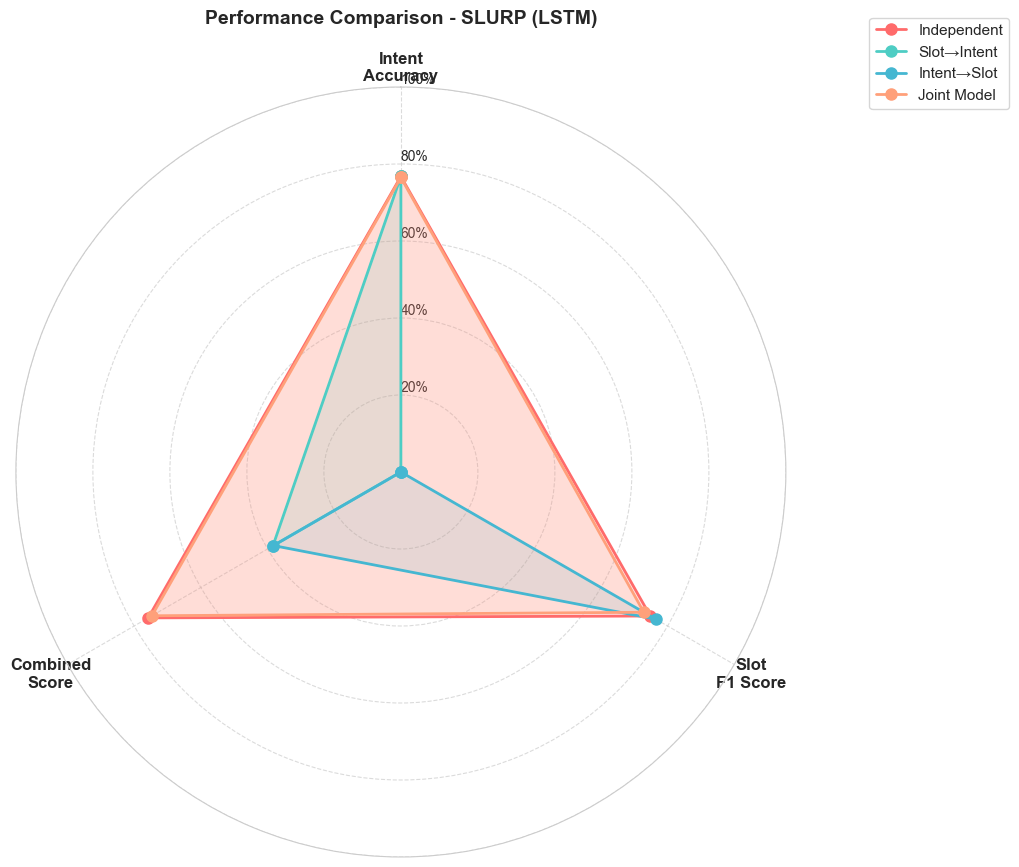

In [294]:
# Plot radar chart for SLURP-LSTM
print("Radar Chart - SLURP with LSTM:\n")
plot_radar_chart(metrics_table, dataset='SLURP', architecture='LSTM',
                save_path='Results/radar_chart_slurp_lstm.png')

Architecture Comparison (RNN vs LSTM):

Saved to: Results/architecture_comparison.png
Saved to: Results/architecture_comparison.png


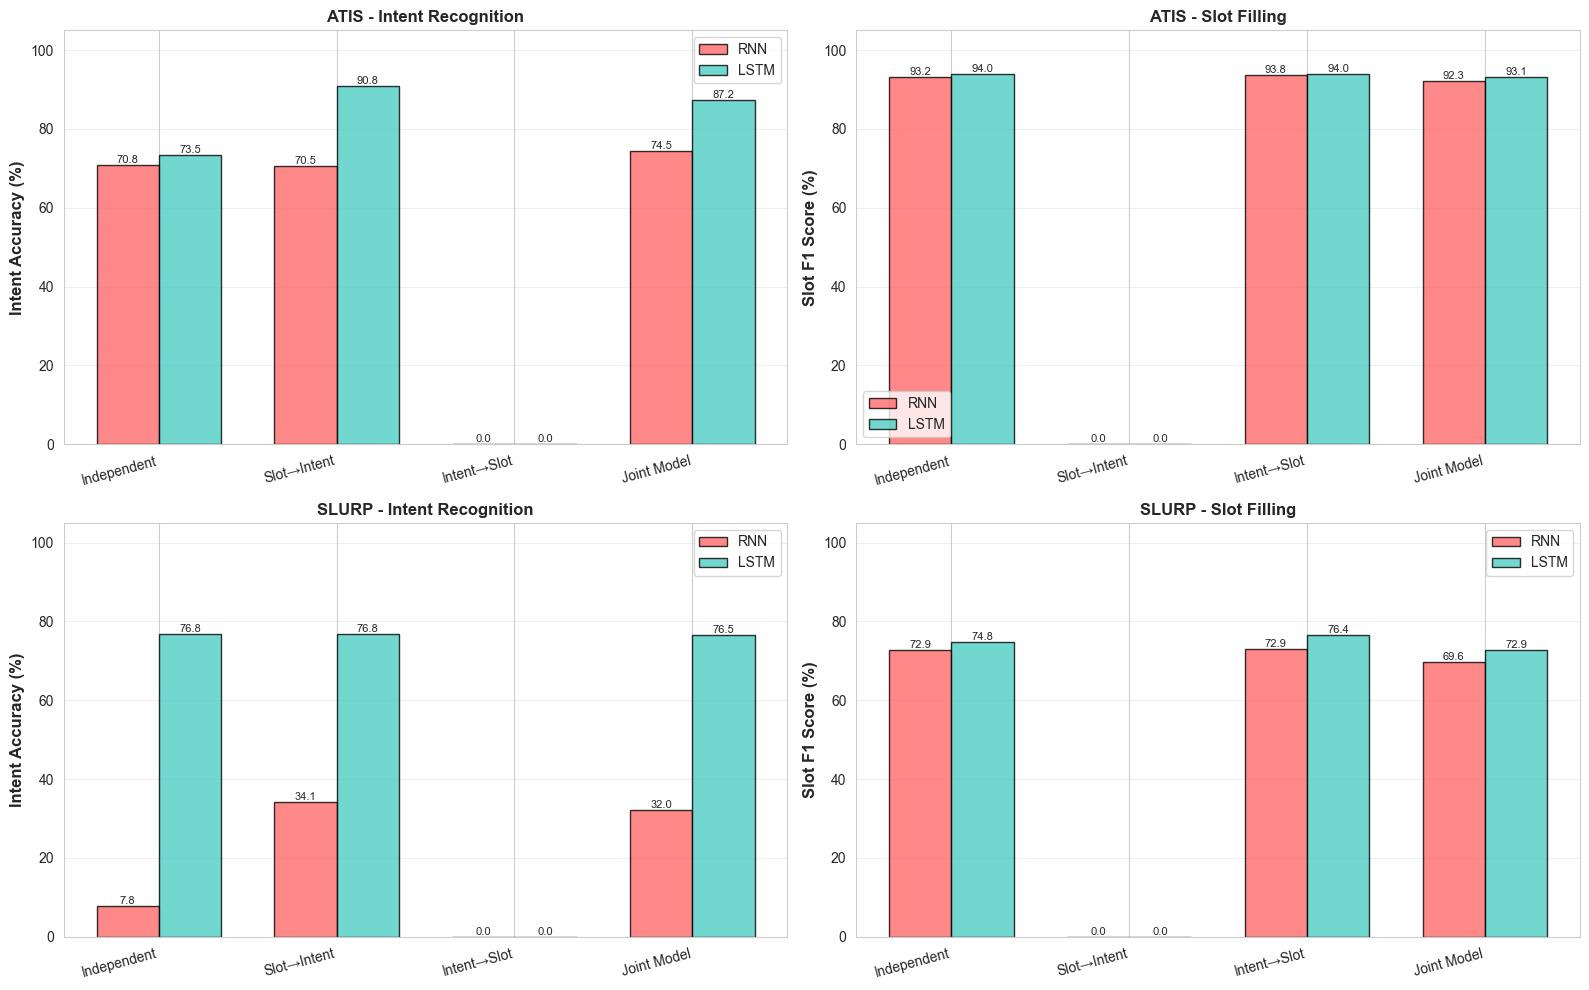

In [295]:
def plot_architecture_comparison(metrics_df, save_path=None):
    """Compare RNN vs LSTM across all approaches and datasets"""
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    approaches = ['Independent', 'Slot→Intent', 'Intent→Slot', 'Joint Model']
    datasets = ['ATIS', 'SLURP']
    
    for i, dataset in enumerate(datasets):
        # Intent Accuracy
        ax1 = axes[i][0]
        data_intent = []
        labels = []
        
        for approach in approaches:
            approach_data = metrics_df[
                (metrics_df['Dataset'] == dataset) & 
                (metrics_df['Approach'] == approach)
            ]
            
            if not approach_data.empty:
                rnn_val = approach_data[approach_data['Architecture'] == 'RNN']['Intent_Acc'].values
                lstm_val = approach_data[approach_data['Architecture'] == 'LSTM']['Intent_Acc'].values
                
                if len(rnn_val) > 0 and len(lstm_val) > 0:
                    data_intent.append([rnn_val[0], lstm_val[0]])
                    labels.append(approach)
        
        x = np.arange(len(labels))
        width = 0.35
        
        if data_intent:
            data_intent = np.array(data_intent)
            bars1 = ax1.bar(x - width/2, data_intent[:, 0], width, 
                          label='RNN', color='#FF6B6B', alpha=0.8, edgecolor='black')
            bars2 = ax1.bar(x + width/2, data_intent[:, 1], width, 
                          label='LSTM', color='#4ECDC4', alpha=0.8, edgecolor='black')
            
            # Add value labels
            for bars in [bars1, bars2]:
                for bar in bars:
                    height = bar.get_height()
                    ax1.text(bar.get_x() + bar.get_width()/2., height,
                           f'{height:.1f}', ha='center', va='bottom', fontsize=8)
        
        ax1.set_ylabel('Intent Accuracy (%)', fontweight='bold')
        ax1.set_title(f'{dataset} - Intent Recognition', fontweight='bold', fontsize=12)
        ax1.set_xticks(x)
        ax1.set_xticklabels(labels, rotation=15, ha='right')
        ax1.set_ylim([0, 105])
        ax1.legend()
        ax1.grid(axis='y', alpha=0.3)
        
        # Slot F1 Score
        ax2 = axes[i][1]
        data_slot = []
        
        for approach in approaches:
            approach_data = metrics_df[
                (metrics_df['Dataset'] == dataset) & 
                (metrics_df['Approach'] == approach)
            ]
            
            if not approach_data.empty:
                rnn_val = approach_data[approach_data['Architecture'] == 'RNN']['Slot_F1'].values
                lstm_val = approach_data[approach_data['Architecture'] == 'LSTM']['Slot_F1'].values
                
                if len(rnn_val) > 0 and len(lstm_val) > 0:
                    data_slot.append([rnn_val[0], lstm_val[0]])
        
        if data_slot:
            data_slot = np.array(data_slot)
            bars1 = ax2.bar(x - width/2, data_slot[:, 0], width, 
                          label='RNN', color='#FF6B6B', alpha=0.8, edgecolor='black')
            bars2 = ax2.bar(x + width/2, data_slot[:, 1], width, 
                          label='LSTM', color='#4ECDC4', alpha=0.8, edgecolor='black')
            
            for bars in [bars1, bars2]:
                for bar in bars:
                    height = bar.get_height()
                    ax2.text(bar.get_x() + bar.get_width()/2., height,
                           f'{height:.1f}', ha='center', va='bottom', fontsize=8)
        
        ax2.set_ylabel('Slot F1 Score (%)', fontweight='bold')
        ax2.set_title(f'{dataset} - Slot Filling', fontweight='bold', fontsize=12)
        ax2.set_xticks(x)
        ax2.set_xticklabels(labels, rotation=15, ha='right')
        ax2.set_ylim([0, 105])
        ax2.legend()
        ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved to: {save_path}")
    
    plt.show()

# Plot architecture comparison
print("Architecture Comparison (RNN vs LSTM):\n")
plot_architecture_comparison(metrics_table, 
                            save_path='Results/architecture_comparison.png')

Training & Testing Time Analysis:

Saved to: Results/time_analysis.png
Saved to: Results/time_analysis.png


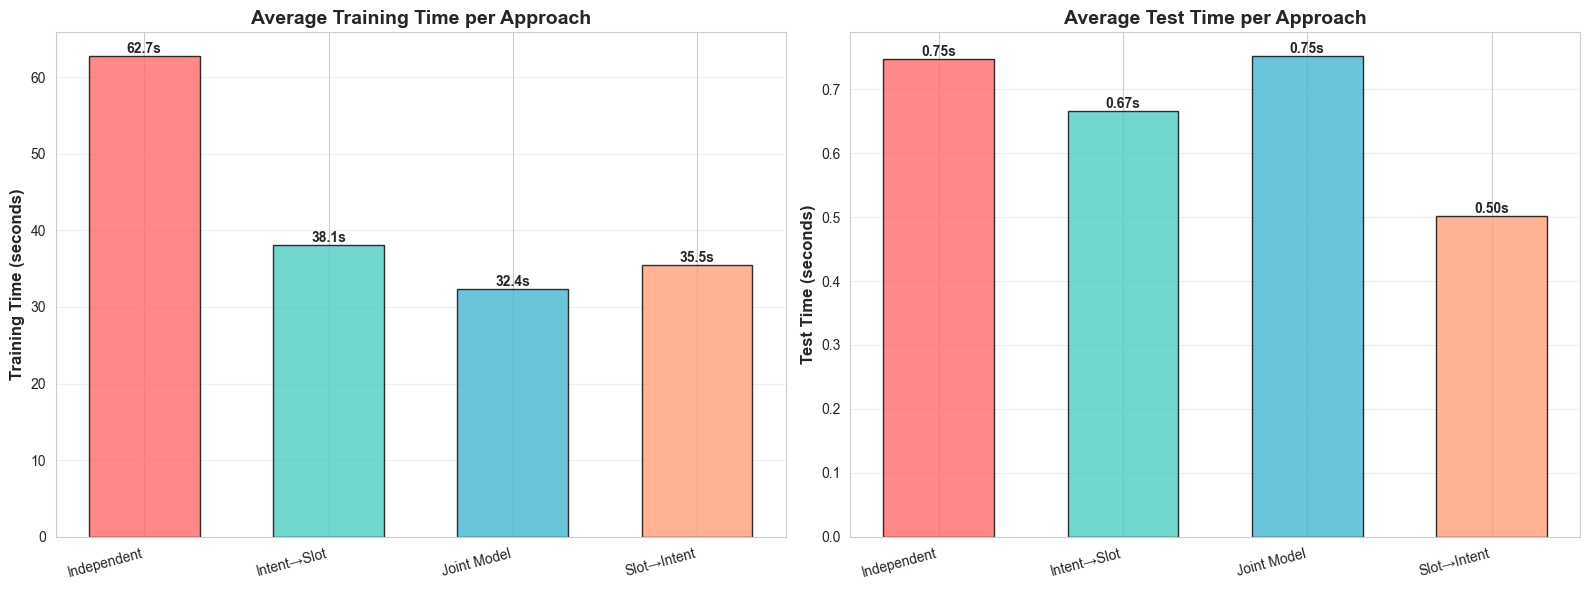


Average Times:
             Train_Time  Test_Time
Approach                          
Independent   62.700718   0.747743
Intent→Slot   38.059293   0.665929
Joint Model   32.385080   0.751509
Slot→Intent   35.483711   0.501898


In [296]:
def plot_training_time_analysis(metrics_df, save_path=None):
    """Analyze training and testing times across approaches"""
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Group by approach and calculate average times
    time_data = metrics_df.groupby('Approach')[['Train_Time', 'Test_Time']].mean()
    
    approaches = time_data.index
    x = np.arange(len(approaches))
    width = 0.35
    
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
    
    # Plot 1: Training Time
    ax1 = axes[0]
    bars1 = ax1.bar(x, time_data['Train_Time'], width=0.6, 
                    color=colors, alpha=0.8, edgecolor='black')
    
    ax1.set_ylabel('Training Time (seconds)', fontweight='bold')
    ax1.set_title('Average Training Time per Approach', fontweight='bold', fontsize=14)
    ax1.set_xticks(x)
    ax1.set_xticklabels(approaches, rotation=15, ha='right')
    ax1.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}s', ha='center', va='bottom', fontweight='bold')
    
    # Plot 2: Test Time
    ax2 = axes[1]
    bars2 = ax2.bar(x, time_data['Test_Time'], width=0.6, 
                    color=colors, alpha=0.8, edgecolor='black')
    
    ax2.set_ylabel('Test Time (seconds)', fontweight='bold')
    ax2.set_title('Average Test Time per Approach', fontweight='bold', fontsize=14)
    ax2.set_xticks(x)
    ax2.set_xticklabels(approaches, rotation=15, ha='right')
    ax2.grid(axis='y', alpha=0.3)
    
    for bar in bars2:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}s', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved to: {save_path}")
    
    plt.show()
    
    return time_data

# Plot training time analysis
print("Training & Testing Time Analysis:\n")
time_stats = plot_training_time_analysis(metrics_table, 
                                        save_path='Results/time_analysis.png')
print("\nAverage Times:")
print(time_stats)

In [ ]:
def create_summary_statistics_table(metrics_df):
    """Create comprehensive summary statistics table"""
    
    print("=" * 100)
    print("COMPREHENSIVE SUMMARY STATISTICS")
    print("=" * 100)
    
    # Overall best performers
    print("\nBEST PERFORMERS (Averaged across all configurations):\n")
    
    overall_avg = metrics_df.groupby('Approach')[['Intent_Acc', 'Slot_F1', 'Combined']].mean()
    overall_avg = overall_avg.round(2)
    
    best_intent = overall_avg['Intent_Acc'].idxmax()
    best_slot = overall_avg['Slot_F1'].idxmax()
    best_combined = overall_avg['Combined'].idxmax()
    
    print(f"  Best Intent Recognition:  {best_intent:20s} ({overall_avg.loc[best_intent, 'Intent_Acc']:.2f}%)")
    print(f"  Best Slot Filling:        {best_slot:20s} ({overall_avg.loc[best_slot, 'Slot_F1']:.2f}%)")
    print(f"  Best Combined Score:      {best_combined:20s} ({overall_avg.loc[best_combined, 'Combined']:.2f}%)")
    
    # Dataset-specific best performers
    print("\n\nDATASET-SPECIFIC BEST PERFORMERS:\n")
    
    for dataset in ['ATIS', 'SLURP']:
        print(f"  {dataset}:")
        dataset_data = metrics_df[metrics_df['Dataset'] == dataset]
        
        for metric, name in [('Intent_Acc', 'Intent'), ('Slot_F1', 'Slot'), ('Combined', 'Combined')]:
            best_idx = dataset_data[metric].idxmax()
            best_row = dataset_data.loc[best_idx]
            print(f"    {name:12s}: {best_row['Approach']:20s} "
                  f"({best_row['Architecture']:4s}) - {best_row[metric]:.2f}%")
        print()
    
    # Architecture comparison
    print("\nARCHITECTURE COMPARISON (RNN vs LSTM):\n")
    
    arch_comparison = metrics_df.groupby('Architecture')[['Intent_Acc', 'Slot_F1', 'Combined']].mean()
    arch_comparison = arch_comparison.round(2)
    
    print(arch_comparison)
    
    lstm_improvement = ((arch_comparison.loc['LSTM'] - arch_comparison.loc['RNN']) / 
                       arch_comparison.loc['RNN'] * 100)
    
    print(f"\n  LSTM Improvement over RNN:")
    print(f"    Intent Accuracy:  {lstm_improvement['Intent_Acc']:+.2f}%")
    print(f"    Slot F1 Score:    {lstm_improvement['Slot_F1']:+.2f}%")
    print(f"    Combined Score:   {lstm_improvement['Combined']:+.2f}%")
    
    # Full comparison table
    print("\n\nFULL COMPARISON TABLE:\n")
    
    summary = metrics_df.pivot_table(
        values=['Intent_Acc', 'Slot_F1', 'Combined'],
        index=['Dataset', 'Architecture'],
        columns='Approach',
        aggfunc='mean'
    ).round(2)
    
    print(summary)
    
    # Save to CSV
    summary.to_csv('Results/summary_statistics.csv')
    metrics_df.to_csv('Results/full_metrics_table.csv', index=False)
    
    print("\n\nTables saved to:")
    print("   - Results/summary_statistics.csv")
    print("   - Results/full_metrics_table.csv")
    
    print("\n" + "=" * 100)
    
    return summary
    
# Create summary statistics
summary_stats = create_summary_statistics_table(metrics_table)

COMPREHENSIVE SUMMARY STATISTICS

BEST PERFORMERS (Averaged across all configurations):

  Best Intent Recognition:  Slot→Intent          (68.07%)
  Best Slot Filling:        Intent→Slot          (84.29%)
  Best Combined Score:      Joint Model          (74.76%)


DATASET-SPECIFIC BEST PERFORMERS:

  ATIS:
    Intent      : Slot→Intent          (LSTM) - 90.82%
    Slot        : Independent          (LSTM) - 93.99%
    Combined    : Joint Model          (LSTM) - 90.17%

  SLURP:
    Intent      : Independent          (LSTM) - 76.77%
    Slot        : Intent→Slot          (LSTM) - 76.45%
    Combined    : Independent          (LSTM) - 75.79%


ARCHITECTURE COMPARISON (RNN vs LSTM):

              Intent_Acc  Slot_F1  Combined
Architecture                               
LSTM               60.19    63.15     61.67
RNN                36.22    61.83     49.03

  LSTM Improvement over RNN:
    Intent Accuracy:  +66.18%
    Slot F1 Score:    +2.13%
    Combined Score:   +25.78%


FULL COMPARIS

In [298]:
def generate_key_insights(metrics_df, improvement_df):
    """Generate automated insights from the results"""
    
    print("=" * 100)
    print("KEY FINDINGS & INSIGHTS")
    print("=" * 100)
    
    # Finding 1: Best overall approach
    overall_avg = metrics_df.groupby('Approach')['Combined'].mean()
    best_approach = overall_avg.idxmax()
    best_score = overall_avg.max()
    baseline_score = overall_avg['Independent']
    improvement = ((best_score - baseline_score) / baseline_score * 100)
    
    print(f"\n1. BEST OVERALL APPROACH:")
    print(f"   {best_approach} achieved the highest combined score ({best_score:.2f}%),")
    print(f"   representing a {improvement:+.2f}% improvement over the Independent baseline.")
    
    # Finding 2: Task-specific performance
    intent_best = metrics_df.groupby('Approach')['Intent_Acc'].mean().idxmax()
    slot_best = metrics_df.groupby('Approach')['Slot_F1'].mean().idxmax()
    
    print(f"\n2. TASK-SPECIFIC PERFORMANCE:")
    print(f"   - Intent Recognition: {intent_best} performed best")
    print(f"   - Slot Filling: {slot_best} performed best")
    
    if intent_best != slot_best:
        print(f"   -> Different approaches excel at different tasks!")
    else:
        print(f"   -> {intent_best} dominates both tasks!")
    
    # Finding 3: Architecture impact
    arch_diff = metrics_df.groupby('Architecture')['Combined'].mean()
    lstm_better = arch_diff['LSTM'] > arch_diff['RNN']
    arch_improvement = ((arch_diff['LSTM'] - arch_diff['RNN']) / arch_diff['RNN'] * 100)
    
    print(f"\n3. ARCHITECTURE IMPACT:")
    if lstm_better:
        print(f"   LSTM outperforms RNN by {arch_improvement:+.2f}% on average")
        print(f"   -> LSTM's gating mechanisms help capture long-range dependencies!")
    else:
        print(f"   RNN outperforms LSTM by {-arch_improvement:+.2f}% on average")
        print(f"   -> Simpler RNN architecture may be sufficient for these tasks!")
    
    # Finding 4: Dataset difficulty
    dataset_scores = metrics_df.groupby('Dataset')['Combined'].mean()
    harder_dataset = dataset_scores.idxmin()
    easier_dataset = dataset_scores.idxmax()
    difficulty_gap = dataset_scores.max() - dataset_scores.min()
    
    print(f"\n4. DATASET DIFFICULTY:")
    print(f"   - {easier_dataset}: Average score = {dataset_scores.max():.2f}% (easier)")
    print(f"   - {harder_dataset}: Average score = {dataset_scores.min():.2f}% (harder)")
    print(f"   -> Difficulty gap: {difficulty_gap:.2f} percentage points")
    
    # Finding 5: Improvement consistency
    if not improvement_df.empty:
        avg_improvements = improvement_df.groupby('Approach')['Combined_Improvement'].mean()
        most_consistent = avg_improvements.idxmax()
        
        print(f"\n5. IMPROVEMENT CONSISTENCY:")
        print(f"   {most_consistent} shows the most consistent improvements")
        print(f"   across different configurations (+{avg_improvements.max():.2f}% avg)")
        
        # Check if any approach shows negative improvement
        negative_improvements = improvement_df[improvement_df['Combined_Improvement'] < 0]
        if not negative_improvements.empty:
            print(f"\n   [WARNING] Some configurations showed degradation:")
            for _, row in negative_improvements.iterrows():
                print(f"      {row['Approach']} on {row['Dataset']}-{row['Architecture']}: "
                      f"{row['Combined_Improvement']:.2f}%")
    
    # Finding 6: Training efficiency
    time_per_score = metrics_df.groupby('Approach').apply(
        lambda x: x['Train_Time'].mean() / x['Combined'].mean()
    )
    most_efficient = time_per_score.idxmin()
    
    print(f"\n6. TRAINING EFFICIENCY:")
    print(f"   {most_efficient} is the most efficient approach")
    print(f"   (lowest training time per performance point)")
    
    efficiency_table = pd.DataFrame({
        'Approach': time_per_score.index,
        'Seconds per % Score': time_per_score.values
    }).round(2)
    print(f"\n{efficiency_table.to_string(index=False)}")
    
    print("\n" + "=" * 100)
    
    # Save insights to file
    with open('Results/key_insights.txt', 'w', encoding='utf-8') as f:
        f.write("KEY FINDINGS & INSIGHTS\n")
        f.write("=" * 100 + "\n\n")
        f.write(f"Best Approach: {best_approach} ({best_score:.2f}%)\n")
        f.write(f"Intent Best: {intent_best}\n")
        f.write(f"Slot Best: {slot_best}\n")
        f.write(f"Architecture Winner: {'LSTM' if lstm_better else 'RNN'}\n")
        f.write(f"Harder Dataset: {harder_dataset}\n")
        f.write(f"Most Efficient: {most_efficient}\n")
    
    print("\nInsights saved to: Results/key_insights.txt")

# Generate insights
generate_key_insights(metrics_table, improvement_df)

KEY FINDINGS & INSIGHTS

1. BEST OVERALL APPROACH:
   Joint Model achieved the highest combined score (74.76%),
   representing a +6.11% improvement over the Independent baseline.

2. TASK-SPECIFIC PERFORMANCE:
   - Intent Recognition: Slot→Intent performed best
   - Slot Filling: Intent→Slot performed best
   -> Different approaches excel at different tasks!

3. ARCHITECTURE IMPACT:
   LSTM outperforms RNN by +25.79% on average
   -> LSTM's gating mechanisms help capture long-range dependencies!

4. DATASET DIFFICULTY:
   - ATIS: Average score = 64.23% (easier)
   - SLURP: Average score = 46.47% (harder)
   -> Difficulty gap: 17.76 percentage points

5. IMPROVEMENT CONSISTENCY:
   Joint Model shows the most consistent improvements
   across different configurations (+8.48% avg)

   [WARNING] Some configurations showed degradation:
      Slot→Intent on ATIS-RNN: -56.97%
      Slot→Intent on ATIS-LSTM: -45.76%
      Slot→Intent on SLURP-RNN: -57.69%
      Slot→Intent on SLURP-LSTM: -49.